In [36]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [37]:
DATA_DIR = Path(".")

FILES = {
    "faostat": "FAOSTAT_data_en_4-13-2026.csv",
    "gpr": "Геополитический индекс.xlsx",
    "key_rate": "Ключевая ставка ЦБ на конец месяца.xlsx",
    "usd": "Курсы доллара помесячно.xlsx",
    "inflation": "Таблица инфляции по месяцам.xlsx",
}

for name, file in FILES.items():
    path = DATA_DIR / file
    print(name, "->", path, "| exists:", path.exists())

faostat -> FAOSTAT_data_en_4-13-2026.csv | exists: True
gpr -> Геополитический индекс.xlsx | exists: True
key_rate -> Ключевая ставка ЦБ на конец месяца.xlsx | exists: True
usd -> Курсы доллара помесячно.xlsx | exists: True
inflation -> Таблица инфляции по месяцам.xlsx | exists: True


In [38]:
def read_first_nonempty_excel(path):
    excel = pd.ExcelFile(path)
    for sheet in excel.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet)
        if not df.empty:
            return df
    raise ValueError(f"В файле {path} не найден непустой лист")


def month_name_to_number(series):
    months = {
        "January": 1,
        "February": 2,
        "March": 3,
        "April": 4,
        "May": 5,
        "June": 6,
        "July": 7,
        "August": 8,
        "September": 9,
        "October": 10,
        "November": 11,
        "December": 12,
    }
    return series.map(months)


def calc_metrics(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2,
    }

In [39]:
faostat = pd.read_csv(DATA_DIR / FILES["faostat"])

print("Размер FAOSTAT:", faostat.shape)
display(faostat.head())
display(faostat[["Area", "Item", "Element"]].drop_duplicates())

TARGET_ITEM = None

if TARGET_ITEM is not None:
    faostat_target = faostat[faostat["Item"] == TARGET_ITEM].copy()
else:
    faostat_target = faostat.copy()

if "Months Code" in faostat_target.columns:
    faostat_target["month"] = faostat_target["Months Code"].astype(int) - 7000
else:
    faostat_target["month"] = month_name_to_number(faostat_target["Months"])

faostat_target["date"] = pd.to_datetime(
    faostat_target["Year"].astype(str) + "-" + faostat_target["month"].astype(str) + "-01"
)

target = (
    faostat_target[["date", "Value"]]
    .rename(columns={"Value": "food_cpi"})
    .sort_values("date")
    .reset_index(drop=True)
)

display(target.head())
display(target.tail())

Размер FAOSTAT: (87, 17)


,Domain Code,Domain,Area Code (M49),Area,Year Code,Year,Item Code,Item,Months Code,Months,Element Code,Element,Unit,Value,Flag,Flag Description,Note
0,CP,Consumer Price Indices,643,Russian Federation,2018,2018,23013,"Consumer Prices, Food Indices (2015 = 100)",7001,January,6125,Value,NaN,108.7633,X,Figure from external organization,base year is 2015
1,CP,Consumer Price Indices,643,Russian Federation,2018,2018,23013,"Consumer Prices, Food Indices (2015 = 100)",7002,February,6125,Value,NaN,109.1984,X,Figure from external organization,base year is 2015
2,CP,Consumer Price Indices,643,Russian Federation,2018,2018,23013,"Consumer Prices, Food Indices (2015 = 100)",7003,March,6125,Value,NaN,109.8754,X,Figure from external organization,base year is 2015
3,CP,Consumer Price Indices,643,Russian Federation,2018,2018,23013,"Consumer Prices, Food Indices (2015 = 100)",7004,April,6125,Value,NaN,110.4138,X,Figure from external organization,base year is 2015
4,CP,Consumer Price Indices,643,Russian Federation,2018,2018,23013,"Consumer Prices, Food Indices (2015 = 100)",7005,May,6125,Value,NaN,110.2813,X,Figure from external organization,base year is 2015


,Area,Item,Element
0,Russian Federation,"Consumer Prices, Food Indices (2015 = 100)",Value


,date,food_cpi
0,2018-01-01,108.7633
1,2018-02-01,109.1984
2,2018-03-01,109.8754
3,2018-04-01,110.4138
4,2018-05-01,110.2813


,date,food_cpi
82,2024-11-01,183.864807
83,2024-12-01,189.307156
84,2025-01-01,191.657261
85,2025-02-01,193.883676
86,2025-03-01,195.306109


In [40]:
infl_raw = read_first_nonempty_excel(DATA_DIR / FILES["inflation"])

display(infl_raw.head())

ru_months = {
    "янв": 1,
    "фев": 2,
    "мар": 3,
    "апр": 4,
    "май": 5,
    "июн": 6,
    "июл": 7,
    "авг": 8,
    "сен": 9,
    "окт": 10,
    "ноя": 11,
    "дек": 12,
}

inflation = infl_raw.rename(columns={"Год": "year"}).copy()

month_cols = [col for col in ru_months.keys() if col in inflation.columns]

inflation = inflation.melt(
    id_vars=["year"],
    value_vars=month_cols,
    var_name="month_name",
    value_name="inflation_mom_pct"
)

inflation["month"] = inflation["month_name"].map(ru_months)
inflation["date"] = pd.to_datetime(
    inflation["year"].astype(int).astype(str) + "-" + inflation["month"].astype(int).astype(str) + "-01"
)

inflation = (
    inflation[["date", "inflation_mom_pct"]]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

display(inflation.head())
display(inflation.tail())

,Год,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,Год_1
0,2026,1.62,0.73,0.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1.23,0.81,0.65,0.40,0.43,0.20,0.57,-0.40,0.34,0.50,0.42,0.32,5.59
2,2024,0.86,0.68,0.39,0.50,0.74,0.64,1.14,0.20,0.48,0.75,1.43,1.32,9.52
3,2023,0.84,0.46,0.37,0.38,0.31,0.37,0.63,0.28,0.87,0.83,1.11,0.73,7.42
4,2022,0.99,1.17,7.61,1.56,0.12,-0.35,-0.39,-0.52,0.05,0.18,0.37,0.78,11.94


,date,inflation_mom_pct
0,1991-01-01,6.2
1,1991-02-01,4.8
2,1991-03-01,6.3
3,1991-04-01,63.5
4,1991-05-01,3.0


,date,inflation_mom_pct
418,2025-11-01,0.42
419,2025-12-01,0.32
420,2026-01-01,1.62
421,2026-02-01,0.73
422,2026-03-01,0.60


In [41]:
key_rate_raw = read_first_nonempty_excel(DATA_DIR / FILES["key_rate"])

display(key_rate_raw.head())

key_rate = key_rate_raw.copy()
key_rate.columns = [str(c).strip().lower() for c in key_rate.columns]

key_rate = key_rate.rename(columns={
    "year": "year",
    "month": "month",
    "value": "key_rate"
})

key_rate["date"] = pd.to_datetime(
    key_rate["year"].astype(int).astype(str) + "-" + key_rate["month"].astype(int).astype(str) + "-01"
)

key_rate = (
    key_rate[["date", "key_rate"]]
    .sort_values("date")
    .reset_index(drop=True)
)

display(key_rate.head())
display(key_rate.tail())

,year,month,value
0,2025,12,16.0
1,2025,11,16.5
2,2025,10,16.5
3,2025,9,17.0
4,2025,8,18.0


,date,key_rate
0,2018-01-01,7.75
1,2018-02-01,7.50
2,2018-03-01,7.25
3,2018-04-01,7.25
4,2018-05-01,7.25


,date,key_rate
91,2025-08-01,18.0
92,2025-09-01,17.0
93,2025-10-01,16.5
94,2025-11-01,16.5
95,2025-12-01,16.0


In [42]:
usd_raw = read_first_nonempty_excel(DATA_DIR / FILES["usd"])

display(usd_raw.head())

usd = usd_raw.copy()

usd = usd.rename(columns={
    "Месяц": "date",
    "Курс за 1 Доллар ЦБ РФ": "usd_rub",
    "Изменение": "usd_change"
})

usd["date"] = pd.to_datetime(usd["date"])

usd = (
    usd[["date", "usd_rub", "usd_change"]]
    .sort_values("date")
    .reset_index(drop=True)
)

display(usd.head())
display(usd.tail())

,Месяц,Курс за 1 Доллар ЦБ РФ,Изменение
0,2025-12-01,78.4367,-1.82
1,2025-11-01,80.2591,-0.70
2,2025-10-01,80.9562,-2.09
3,2025-09-01,83.0424,2.88
4,2025-08-01,80.1587,1.36


,date,usd_rub,usd_change
0,2018-01-01,56.7418,NaN
1,2018-02-01,56.8191,0.08
2,2018-03-01,57.0631,0.24
3,2018-04-01,60.6202,3.56
4,2018-05-01,62.2096,1.59


,date,usd_rub,usd_change
91,2025-08-01,80.1587,1.36
92,2025-09-01,83.0424,2.88
93,2025-10-01,80.9562,-2.09
94,2025-11-01,80.2591,-0.70
95,2025-12-01,78.4367,-1.82


In [43]:
gpr_raw = pd.read_excel(DATA_DIR / FILES["gpr"], sheet_name=0, header=None)

display(gpr_raw.head())

gpr = gpr_raw.iloc[:, :2].copy()
gpr.columns = ["date", "gpr_index"]

gpr["date"] = pd.to_datetime(gpr["date"])
gpr["gpr_index"] = pd.to_numeric(gpr["gpr_index"], errors="coerce")

gpr = (
    gpr.dropna(subset=["date", "gpr_index"])
    .sort_values("date")
    .reset_index(drop=True)
)

display(gpr.head())
display(gpr.tail())

,0,1
0,2017-12-01,87.081842
1,2018-01-01,91.679291
2,2018-02-01,71.955023
3,2018-03-01,81.680349
4,2018-04-01,94.818215


,date,gpr_index
0,2017-12-01,87.081842
1,2018-01-01,91.679291
2,2018-02-01,71.955023
3,2018-03-01,81.680349
4,2018-04-01,94.818215


,date,gpr_index
95,2025-11-01,116.994767
96,2025-12-01,133.207736
97,2026-01-01,135.614737
98,2026-02-01,114.396613
99,2026-03-01,211.057380


In [44]:
data = target.copy()

data = data.merge(inflation, on="date", how="left")
data = data.merge(key_rate, on="date", how="left")
data = data.merge(usd, on="date", how="left")
data = data.merge(gpr, on="date", how="left")

data = data.sort_values("date").reset_index(drop=True)

# Ограничиваем периодом исследования
data = data[(data["date"] >= "2018-01-01") & (data["date"] <= "2025-12-01")].copy()

# Для моделирования нужны наблюдения, где есть целевая переменная.
data_model_raw = data.dropna(subset=["food_cpi"]).copy()

print("Общий датасет:", data.shape)
print("Датасет для моделирования:", data_model_raw.shape)

display(data_model_raw.head())
display(data_model_raw.tail())

print(data_model_raw.isna().sum())

Общий датасет: (87, 7)
Датасет для моделирования: (87, 7)


,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804


,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index
82,2024-11-01,183.864807,1.43,21.0,100.7252,4.48,153.904047
83,2024-12-01,189.307156,1.32,21.0,102.2782,1.55,183.700777
84,2025-01-01,191.657261,1.23,21.0,100.7428,NaN,149.831407
85,2025-02-01,193.883676,0.81,21.0,92.6708,-8.07,135.095197
86,2025-03-01,195.306109,0.65,21.0,86.0096,-6.66,160.408293


date                 0
food_cpi             0
inflation_mom_pct    0
key_rate             0
usd_rub              0
usd_change           8
gpr_index            0
dtype: int64


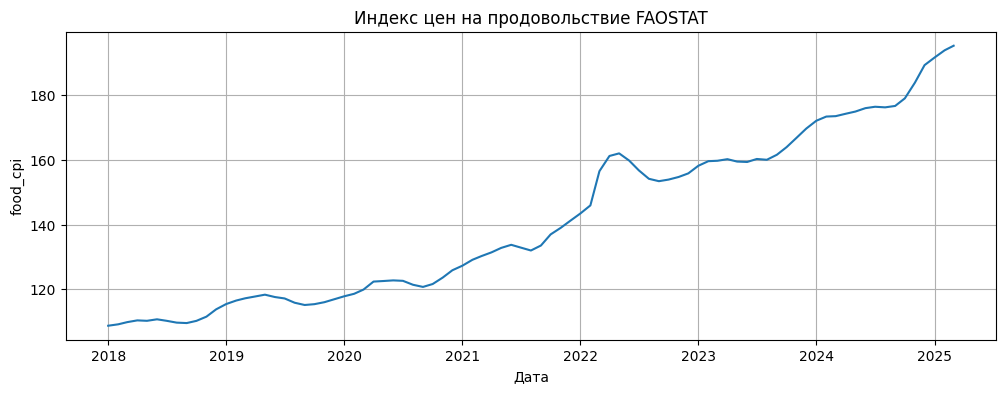

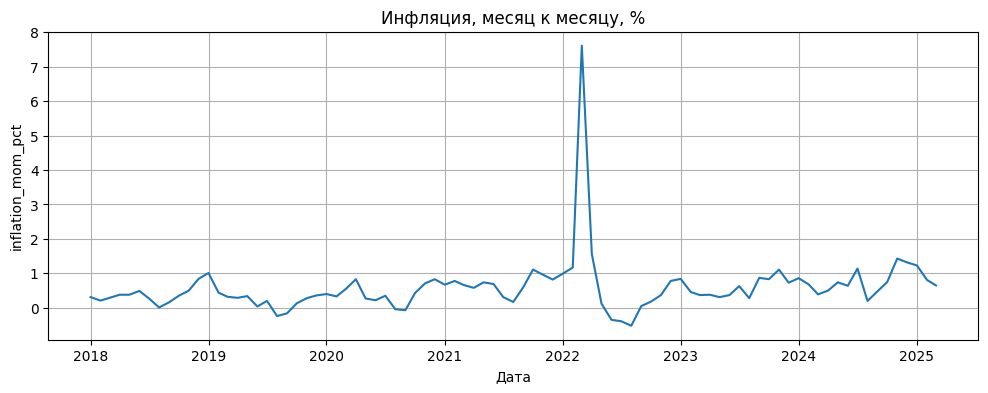

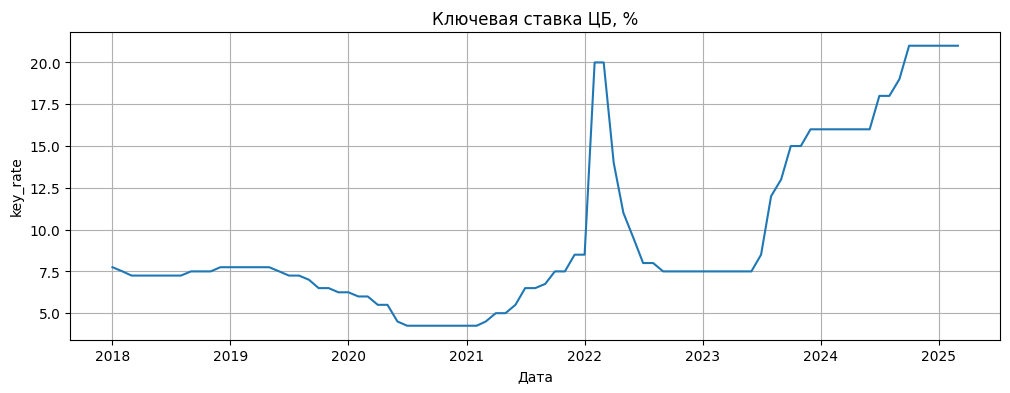

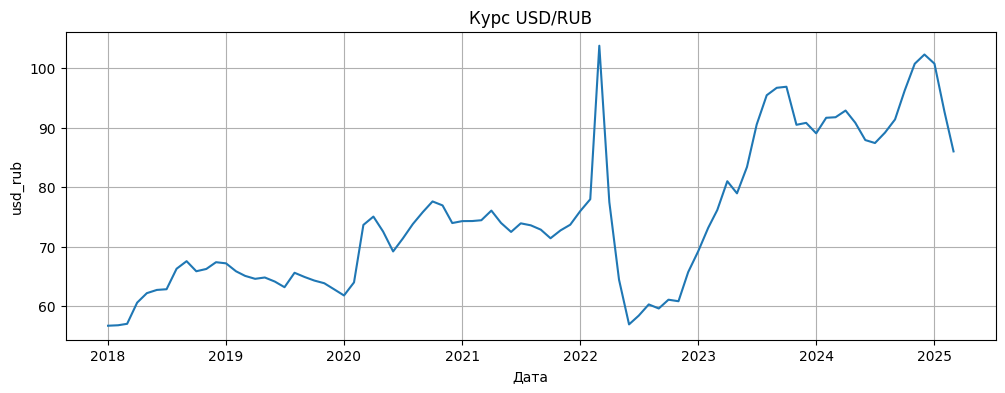

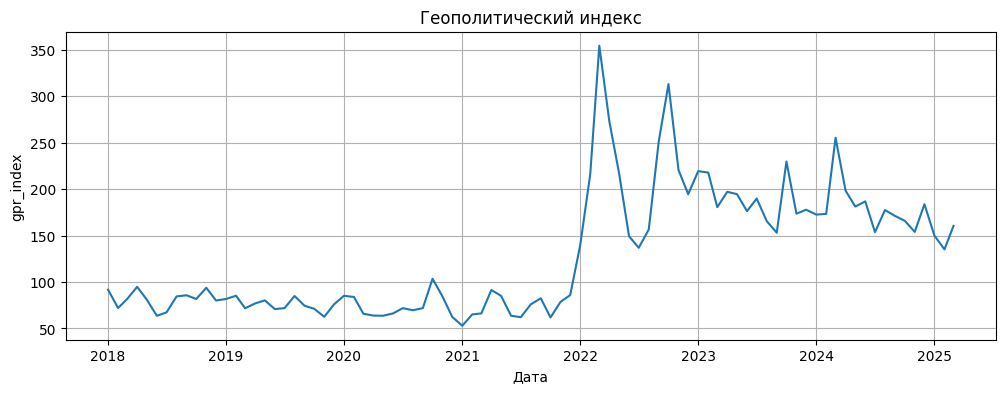

In [45]:
plot_cols = {
    "food_cpi": "Индекс цен на продовольствие FAOSTAT",
    "inflation_mom_pct": "Инфляция, месяц к месяцу, %",
    "key_rate": "Ключевая ставка ЦБ, %",
    "usd_rub": "Курс USD/RUB",
    "gpr_index": "Геополитический индекс",
}

for col, title in plot_cols.items():
    if col in data_model_raw.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(data_model_raw["date"], data_model_raw[col])
        plt.title(title)
        plt.xlabel("Дата")
        plt.ylabel(col)
        plt.grid(True)
        plt.show()

In [46]:
data_model_raw["food_cpi_mom_pct"] = data_model_raw["food_cpi"].pct_change() * 100
data_model_raw["log_food_cpi"] = np.log(data_model_raw["food_cpi"])

data_model_raw["usd_rub_pct_change"] = data_model_raw["usd_rub"].pct_change() * 100
data_model_raw["key_rate_diff"] = data_model_raw["key_rate"].diff()
data_model_raw["gpr_index_diff"] = data_model_raw["gpr_index"].diff()

display(data_model_raw.head())

,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411


,food_cpi,food_cpi_mom_pct,inflation_mom_pct,key_rate,key_rate_diff,usd_rub,usd_rub_pct_change,gpr_index,gpr_index_diff
food_cpi,1.000,0.190,0.234,0.795,0.065,0.750,-0.070,0.731,-0.024
food_cpi_mom_pct,0.190,1.000,0.862,0.359,0.054,0.452,0.245,0.294,0.235
inflation_mom_pct,0.234,0.862,1.000,0.402,0.071,0.478,0.462,0.411,0.358
key_rate,0.795,0.359,0.402,1.000,0.247,0.749,-0.002,0.587,0.101
key_rate_diff,0.065,0.054,0.071,0.247,1.000,0.230,0.345,0.041,0.343
usd_rub,0.750,0.452,0.478,0.749,0.230,1.000,0.192,0.468,0.133
usd_rub_pct_change,-0.070,0.245,0.462,-0.002,0.345,0.192,1.000,0.125,0.510
gpr_index,0.731,0.294,0.411,0.587,0.041,0.468,0.125,1.000,0.255
gpr_index_diff,-0.024,0.235,0.358,0.101,0.343,0.133,0.510,0.255,1.000


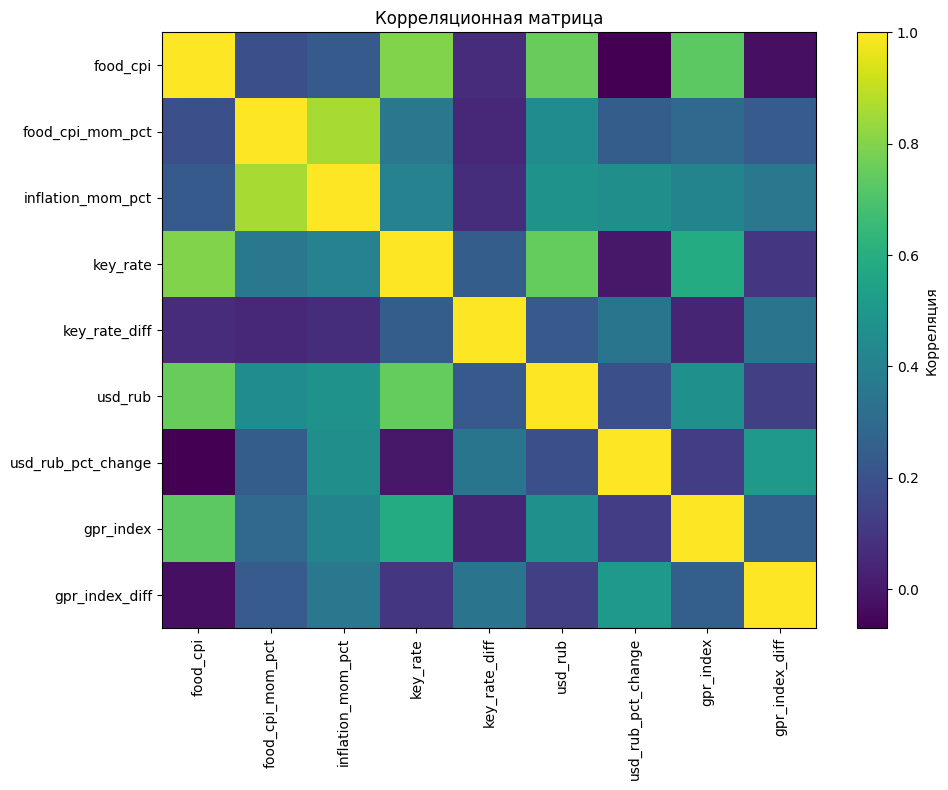

In [47]:
#  Корреляционный анализ

corr_cols = [
    "food_cpi",
    "food_cpi_mom_pct",
    "inflation_mom_pct",
    "key_rate",
    "key_rate_diff",
    "usd_rub",
    "usd_rub_pct_change",
    "gpr_index",
    "gpr_index_diff",
]

corr_cols = [col for col in corr_cols if col in data_model_raw.columns]

corr_matrix = data_model_raw[corr_cols].corr()

display(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Корреляция")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

In [48]:
# Проверка стационарности: ADF-тест

def adf_test(series, name):
    s = series.dropna()

    if len(s) < 20:
        return {
            "series": name,
            "n_obs": len(s),
            "adf_stat": np.nan,
            "p_value": np.nan,
            "stationary_5pct": None,
        }

    result = adfuller(s, autolag="AIC")

    return {
        "series": name,
        "n_obs": len(s),
        "adf_stat": result[0],
        "p_value": result[1],
        "stationary_5pct": result[1] < 0.05,
    }

adf_results = []

for col in corr_cols:
    adf_results.append(adf_test(data_model_raw[col], col))

adf_results = pd.DataFrame(adf_results)
display(adf_results)

,series,n_obs,adf_stat,p_value,stationary_5pct
0,food_cpi,87,1.143369,9.955703e-01,False
1,food_cpi_mom_pct,86,-5.073523,1.584333e-05,True
2,inflation_mom_pct,87,-6.616162,6.199747e-09,True
3,key_rate,87,-1.027863,7.429668e-01,False
4,key_rate_diff,86,-6.974651,8.489905e-10,True
5,usd_rub,87,-2.091183,2.480748e-01,False
6,usd_rub_pct_change,86,-6.514252,1.081218e-08,True
7,gpr_index,87,-1.372321,5.954716e-01,False
8,gpr_index_diff,86,-7.407606,7.274974e-11,True


In [49]:
# Лаговый корреляционный анализ
def lagged_correlation(df, y_col, x_col, max_lag=6):
    rows = []

    for lag in range(0, max_lag + 1):
        # lag = 1 означает: фактор за предыдущий месяц сопоставляется с ценой текущего месяца.
        corr = df[y_col].corr(df[x_col].shift(lag))
        rows.append({
            "factor": x_col,
            "lag_months": lag,
            "correlation": corr,
        })

    return pd.DataFrame(rows)


lag_corr_results = []

factor_cols_for_lags = [
    "inflation_mom_pct",
    "key_rate",
    "usd_rub",
    "gpr_index",
    "usd_rub_pct_change",
    "key_rate_diff",
    "gpr_index_diff",
]

for factor in factor_cols_for_lags:
    if factor in data_model_raw.columns:
        lag_corr_results.append(
            lagged_correlation(
                data_model_raw,
                y_col="food_cpi_mom_pct",
                x_col=factor,
                max_lag=6
            )
        )

lag_corr_results = pd.concat(lag_corr_results, ignore_index=True)

display(lag_corr_results.round(3))

best_lags = (
    lag_corr_results
    .assign(abs_corr=lambda x: x["correlation"].abs())
    .sort_values(["factor", "abs_corr"], ascending=[True, False])
    .groupby("factor")
    .head(1)
    .drop(columns=["abs_corr"])
    .reset_index(drop=True)
)

display(best_lags.round(3))

,factor,lag_months,correlation
0,inflation_mom_pct,0,0.862
1,inflation_mom_pct,1,0.445
2,inflation_mom_pct,2,0.115
3,inflation_mom_pct,3,-0.126
4,inflation_mom_pct,4,-0.213
5,inflation_mom_pct,5,-0.204
6,inflation_mom_pct,6,-0.151
7,key_rate,0,0.359
8,key_rate,1,0.353
9,key_rate,2,0.160


,factor,lag_months,correlation
0,gpr_index,0,0.294
1,gpr_index_diff,1,0.320
2,inflation_mom_pct,0,0.862
3,key_rate,0,0.359
4,key_rate_diff,1,0.619
5,usd_rub,0,0.452
6,usd_rub_pct_change,1,0.274


In [50]:
# Feature engineering для прогнозных моделей

model_df = data_model_raw.copy()
model_df = model_df.sort_values("date").reset_index(drop=True)

model_df["trend"] = np.arange(len(model_df))
model_df["month"] = model_df["date"].dt.month

# Лаги целевой переменной
for lag in [1, 2, 3, 6, 12]:
    model_df[f"log_food_cpi_lag{lag}"] = model_df["log_food_cpi"].shift(lag)

# Лаги макрофакторов
macro_cols = ["inflation_mom_pct", "key_rate", "usd_rub", "gpr_index"]

for col in macro_cols:
    for lag in [1, 2, 3]:
        model_df[f"{col}_lag{lag}"] = model_df[col].shift(lag)

# Фиктивные переменные событий
model_df["event_covid"] = (
    (model_df["date"] >= "2020-03-01") &
    (model_df["date"] <= "2021-12-01")
).astype(int)

model_df["event_2022_sanctions"] = (
    model_df["date"] >= "2022-02-01"
).astype(int)

# Месяцы с экстремально высоким геополитическим риском
gpr_q90 = model_df["gpr_index"].quantile(0.90)

model_df["event_high_gpr"] = (
    model_df["gpr_index"] >= gpr_q90
).astype(int)

# Сезонные dummy-переменные
model_df = pd.get_dummies(
    model_df,
    columns=["month"],
    prefix="month",
    drop_first=True
)

display(model_df.head())

,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,False,False,False,False,False,False,False,False,False,False,False
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268,1,4.689174,NaN,NaN,NaN,NaN,0.31,NaN,NaN,7.75,NaN,NaN,56.7418,NaN,NaN,91.679291,NaN,NaN,0,0,0,True,False,False,False,False,False,False,False,False,False,False
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326,2,4.693166,4.689174,NaN,NaN,NaN,0.21,0.31,NaN,7.50,7.75,NaN,56.8191,56.7418,NaN,71.955023,91.679291,NaN,0,0,0,False,True,False,False,False,False,False,False,False,False,False
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866,3,4.699347,4.693166,4.689174,NaN,NaN,0.29,0.21,0.31,7.25,7.50,7.75,57.0631,56.8191,56.7418,81.680349,71.955023,91.679291,0,0,0,False,False,True,False,False,False,False,False,False,False,False
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411,4,4.704235,4.699347,4.693166,NaN,NaN,0.38,0.29,0.21,7.25,7.25,7.50,60.6202,57.0631,56.8191,94.818215,81.680349,71.955023,0,0,0,False,False,False,True,False,False,False,False,False,False,False


In [51]:
# Подготовка признаков
target_col = "log_food_cpi"

base_features = [
    "trend",
    "log_food_cpi_lag1",
    "log_food_cpi_lag2",
    "log_food_cpi_lag3",
    "log_food_cpi_lag6",
    "log_food_cpi_lag12",
]

seasonal_features = [col for col in model_df.columns if col.startswith("month_")]

base_features = base_features + seasonal_features

macro_features = base_features + [
    "inflation_mom_pct_lag1",
    "inflation_mom_pct_lag2",
    "inflation_mom_pct_lag3",
    "key_rate_lag1",
    "key_rate_lag2",
    "key_rate_lag3",
    "usd_rub_lag1",
    "usd_rub_lag2",
    "usd_rub_lag3",
    "gpr_index_lag1",
    "gpr_index_lag2",
    "gpr_index_lag3",
    "event_covid",
    "event_2022_sanctions",
    "event_high_gpr",
]

required_cols = ["date", "food_cpi", target_col] + macro_features

model_data = model_df[required_cols].dropna().copy()

# Приводим признаки к числовому типу
for col in base_features + macro_features:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")

model_data = model_data.dropna().reset_index(drop=True)

print("Данные для обучения:", model_data.shape)
display(model_data.head())
display(model_data.tail())

Данные для обучения: (75, 35)


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr
0,2019-01-01,115.4584,4.748910,12,4.734711,4.714615,4.702884,4.703017,4.689174,False,False,False,False,False,False,False,False,False,False,False,0.84,0.50,0.35,7.75,7.50,7.50,67.4059,66.2722,65.8870,80.067765,93.762530,81.704646,0,0,0
1,2019-02-01,116.5437,4.758266,13,4.748910,4.734711,4.714615,4.697903,4.693166,True,False,False,False,False,False,False,False,False,False,False,1.01,0.84,0.50,7.75,7.75,7.50,67.2146,67.4059,66.2722,81.690165,80.067765,93.762530,0,0,0
2,2019-03-01,117.2430,4.764249,14,4.758266,4.748910,4.734711,4.696703,4.699347,False,True,False,False,False,False,False,False,False,False,False,0.44,1.01,0.84,7.75,7.75,7.75,65.8795,67.2146,67.4059,85.208330,81.690165,80.067765,0,0,0
3,2019-04-01,117.8057,4.769037,15,4.764249,4.758266,4.748910,4.702884,4.704235,False,False,True,False,False,False,False,False,False,False,False,0.32,0.44,1.01,7.75,7.75,7.75,65.1104,65.8795,67.2146,71.700618,85.208330,81.690165,0,0,0
4,2019-05-01,118.3594,4.773726,16,4.769037,4.764249,4.758266,4.714615,4.703034,False,False,False,True,False,False,False,False,False,False,False,0.29,0.32,0.44,7.75,7.75,7.75,64.6159,65.1104,65.8795,76.895628,71.700618,85.208330,0,0,0


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr
70,2024-11-01,183.864807,5.214201,82,5.187614,5.174401,5.171948,5.164552,5.117140,False,False,False,False,False,False,False,False,False,True,False,0.75,0.48,0.20,21.0,19.0,18.0,96.2429,91.3736,89.1666,165.926128,171.101934,177.422943,0,1,0
71,2024-12-01,189.307156,5.243371,83,5.214201,5.187614,5.174401,5.170544,5.134046,False,False,False,False,False,False,False,False,False,False,True,1.43,0.75,0.48,21.0,21.0,19.0,100.7252,96.2429,91.3736,153.904047,165.926128,171.101934,0,1,0
72,2025-01-01,191.657261,5.255709,84,5.243371,5.214201,5.187614,5.173000,5.148159,False,False,False,False,False,False,False,False,False,False,False,1.32,1.43,0.75,21.0,21.0,21.0,102.2782,100.7252,96.2429,183.700777,153.904047,165.926128,0,1,0
73,2025-02-01,193.883676,5.267258,85,5.255709,5.243371,5.214201,5.171948,5.155676,True,False,False,False,False,False,False,False,False,False,False,1.23,1.32,1.43,21.0,21.0,21.0,100.7428,102.2782,100.7252,149.831407,183.700777,153.904047,0,1,0
74,2025-03-01,195.306109,5.274568,86,5.267258,5.255709,5.243371,5.174401,5.156389,False,True,False,False,False,False,False,False,False,False,False,0.81,1.23,1.32,21.0,21.0,21.0,92.6708,100.7428,102.2782,135.095197,149.831407,183.700777,0,1,0


In [52]:
# Train-test split по времени

TEST_MONTHS = 12

test_start = model_data["date"].max() - pd.DateOffset(months=TEST_MONTHS - 1)

train = model_data[model_data["date"] < test_start].copy()
test = model_data[model_data["date"] >= test_start].copy()

print("Начало тестового периода:", test_start.date())
print("Train:", train["date"].min().date(), "-", train["date"].max().date(), "|", train.shape)
print("Test:", test["date"].min().date(), "-", test["date"].max().date(), "|", test.shape)

display(test[["date", "food_cpi"]])

Начало тестового периода: 2024-04-01
Train: 2019-01-01 - 2024-03-01 | (63, 35)
Test: 2024-04-01 - 2025-03-01 | (12, 35)


,date,food_cpi
63,2024-04-01,174.278852
64,2024-05-01,174.959145
65,2024-06-01,176.010508
66,2024-07-01,176.443422
67,2024-08-01,176.257888
68,2024-09-01,176.690802
69,2024-10-01,179.040907
70,2024-11-01,183.864807
71,2024-12-01,189.307156
72,2025-01-01,191.657261


In [53]:
# Эконометрическая модель OLS без макрофакторов

def fit_ols_forecast(train, test, features, model_name):
    X_train = sm.add_constant(train[features].astype(float), has_constant="add")
    y_train = train[target_col].astype(float)

    X_test = sm.add_constant(test[features].astype(float), has_constant="add")
    y_test_level = test["food_cpi"].astype(float)

    model = sm.OLS(y_train, X_train).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 3}
    )

    pred_log = model.predict(X_test)
    pred_level = np.exp(pred_log)

    metrics = calc_metrics(
        y_true=y_test_level,
        y_pred=pred_level,
        model_name=model_name
    )

    forecast = pd.DataFrame({
        "date": test["date"].values,
        "actual_food_cpi": y_test_level.values,
        f"forecast_{model_name}": pred_level.values,
    })

    return model, forecast, metrics


ols_base_model, ols_base_forecast, ols_base_metrics = fit_ols_forecast(
    train=train,
    test=test,
    features=base_features,
    model_name="OLS_base_without_macro"
)

print(ols_base_model.summary())
display(ols_base_forecast)
display(pd.DataFrame([ols_base_metrics]))

                            OLS Regression Results                            
Dep. Variable:           log_food_cpi   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     4578.
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           4.85e-67
Time:                        13:37:38   Log-Likelihood:                 214.92
No. Observations:                  63   AIC:                            -393.8
Df Residuals:                      45   BIC:                            -355.3
Df Model:                          17                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6006      0

,date,actual_food_cpi,forecast_OLS_base_without_macro
0,2024-04-01,174.278852,174.836221
1,2024-05-01,174.959145,175.096288
2,2024-06-01,176.010508,175.399269
3,2024-07-01,176.443422,176.305881
4,2024-08-01,176.257888,175.594193
5,2024-09-01,176.690802,177.150876
6,2024-10-01,179.040907,178.638574
7,2024-11-01,183.864807,181.380779
8,2024-12-01,189.307156,187.366839
9,2025-01-01,191.657261,192.640788


,model,MAE,RMSE,MAPE_%,R2
0,OLS_base_without_macro,0.906586,1.155332,0.488172,0.977539


In [54]:
# Эконометрическая модель OLS с макроэкономическими и геополитическими факторами

ols_macro_model, ols_macro_forecast, ols_macro_metrics = fit_ols_forecast(
    train=train,
    test=test,
    features=macro_features,
    model_name="OLS_with_macro_and_gpr"
)

print(ols_macro_model.summary())
display(ols_macro_forecast)
display(pd.DataFrame([ols_macro_metrics]))

                            OLS Regression Results                            
Dep. Variable:           log_food_cpi   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.526e+04
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           3.55e-65
Time:                        13:37:38   Log-Likelihood:                 270.80
No. Observations:                  63   AIC:                            -475.6
Df Residuals:                      30   BIC:                            -404.9
Df Model:                          32                                         
Covariance Type:                  HAC                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

,date,actual_food_cpi,forecast_OLS_with_macro_and_gpr
0,2024-04-01,174.278852,174.580542
1,2024-05-01,174.959145,174.863006
2,2024-06-01,176.010508,174.933331
3,2024-07-01,176.443422,176.052387
4,2024-08-01,176.257888,176.322045
5,2024-09-01,176.690802,177.412199
6,2024-10-01,179.040907,178.999641
7,2024-11-01,183.864807,183.553318
8,2024-12-01,189.307156,187.449387
9,2025-01-01,191.657261,191.576493


,model,MAE,RMSE,MAPE_%,R2
0,OLS_with_macro_and_gpr,0.580698,0.808949,0.313722,0.988988


In [55]:
# Проверка мультиколлинеарности VIF
def calculate_vif(df, features):
    X = df[features].astype(float).copy()
    X = sm.add_constant(X, has_constant="add")

    rows = []

    for i, col in enumerate(X.columns):
        try:
            vif_value = variance_inflation_factor(X.values, i)
        except Exception:
            vif_value = np.nan

        rows.append({
            "feature": col,
            "VIF": vif_value,
        })

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)


vif_table = calculate_vif(train, macro_features)

display(vif_table)

,feature,VIF
0,const,657891.900519
3,log_food_cpi_lag2,6396.533476
2,log_food_cpi_lag1,3602.221384
4,log_food_cpi_lag3,3553.346851
1,trend,427.830191
5,log_food_cpi_lag6,345.195357
6,log_food_cpi_lag12,103.213840
22,key_rate_lag2,87.556777
25,usd_rub_lag2,74.983096
23,key_rate_lag3,73.019122


In [56]:
# Ridge-регрессия: более устойчивая модель при мультиколлинеарности

def fit_sklearn_model(train, test, features, model, model_name):
    X_train = train[features].astype(float)
    y_train = train[target_col].astype(float)

    X_test = test[features].astype(float)
    y_test_level = test["food_cpi"].astype(float)

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_level = np.exp(pred_log)

    metrics = calc_metrics(
        y_true=y_test_level,
        y_pred=pred_level,
        model_name=model_name
    )

    forecast = pd.DataFrame({
        "date": test["date"].values,
        "actual_food_cpi": y_test_level.values,
        f"forecast_{model_name}": pred_level,
    })

    return model, forecast, metrics


ridge_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_macro = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_base_model, ridge_base_forecast, ridge_base_metrics = fit_sklearn_model(
    train=train,
    test=test,
    features=base_features,
    model=ridge_base,
    model_name="Ridge_base_without_macro"
)

ridge_macro_model, ridge_macro_forecast, ridge_macro_metrics = fit_sklearn_model(
    train=train,
    test=test,
    features=macro_features,
    model=ridge_macro,
    model_name="Ridge_with_macro_and_gpr"
)

display(pd.DataFrame([ridge_base_metrics, ridge_macro_metrics]))

,model,MAE,RMSE,MAPE_%,R2
0,Ridge_base_without_macro,1.686596,2.138753,0.922388,0.923027
1,Ridge_with_macro_and_gpr,1.007555,1.300908,0.556560,0.971522


In [57]:
# Random Forest как дополнительная нелинейная модель
rf_macro = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

rf_macro_model, rf_macro_forecast, rf_macro_metrics = fit_sklearn_model(
    train=train,
    test=test,
    features=macro_features,
    model=rf_macro,
    model_name="RandomForest_with_macro_and_gpr"
)

display(pd.DataFrame([rf_macro_metrics]))
display(rf_macro_forecast)

,model,MAE,RMSE,MAPE_%,R2
0,RandomForest_with_macro_and_gpr,12.954506,15.239533,6.936427,-2.908051


,date,actual_food_cpi,forecast_RandomForest_with_macro_and_gpr
0,2024-04-01,174.278852,169.779117
1,2024-05-01,174.959145,169.709660
2,2024-06-01,176.010508,169.680400
3,2024-07-01,176.443422,169.684793
4,2024-08-01,176.257888,169.226257
5,2024-09-01,176.690802,169.019205
6,2024-10-01,179.040907,169.518204
7,2024-11-01,183.864807,169.804035
8,2024-12-01,189.307156,169.487950
9,2025-01-01,191.657261,169.222602


In [58]:
# SARIMAX без внешних факторов и с внешними факторами

sarimax_df = data_model_raw.copy()
sarimax_df = sarimax_df.sort_values("date").reset_index(drop=True)

sarimax_df["log_food_cpi"] = np.log(sarimax_df["food_cpi"])

sarimax_exog_cols = [
    "inflation_mom_pct",
    "key_rate",
    "usd_rub",
    "gpr_index",
]

sarimax_df = sarimax_df.dropna(subset=["log_food_cpi"] + sarimax_exog_cols).copy()

sarimax_test_start = sarimax_df["date"].max() - pd.DateOffset(months=TEST_MONTHS - 1)

sarimax_train = sarimax_df[sarimax_df["date"] < sarimax_test_start].copy()
sarimax_test = sarimax_df[sarimax_df["date"] >= sarimax_test_start].copy()

print("SARIMAX train:", sarimax_train["date"].min().date(), "-", sarimax_train["date"].max().date())
print("SARIMAX test:", sarimax_test["date"].min().date(), "-", sarimax_test["date"].max().date())

# Модель 1: без внешних факторов
sarimax_base = SARIMAX(
    sarimax_train["log_food_cpi"],
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_base_res = sarimax_base.fit(disp=False)

sarimax_base_pred_log = sarimax_base_res.get_forecast(
    steps=len(sarimax_test)
).predicted_mean

sarimax_base_pred = np.exp(sarimax_base_pred_log)

sarimax_base_metrics = calc_metrics(
    y_true=sarimax_test["food_cpi"],
    y_pred=sarimax_base_pred,
    model_name="SARIMAX_without_macro"
)

# Модель 2: с внешними факторами
sarimax_macro = SARIMAX(
    sarimax_train["log_food_cpi"],
    exog=sarimax_train[sarimax_exog_cols],
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_macro_res = sarimax_macro.fit(disp=False)

sarimax_macro_pred_log = sarimax_macro_res.get_forecast(
    steps=len(sarimax_test),
    exog=sarimax_test[sarimax_exog_cols]
).predicted_mean

sarimax_macro_pred = np.exp(sarimax_macro_pred_log)

sarimax_macro_metrics = calc_metrics(
    y_true=sarimax_test["food_cpi"],
    y_pred=sarimax_macro_pred,
    model_name="SARIMAX_with_macro_and_gpr"
)

sarimax_forecast = pd.DataFrame({
    "date": sarimax_test["date"].values,
    "actual_food_cpi": sarimax_test["food_cpi"].values,
    "forecast_SARIMAX_without_macro": sarimax_base_pred.values,
    "forecast_SARIMAX_with_macro_and_gpr": sarimax_macro_pred.values,
})

display(pd.DataFrame([sarimax_base_metrics, sarimax_macro_metrics]))
display(sarimax_forecast)

SARIMAX train: 2018-01-01 - 2024-03-01
SARIMAX test: 2024-04-01 - 2025-03-01


,model,MAE,RMSE,MAPE_%,R2
0,SARIMAX_without_macro,8.864841,11.754912,4.695795,-1.325175
1,SARIMAX_with_macro_and_gpr,10.393880,13.104974,5.530127,-1.889943


,date,actual_food_cpi,forecast_SARIMAX_without_macro,forecast_SARIMAX_with_macro_and_gpr
0,2024-04-01,174.278852,173.492219,172.596350
1,2024-05-01,174.959145,173.466566,172.523764
2,2024-06-01,176.010508,173.451774,172.490170
3,2024-07-01,176.443422,173.443245,172.664118
4,2024-08-01,176.257888,173.438326,171.698985
5,2024-09-01,176.690802,173.435490,171.660660
6,2024-10-01,179.040907,173.433854,171.373194
7,2024-11-01,183.864807,173.432911,171.523284
8,2024-12-01,189.307156,173.432367,171.401188
9,2025-01-01,191.657261,173.432053,171.317830


In [59]:
# Granger causality test

granger_df = data_model_raw.copy()

granger_df["food_cpi_mom_pct"] = granger_df["food_cpi"].pct_change() * 100
granger_df["usd_rub_pct_change"] = granger_df["usd_rub"].pct_change() * 100
granger_df["key_rate_diff"] = granger_df["key_rate"].diff()
granger_df["gpr_index_diff"] = granger_df["gpr_index"].diff()

granger_factors = {
    "inflation_mom_pct": "inflation_mom_pct",
    "usd_rub_pct_change": "usd_rub_pct_change",
    "key_rate_diff": "key_rate_diff",
    "gpr_index_diff": "gpr_index_diff",
}

granger_results = []

MAX_LAG = 6

for factor_name, factor_col in granger_factors.items():
    temp = granger_df[["food_cpi_mom_pct", factor_col]].dropna()

    if len(temp) > MAX_LAG + 10:
        try:
            result = grangercausalitytests(
                temp[["food_cpi_mom_pct", factor_col]],
                maxlag=MAX_LAG,
                verbose=False
            )

            for lag in range(1, MAX_LAG + 1):
                p_value = result[lag][0]["ssr_ftest"][1]

                granger_results.append({
                    "factor": factor_name,
                    "lag": lag,
                    "p_value": p_value,
                    "significant_5pct": p_value < 0.05,
                })

        except Exception as e:
            granger_results.append({
                "factor": factor_name,
                "lag": None,
                "p_value": np.nan,
                "significant_5pct": None,
            })

granger_results = pd.DataFrame(granger_results)

display(granger_results)

best_granger = (
    granger_results
    .dropna(subset=["p_value"])
    .sort_values(["factor", "p_value"])
    .groupby("factor")
    .head(1)
    .reset_index(drop=True)
)

display(best_granger)

,factor,lag,p_value,significant_5pct
0,inflation_mom_pct,1,1.163898e-01,False
1,inflation_mom_pct,2,7.303983e-02,False
2,inflation_mom_pct,3,1.852408e-01,False
3,inflation_mom_pct,4,3.342582e-01,False
4,inflation_mom_pct,5,2.393305e-01,False
5,inflation_mom_pct,6,2.542563e-01,False
6,usd_rub_pct_change,1,1.422497e-01,False
7,usd_rub_pct_change,2,4.183189e-01,False
8,usd_rub_pct_change,3,9.319483e-01,False
9,usd_rub_pct_change,4,9.566579e-01,False


,factor,lag,p_value,significant_5pct
0,gpr_index_diff,1,3.547387e-02,True
1,inflation_mom_pct,2,7.303983e-02,False
2,key_rate_diff,1,2.370589e-15,True
3,usd_rub_pct_change,1,1.422497e-01,False


,model,MAE,RMSE,MAPE_%,R2
0,OLS_with_macro_and_gpr,0.580698,0.808949,0.313722,0.988988
1,OLS_base_without_macro,0.906586,1.155332,0.488172,0.977539
2,Ridge_with_macro_and_gpr,1.007555,1.300908,0.556560,0.971522
3,Ridge_base_without_macro,1.686596,2.138753,0.922388,0.923027
4,SARIMAX_without_macro,8.864841,11.754912,4.695795,-1.325175
5,SARIMAX_with_macro_and_gpr,10.393880,13.104974,5.530127,-1.889943
6,RandomForest_with_macro_and_gpr,12.954506,15.239533,6.936427,-2.908051


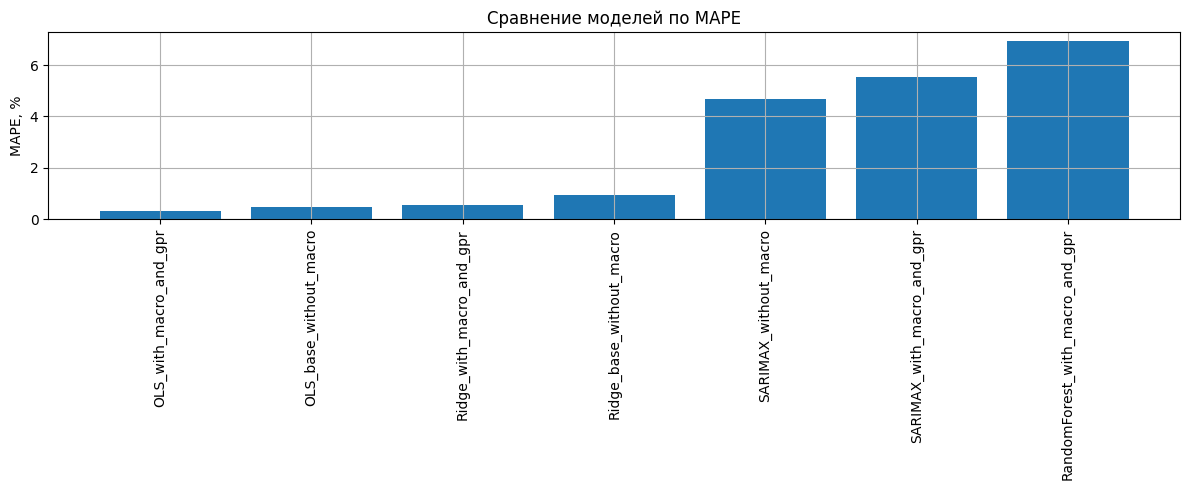

,model,MAE,RMSE,MAPE_%,R2
0,OLS_with_macro_and_gpr,0.580698,0.808949,0.313722,0.988988
1,OLS_base_without_macro,0.906586,1.155332,0.488172,0.977539
2,Ridge_with_macro_and_gpr,1.007555,1.300908,0.556560,0.971522
3,Ridge_base_without_macro,1.686596,2.138753,0.922388,0.923027
4,SARIMAX_without_macro,8.864841,11.754912,4.695795,-1.325175
5,SARIMAX_with_macro_and_gpr,10.393880,13.104974,5.530127,-1.889943
6,RandomForest_with_macro_and_gpr,12.954506,15.239533,6.936427,-2.908051


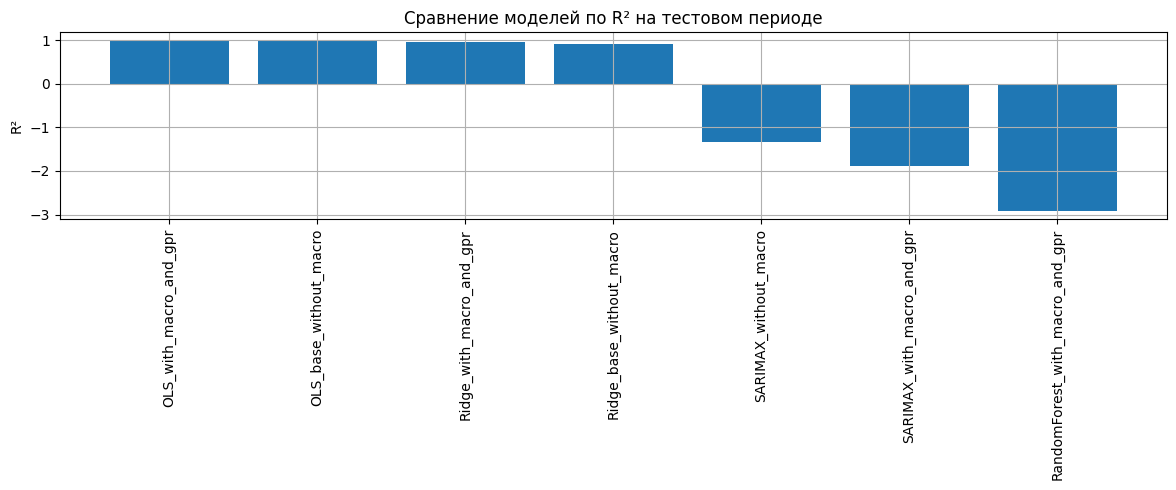

In [60]:
# Сравнение всех моделей

metrics_table = pd.DataFrame([
    ols_base_metrics,
    ols_macro_metrics,
    ridge_base_metrics,
    ridge_macro_metrics,
    rf_macro_metrics,
    sarimax_base_metrics,
    sarimax_macro_metrics,
])

metrics_table = metrics_table.sort_values("MAPE_%").reset_index(drop=True)

display(metrics_table)

plt.figure(figsize=(12, 5))
plt.bar(metrics_table["model"], metrics_table["MAPE_%"])
plt.title("Сравнение моделей по MAPE")
plt.ylabel("MAPE, %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

metrics_table_r2 = metrics_table.sort_values("R2", ascending=False).reset_index(drop=True)

display(metrics_table_r2)

plt.figure(figsize=(12, 5))
plt.bar(metrics_table_r2["model"], metrics_table_r2["R2"])
plt.title("Сравнение моделей по R² на тестовом периоде")
plt.ylabel("R²")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
# Оценка улучшения прогноза при добавлении макрофакторов


def improvement_pct(base_error, improved_error):
    return (base_error - improved_error) / base_error * 100


comparison_rows = []

pairs = [
    ("OLS_base_without_macro", "OLS_with_macro_and_gpr"),
    ("Ridge_base_without_macro", "Ridge_with_macro_and_gpr"),
    ("SARIMAX_without_macro", "SARIMAX_with_macro_and_gpr"),
]

for base_model, macro_model in pairs:
    base_row = metrics_table.loc[metrics_table["model"] == base_model]
    macro_row = metrics_table.loc[metrics_table["model"] == macro_model]

    if len(base_row) > 0 and len(macro_row) > 0:
        base_mape = base_row["MAPE_%"].values[0]
        macro_mape = macro_row["MAPE_%"].values[0]

        base_rmse = base_row["RMSE"].values[0]
        macro_rmse = macro_row["RMSE"].values[0]

        base_r2 = base_row["R2"].values[0]
        macro_r2 = macro_row["R2"].values[0]

        comparison_rows.append({
            "base_model": base_model,
            "macro_model": macro_model,
            "base_MAPE_%": base_mape,
            "macro_MAPE_%": macro_mape,
            "MAPE_improvement_%": improvement_pct(base_mape, macro_mape),
            "base_RMSE": base_rmse,
            "macro_RMSE": macro_rmse,
            "RMSE_improvement_%": improvement_pct(base_rmse, macro_rmse),
            "base_R2": base_r2,
            "macro_R2": macro_r2,
            "R2_change": macro_r2 - base_r2,
        })

improvement_table = pd.DataFrame(comparison_rows)

display(improvement_table)

,base_model,macro_model,base_MAPE_%,macro_MAPE_%,MAPE_improvement_%,base_RMSE,macro_RMSE,RMSE_improvement_%,base_R2,macro_R2,R2_change
0,OLS_base_without_macro,OLS_with_macro_and_gpr,0.488172,0.313722,35.735325,1.155332,0.808949,29.981251,0.977539,0.988988,0.011449
1,Ridge_base_without_macro,Ridge_with_macro_and_gpr,0.922388,0.556560,39.660949,2.138753,1.300908,39.174493,0.923027,0.971522,0.048495
2,SARIMAX_without_macro,SARIMAX_with_macro_and_gpr,4.695795,5.530127,-17.767646,11.754912,13.104974,-11.485087,-1.325175,-1.889943,-0.564768


,date,actual_food_cpi,forecast_OLS_base_without_macro,forecast_OLS_with_macro_and_gpr,forecast_Ridge_with_macro_and_gpr,forecast_RandomForest_with_macro_and_gpr
0,2024-04-01,174.278852,174.836221,174.580542,175.498755,169.779117
1,2024-05-01,174.959145,175.096288,174.863006,175.753590,169.709660
2,2024-06-01,176.010508,175.399269,174.933331,175.796016,169.680400
3,2024-07-01,176.443422,176.305881,176.052387,176.956455,169.684793
4,2024-08-01,176.257888,175.594193,176.322045,178.791676,169.226257
5,2024-09-01,176.690802,177.150876,177.412199,177.677695,169.019205
6,2024-10-01,179.040907,178.638574,178.999641,180.419127,169.518204
7,2024-11-01,183.864807,181.380779,183.553318,183.396275,169.804035
8,2024-12-01,189.307156,187.366839,187.449387,186.542083,169.487950
9,2025-01-01,191.657261,192.640788,191.576493,190.882971,169.222602


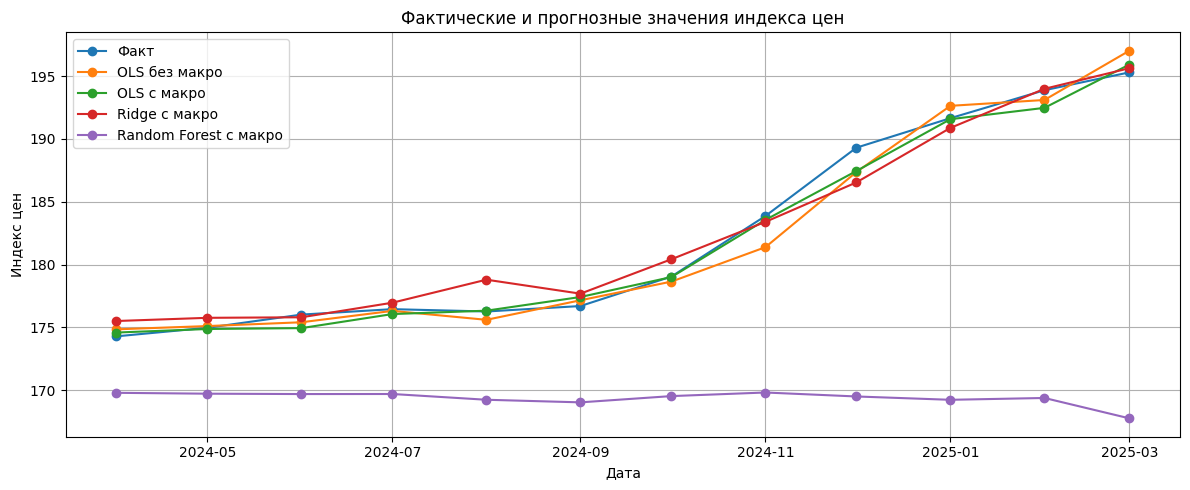

In [62]:
# График факта и прогнозов

forecast_plot = test[["date", "food_cpi"]].copy()
forecast_plot = forecast_plot.rename(columns={"food_cpi": "actual_food_cpi"})

forecast_plot = forecast_plot.merge(
    ols_base_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_plot = forecast_plot.merge(
    ols_macro_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_plot = forecast_plot.merge(
    ridge_macro_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_plot = forecast_plot.merge(
    rf_macro_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

display(forecast_plot)

plt.figure(figsize=(12, 5))
plt.plot(forecast_plot["date"], forecast_plot["actual_food_cpi"], marker="o", label="Факт")
plt.plot(forecast_plot["date"], forecast_plot["forecast_OLS_base_without_macro"], marker="o", label="OLS без макро")
plt.plot(forecast_plot["date"], forecast_plot["forecast_OLS_with_macro_and_gpr"], marker="o", label="OLS с макро")
plt.plot(forecast_plot["date"], forecast_plot["forecast_Ridge_with_macro_and_gpr"], marker="o", label="Ridge с макро")
plt.plot(forecast_plot["date"], forecast_plot["forecast_RandomForest_with_macro_and_gpr"], marker="o", label="Random Forest с макро")

plt.title("Фактические и прогнозные значения индекса цен")
plt.xlabel("Дата")
plt.ylabel("Индекс цен")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
best_model_mape = metrics_table.sort_values("MAPE_%").iloc[0]
best_model_r2 = metrics_table.sort_values("R2", ascending=False).iloc[0]

print("Лучшая модель по MAPE:")
print(best_model_mape)

print("\nЛучшая модель по R²:")
print(best_model_r2)

print("\nУлучшение при добавлении макроэкономических и геополитических факторов:")
display(improvement_table)

for _, row in improvement_table.iterrows():
    print("\n" + "-" * 80)

    print(f"Сравнение: {row['base_model']} -> {row['macro_model']}")

    if row["MAPE_improvement_%"] > 0:
        print(
            f"Добавление макроэкономических и геополитических факторов снизило MAPE "
            f"с {row['base_MAPE_%']:.2f}% до {row['macro_MAPE_%']:.2f}%. "
            f"Относительное улучшение составило {row['MAPE_improvement_%']:.2f}%."
        )
    else:
        print(
            f"Добавление макроэкономических и геополитических факторов не снизило MAPE: "
            f"показатель изменился с {row['base_MAPE_%']:.2f}% до {row['macro_MAPE_%']:.2f}%."
        )

    if row["R2_change"] > 0:
        print(
            f"R² увеличился с {row['base_R2']:.3f} до {row['macro_R2']:.3f}. "
            f"Это означает, что модель с факторами лучше объясняет вариацию цен на тестовом периоде."
        )
    else:
        print(
            f"R² не улучшился: показатель изменился с {row['base_R2']:.3f} "
            f"до {row['macro_R2']:.3f}."
        )

Лучшая модель по MAPE:
model     OLS_with_macro_and_gpr
MAE                     0.580698
RMSE                    0.808949
MAPE_%                  0.313722
R2                      0.988988
Name: 0, dtype: object

Лучшая модель по R²:
model     OLS_with_macro_and_gpr
MAE                     0.580698
RMSE                    0.808949
MAPE_%                  0.313722
R2                      0.988988
Name: 0, dtype: object

Улучшение при добавлении макроэкономических и геополитических факторов:


,base_model,macro_model,base_MAPE_%,macro_MAPE_%,MAPE_improvement_%,base_RMSE,macro_RMSE,RMSE_improvement_%,base_R2,macro_R2,R2_change
0,OLS_base_without_macro,OLS_with_macro_and_gpr,0.488172,0.313722,35.735325,1.155332,0.808949,29.981251,0.977539,0.988988,0.011449
1,Ridge_base_without_macro,Ridge_with_macro_and_gpr,0.922388,0.556560,39.660949,2.138753,1.300908,39.174493,0.923027,0.971522,0.048495
2,SARIMAX_without_macro,SARIMAX_with_macro_and_gpr,4.695795,5.530127,-17.767646,11.754912,13.104974,-11.485087,-1.325175,-1.889943,-0.564768



--------------------------------------------------------------------------------
Сравнение: OLS_base_without_macro -> OLS_with_macro_and_gpr
Добавление макроэкономических и геополитических факторов снизило MAPE с 0.49% до 0.31%. Относительное улучшение составило 35.74%.
R² увеличился с 0.978 до 0.989. Это означает, что модель с факторами лучше объясняет вариацию цен на тестовом периоде.

--------------------------------------------------------------------------------
Сравнение: Ridge_base_without_macro -> Ridge_with_macro_and_gpr
Добавление макроэкономических и геополитических факторов снизило MAPE с 0.92% до 0.56%. Относительное улучшение составило 39.66%.
R² увеличился с 0.923 до 0.972. Это означает, что модель с факторами лучше объясняет вариацию цен на тестовом периоде.

--------------------------------------------------------------------------------
Сравнение: SARIMAX_without_macro -> SARIMAX_with_macro_and_gpr
Добавление макроэкономических и геополитических факторов не снизило M

In [64]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

import statsmodels.api as sm

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [65]:
DATA_DIR = Path(".")

REVIEWS_FILE = DATA_DIR / "geo-reviews-dataset-2023.csv"

print("Файл отзывов:", REVIEWS_FILE)
print("Файл существует:", REVIEWS_FILE.exists())

Файл отзывов: geo-reviews-dataset-2023.csv
Файл существует: True


In [66]:
def read_reviews_csv(path):
    for enc in ["utf-8", "utf-8-sig", "cp1251", "latin-1", "iso-8859-1"]:
        try: return pd.read_csv(path, encoding=enc)
        except: continue
    raise ValueError("Не удалось прочитать файл")

In [67]:
# Загрузка отзывов

def read_reviews_csv(path):
    encodings = ['utf-8', 'latin1', 'cp1251', 'cp1252', 'iso-8859-1']

    last_error = None

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Файл успешно прочитан с кодировкой: {enc}")
            return df
        except Exception as e:
            last_error = e

    raise last_error


reviews = read_reviews_csv(REVIEWS_FILE)

print("Размер датасета отзывов:", reviews.shape)
display(reviews.head())
display(reviews.info())

Файл успешно прочитан с кодировкой: utf-8
Размер датасета отзывов: (500000, 5)


,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   address  500000 non-null  object 
 1   name_ru  499030 non-null  object 
 2   rating   500000 non-null  float64
 3   rubrics  500000 non-null  object 
 4   text     500000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 19.1+ MB


None

In [68]:
# Первичная очистка данных
reviews.columns = [str(col).strip() for col in reviews.columns]

required_review_cols = ["address", "name_ru", "rating", "rubrics", "text"]

missing_cols = [col for col in required_review_cols if col not in reviews.columns]

if missing_cols:
    print("В файле нет ожидаемых столбцов:", missing_cols)
else:
    print("Все базовые столбцы найдены")

reviews["rating"] = (
    reviews["rating"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
)

reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")

reviews["text"] = reviews["text"].fillna("").astype(str)
reviews["rubrics"] = reviews["rubrics"].fillna("").astype(str)
reviews["name_ru"] = reviews["name_ru"].fillna("").astype(str)
reviews["address"] = reviews["address"].fillna("").astype(str)

reviews = reviews.dropna(subset=["rating"])
reviews = reviews[(reviews["rating"] >= 1) & (reviews["rating"] <= 5)].copy()

reviews["text_len"] = reviews["text"].str.len()
reviews["word_count"] = reviews["text"].str.split().str.len()

print("После очистки:", reviews.shape)
display(reviews[["name_ru", "rating", "rubrics", "text"]].head())

Все базовые столбцы найдены
После очистки: (499800, 7)


,name_ru,rating,rubrics,text
0,Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


In [69]:
# Автоматический поиск столбца с датой

print("Столбец с датой не найден.")
print("Будет использован ограниченный сценарий: все отзывы считаются данными за 2023 год.")
reviews["review_date"] = pd.NaT
reviews["review_month"] = pd.NaT

Столбец с датой не найден.
Будет использован ограниченный сценарий: все отзывы считаются данными за 2023 год.


In [70]:
# Фильтрация отзывов по товарным и продуктовым рубрикам

goods_keywords = [
    "магазин",
    "продукт",
    "супермаркет",
    "гипермаркет",
    "мяс",
    "колбас",
    "замороз",
    "овощ",
    "фрукт",
    "бакале",
    "рынок",
    "универсам",
    "ритейл",
    "рознич",
    "товар",
    "торгов",
]

pattern_goods = "|".join(goods_keywords)

reviews["is_goods_related"] = (
    reviews["rubrics"].str.lower().str.contains(pattern_goods, regex=True, na=False) |
    reviews["name_ru"].str.lower().str.contains(pattern_goods, regex=True, na=False) |
    reviews["text"].str.lower().str.contains(pattern_goods, regex=True, na=False)
).astype(int)

goods_reviews = reviews[reviews["is_goods_related"] == 1].copy()

print("Всего отзывов:", len(reviews))
print("Отзывы, связанные с товарами и торговлей:", len(goods_reviews))
print("Доля товарных отзывов:", round(len(goods_reviews) / len(reviews) * 100, 2), "%")

display(goods_reviews[["name_ru", "rating", "rubrics", "text"]].head(10))

Всего отзывов: 499800
Отзывы, связанные с товарами и торговлей: 135141
Доля товарных отзывов: 27.04 %


,name_ru,rating,rubrics,text
1,Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
7,Smoking Park,5.0,Вейп-шоп;Магазин табака и курительных принадле...,"Лучший шоп на крохалях \nБольшоц ассортимент, ..."
10,Kari ГИПЕР,5.0,Магазин обуви;Ювелирный магазин;Детские игрушк...,"Очень большой выбор обуви для всей семьи, по р..."
15,Healingbowl,5.0,Магазин подарков и сувениров;Музыкальный магазин,Заказывала чашу онлайн. Перед этим посмотрела ...
18,Эште Дёнер,1.0,Кафе;Быстрое питание;Доставка еды и обедов,"1. Доставка очень долгая, на рекламной брошюре..."
24,CompShop,5.0,Компьютерный магазин;Компьютерный ремонт и услуги,"Сдавал комп в чистку, всё сделали за один день..."
25,CompShop,5.0,Компьютерный магазин;Компьютерный ремонт и услуги,"Отличный сервисный центр и магазин ПК, приятны..."
30,Шатура,5.0,Магазин мебели,Заказала прихожую в ТЦ Ярмарка Мебели Говорово...
37,La Vie EN Roses,5.0,Магазин цветов;Магазин подарков и сувениров;То...,Спасибо за красивый качественный букетик цвето...
42,Шашлычок на Восточном,5.0,Кафе,Лучший шашлык в Звенигороде.\nПриветливый и ве...


In [71]:
#  Выделение ценовых упоминаний

price_keywords = [
    "цена",
    "цены",
    "ценник",
    "стоимость",
    "дорого",
    "дорогой",
    "дорогие",
    "дешево",
    "дешёвый",
    "дешевые",
    "скидка",
    "акция",
    "распродажа",
    "переплата",
    "доступно",
    "приемлемо",
    "недорого",
    "завышен",
    "завышены",
]

pattern_price = "|".join(price_keywords)

goods_reviews["has_price_mention"] = (
    goods_reviews["text"].str.lower().str.contains(pattern_price, regex=True, na=False)
).astype(int)

print("Отзывы с упоминанием цены:", goods_reviews["has_price_mention"].sum())
print("Доля отзывов с упоминанием цены:", round(goods_reviews["has_price_mention"].mean() * 100, 2), "%")

display(
    goods_reviews[goods_reviews["has_price_mention"] == 1][
        ["name_ru", "rating", "rubrics", "text"]
    ].head(10)
)

Отзывы с упоминанием цены: 37197
Доля отзывов с упоминанием цены: 27.52 %


,name_ru,rating,rubrics,text
1,Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
10,Kari ГИПЕР,5.0,Магазин обуви;Ювелирный магазин;Детские игрушк...,"Очень большой выбор обуви для всей семьи, по р..."
25,CompShop,5.0,Компьютерный магазин;Компьютерный ремонт и услуги,"Отличный сервисный центр и магазин ПК, приятны..."
70,Шефпорт,3.0,Магазин рыбы и морепродуктов,"Доступные цены, широкий выбор и свежая рыба. Ч..."
73,Черемушки,5.0,Супермаркет;Магазин продуктов,"Всегда беру здесь зелень, фрукты и овощи. По з..."
75,Кроха,4.0,Детский магазин;Детские игрушки и игры,"На первый взгляд товара много, но цены оставля..."
77,Парк Отель,5.0,Гостиница,"Моментальное бронирование, быстрая регистрация..."
78,Продсклад Победа,5.0,Магазин продуктов;Супермаркет,Большой выбор продуктов. Цены щадящие кошелек....
92,Домодедовский торговый двор,5.0,Строительный рынок,Хорошые цены .широкий выбор .Сантехника.электр...
119,Снежная королева,5.0,Кафе,"Хорошее кафе. Цены средние, порции большие. Пе..."


,rating,rating_sentiment,rating_class
1,5.0,1.0,positive
7,5.0,1.0,positive
10,5.0,1.0,positive
15,5.0,1.0,positive
18,1.0,-1.0,negative


,rating,count
0,1.0,10281
1,2.0,3704
2,3.0,6863
3,4.0,13428
4,5.0,100865


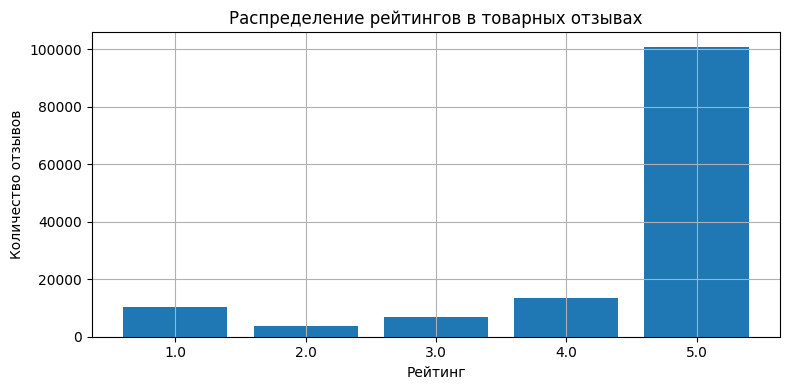

In [72]:
# Тональность по рейтингу

goods_reviews["rating_sentiment"] = (goods_reviews["rating"] - 3) / 2

goods_reviews["rating_class"] = np.select(
    [
        goods_reviews["rating"] >= 4,
        goods_reviews["rating"] == 3,
        goods_reviews["rating"] <= 2,
    ],
    [
        "positive",
        "neutral",
        "negative",
    ],
    default="unknown"
)

display(goods_reviews[["rating", "rating_sentiment", "rating_class"]].head())

rating_distribution = (
    goods_reviews["rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["rating", "count"]

display(rating_distribution)

plt.figure(figsize=(8, 4))
plt.bar(rating_distribution["rating"].astype(str), rating_distribution["count"])
plt.title("Распределение рейтингов в товарных отзывах")
plt.xlabel("Рейтинг")
plt.ylabel("Количество отзывов")
plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
# Простой лексический анализ тональности

positive_words = [
    "хорошо", "хороший", "хорошая", "хорошие",
    "отлично", "отличный", "отличная", "отличные",
    "замечательно", "замечательный",
    "нравится", "понравилось",
    "качественно", "качество",
    "вкусно", "свежий", "свежая", "свежие",
    "приемлемые", "приемлемая", "приемлемо",
    "доступно", "недорого",
    "вежливый", "удобно", "рекомендую",
    "спасибо", "лучший", "приятно",
]

negative_words = [
    "плохо", "плохой", "плохая", "плохие",
    "ужасно", "ужасный", "ужасная",
    "отвратительно", "отвратительный",
    "дорого", "дорогой", "дорогая", "дорогие",
    "хамство", "хамят", "обман",
    "грязно", "просрочка", "просроченный",
    "некачественный", "испорченный",
    "невкусно", "очередь", "очереди",
    "медленно", "не советую", "не рекомендую",
    "разочарование", "минус", "проблема",
    "завышены", "завышенная", "завышенный",
]

def clean_text_for_sentiment(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яёa-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def lexical_sentiment(text):
    text = clean_text_for_sentiment(text)

    pos_count = sum(1 for word in positive_words if word in text)
    neg_count = sum(1 for word in negative_words if word in text)

    total = pos_count + neg_count

    if total == 0:
        return 0

    return (pos_count - neg_count) / total


goods_reviews["text_clean"] = goods_reviews["text"].apply(clean_text_for_sentiment)
goods_reviews["lexical_sentiment"] = goods_reviews["text"].apply(lexical_sentiment)

display(
    goods_reviews[
        ["rating", "rating_sentiment", "lexical_sentiment", "has_price_mention", "text"]
    ].head(10)
)

,rating,rating_sentiment,lexical_sentiment,has_price_mention,text
1,5.0,1.0,1.0,1,"Замечательная сеть магазинов в общем, хороший ..."
7,5.0,1.0,1.0,0,"Лучший шоп на крохалях \nБольшоц ассортимент, ..."
10,5.0,1.0,0.0,1,"Очень большой выбор обуви для всей семьи, по р..."
15,5.0,1.0,0.0,0,Заказывала чашу онлайн. Перед этим посмотрела ...
18,1.0,-1.0,0.0,0,"1. Доставка очень долгая, на рекламной брошюре..."
24,5.0,1.0,0.0,0,"Сдавал комп в чистку, всё сделали за один день..."
25,5.0,1.0,1.0,1,"Отличный сервисный центр и магазин ПК, приятны..."
30,5.0,1.0,1.0,0,Заказала прихожую в ТЦ Ярмарка Мебели Говорово...
37,5.0,1.0,1.0,0,Спасибо за красивый качественный букетик цвето...
42,5.0,1.0,1.0,0,Лучший шашлык в Звенигороде.\nПриветливый и ве...


In [74]:
# Нейросетевой sentiment analysis через RuBERT

USE_TRANSFORMER_SENTIMENT = False

if USE_TRANSFORMER_SENTIMENT:
    from transformers import pipeline

    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="cointegrated/rubert-tiny-sentiment-balanced",
        tokenizer="cointegrated/rubert-tiny-sentiment-balanced",
        truncation=True,
        max_length=512
    )

    def transformer_sentiment_score(text):
        text = str(text)

        if len(text.strip()) == 0:
            return 0

        result = sentiment_pipeline(text[:2000])[0]

        label = result["label"].lower()
        score = result["score"]

        if "positive" in label:
            return score
        elif "negative" in label:
            return -score
        else:
            return 0

    goods_reviews["transformer_sentiment"] = goods_reviews["text"].apply(transformer_sentiment_score)

else:
    goods_reviews["transformer_sentiment"] = np.nan

display(goods_reviews[["rating_sentiment", "lexical_sentiment", "transformer_sentiment"]].head())

,rating_sentiment,lexical_sentiment,transformer_sentiment
1,1.0,1.0,NaN
7,1.0,1.0,NaN
10,1.0,0.0,NaN
15,1.0,0.0,NaN
18,-1.0,0.0,NaN


,rating,rating_sentiment,lexical_sentiment,transformer_sentiment,sentiment_index,sentiment_class,text
1,5.0,1.0,1.0,NaN,1.0,positive,"Замечательная сеть магазинов в общем, хороший ..."
7,5.0,1.0,1.0,NaN,1.0,positive,"Лучший шоп на крохалях \nБольшоц ассортимент, ..."
10,5.0,1.0,0.0,NaN,0.7,positive,"Очень большой выбор обуви для всей семьи, по р..."
15,5.0,1.0,0.0,NaN,0.7,positive,Заказывала чашу онлайн. Перед этим посмотрела ...
18,1.0,-1.0,0.0,NaN,-0.7,negative,"1. Доставка очень долгая, на рекламной брошюре..."
24,5.0,1.0,0.0,NaN,0.7,positive,"Сдавал комп в чистку, всё сделали за один день..."
25,5.0,1.0,1.0,NaN,1.0,positive,"Отличный сервисный центр и магазин ПК, приятны..."
30,5.0,1.0,1.0,NaN,1.0,positive,Заказала прихожую в ТЦ Ярмарка Мебели Говорово...
37,5.0,1.0,1.0,NaN,1.0,positive,Спасибо за красивый качественный букетик цвето...
42,5.0,1.0,1.0,NaN,1.0,positive,Лучший шашлык в Звенигороде.\nПриветливый и ве...


,sentiment_class,count
0,positive,114573
1,negative,14265
2,neutral,6303


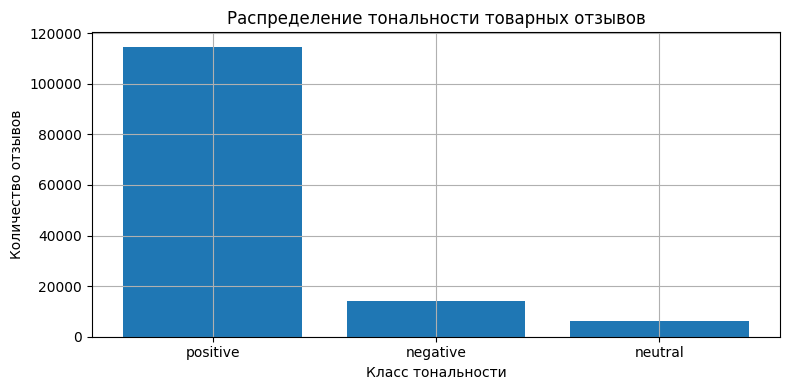

In [75]:
# Итоговый индекс потребительской тональности

if goods_reviews["transformer_sentiment"].notna().sum() > 0:
    goods_reviews["sentiment_index"] = (
        0.4 * goods_reviews["rating_sentiment"] +
        0.2 * goods_reviews["lexical_sentiment"] +
        0.4 * goods_reviews["transformer_sentiment"]
    )
else:
    goods_reviews["sentiment_index"] = (
        0.7 * goods_reviews["rating_sentiment"] +
        0.3 * goods_reviews["lexical_sentiment"]
    )

goods_reviews["sentiment_class"] = np.select(
    [
        goods_reviews["sentiment_index"] > 0.2,
        goods_reviews["sentiment_index"] < -0.2,
    ],
    [
        "positive",
        "negative",
    ],
    default="neutral"
)

display(
    goods_reviews[
        ["rating", "rating_sentiment", "lexical_sentiment", "transformer_sentiment", "sentiment_index", "sentiment_class", "text"]
    ].head(10)
)

sentiment_distribution = (
    goods_reviews["sentiment_class"]
    .value_counts()
    .reset_index()
)

sentiment_distribution.columns = ["sentiment_class", "count"]

display(sentiment_distribution)

plt.figure(figsize=(8, 4))
plt.bar(sentiment_distribution["sentiment_class"], sentiment_distribution["count"])
plt.title("Распределение тональности товарных отзывов")
plt.xlabel("Класс тональности")
plt.ylabel("Количество отзывов")
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
# Анализ отзывов с упоминанием цены

price_reviews = goods_reviews[goods_reviews["has_price_mention"] == 1].copy()

print("Количество отзывов с упоминанием цены:", len(price_reviews))

price_sentiment_summary = pd.DataFrame({
    "metric": [
        "mean_rating_all_goods_reviews",
        "mean_rating_price_reviews",
        "mean_sentiment_all_goods_reviews",
        "mean_sentiment_price_reviews",
        "negative_share_all_goods_reviews",
        "negative_share_price_reviews",
        "positive_share_all_goods_reviews",
        "positive_share_price_reviews",
    ],
    "value": [
        goods_reviews["rating"].mean(),
        price_reviews["rating"].mean(),
        goods_reviews["sentiment_index"].mean(),
        price_reviews["sentiment_index"].mean(),
        (goods_reviews["sentiment_class"] == "negative").mean(),
        (price_reviews["sentiment_class"] == "negative").mean(),
        (goods_reviews["sentiment_class"] == "positive").mean(),
        (price_reviews["sentiment_class"] == "positive").mean(),
    ]
})

display(price_sentiment_summary)

Количество отзывов с упоминанием цены: 37197


,metric,value
0,mean_rating_all_goods_reviews,4.412539
1,mean_rating_price_reviews,4.407049
2,mean_sentiment_all_goods_reviews,0.660244
3,mean_sentiment_price_reviews,0.644950
4,negative_share_all_goods_reviews,0.105556
5,negative_share_price_reviews,0.098906
6,positive_share_all_goods_reviews,0.847803
7,positive_share_price_reviews,0.841466


,rubrics,reviews_count,mean_rating,mean_sentiment,negative_share,positive_share,price_mention_share,mean_text_len
1166,Быстрое питание;Пиццерия,10,2.300000,-0.230000,0.700000,0.300000,0.100000,473.900000
10549,Салон связи;Оператор сотовой связи;Товары для ...,13,2.230769,-0.315385,0.692308,0.230769,0.000000,309.923077
8642,Оператор сотовой связи;Салон связи;Товары для ...,79,2.215190,-0.280380,0.683544,0.291139,0.101266,450.506329
3928,Курьерские услуги;Почтовые услуги,26,2.384615,-0.223077,0.653846,0.346154,0.076923,541.692308
13909,Экспедирование грузов;Грузовые авиаперевозки;А...,11,2.363636,-0.222727,0.636364,0.363636,0.181818,681.000000
205,Автомобильные грузоперевозки;Экспедирование гр...,24,2.416667,-0.281667,0.625000,0.291667,0.166667,701.000000
7553,Магазин электроники;Пункт выдачи,10,2.600000,-0.105000,0.600000,0.400000,0.600000,403.500000
10519,Салон связи;Интернет-провайдер;Оператор сотово...,14,2.714286,-0.071429,0.571429,0.428571,0.071429,416.071429
4044,Логистическая компания;Экспедирование грузов;А...,17,2.764706,-0.123529,0.529412,0.411765,0.235294,494.176471
3921,Курьерские услуги;Грузовые авиаперевозки;Автом...,68,2.882353,-0.013824,0.529412,0.455882,0.132353,434.397059


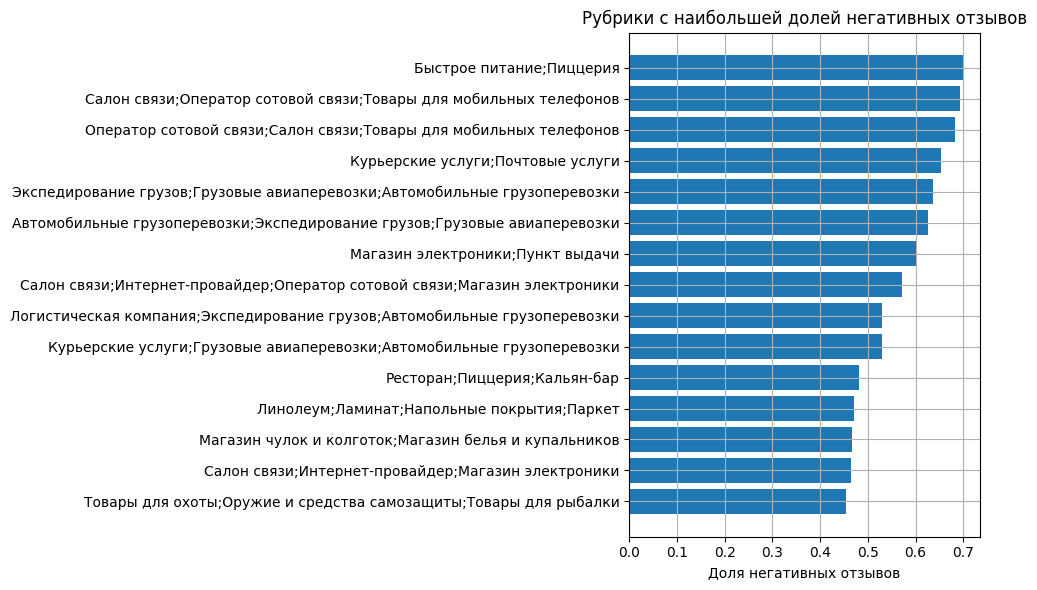

In [77]:
#  Анализ по рубрикам

rubric_stats = (
    goods_reviews
    .groupby("rubrics")
    .agg(
        reviews_count=("text", "count"),
        mean_rating=("rating", "mean"),
        mean_sentiment=("sentiment_index", "mean"),
        negative_share=("sentiment_class", lambda x: (x == "negative").mean()),
        positive_share=("sentiment_class", lambda x: (x == "positive").mean()),
        price_mention_share=("has_price_mention", "mean"),
        mean_text_len=("text_len", "mean"),
    )
    .reset_index()
)

rubric_stats = rubric_stats[rubric_stats["reviews_count"] >= 10].copy()

rubric_stats_sorted = rubric_stats.sort_values("negative_share", ascending=False)

display(rubric_stats_sorted.head(20))

plt.figure(figsize=(10, 6))
top_rubrics = rubric_stats_sorted.head(15).sort_values("negative_share")
plt.barh(top_rubrics["rubrics"], top_rubrics["negative_share"])
plt.title("Рубрики с наибольшей долей негативных отзывов")
plt.xlabel("Доля негативных отзывов")
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
# Агрегация отзывов

has_review_dates = goods_reviews["review_month"].notna().sum() > 0

if has_review_dates:
    monthly_reviews = (
        goods_reviews
        .groupby("review_month")
        .agg(
            review_count=("text", "count"),
            mean_rating=("rating", "mean"),
            mean_sentiment=("sentiment_index", "mean"),
            negative_share=("sentiment_class", lambda x: (x == "negative").mean()),
            positive_share=("sentiment_class", lambda x: (x == "positive").mean()),
            neutral_share=("sentiment_class", lambda x: (x == "neutral").mean()),
            price_mention_share=("has_price_mention", "mean"),
            price_reviews_count=("has_price_mention", "sum"),
            mean_price_review_sentiment=("sentiment_index", lambda x: x[goods_reviews.loc[x.index, "has_price_mention"] == 1].mean()),
        )
        .reset_index()
        .rename(columns={"review_month": "date"})
    )

    monthly_reviews["log_review_count"] = np.log1p(monthly_reviews["review_count"])
    monthly_reviews["consumer_expectations_index"] = (
        monthly_reviews["mean_sentiment"] -
        monthly_reviews["negative_share"] +
        monthly_reviews["positive_share"] -
        monthly_reviews["price_mention_share"] * monthly_reviews["negative_share"]
    )

else:
    annual_review_summary = pd.DataFrame({
        "review_count": [len(goods_reviews)],
        "mean_rating": [goods_reviews["rating"].mean()],
        "mean_sentiment": [goods_reviews["sentiment_index"].mean()],
        "negative_share": [(goods_reviews["sentiment_class"] == "negative").mean()],
        "positive_share": [(goods_reviews["sentiment_class"] == "positive").mean()],
        "neutral_share": [(goods_reviews["sentiment_class"] == "neutral").mean()],
        "price_mention_share": [goods_reviews["has_price_mention"].mean()],
        "price_reviews_count": [goods_reviews["has_price_mention"].sum()],
        "mean_price_review_sentiment": [price_reviews["sentiment_index"].mean()],
    })

    annual_review_summary["log_review_count"] = np.log1p(annual_review_summary["review_count"])
    annual_review_summary["consumer_expectations_index"] = (
        annual_review_summary["mean_sentiment"] -
        annual_review_summary["negative_share"] +
        annual_review_summary["positive_share"] -
        annual_review_summary["price_mention_share"] * annual_review_summary["negative_share"]
    )

    monthly_reviews = pd.DataFrame({
        "date": pd.date_range("2023-01-01", "2023-12-01", freq="MS")
    })

    for col in annual_review_summary.columns:
        monthly_reviews[col] = annual_review_summary.loc[0, col]

    monthly_reviews["review_data_limited"] = 1

print("Есть даты отзывов:", has_review_dates)
display(monthly_reviews.head())
display(monthly_reviews.tail())

Есть даты отзывов: False


,date,review_count,mean_rating,mean_sentiment,negative_share,positive_share,neutral_share,price_mention_share,price_reviews_count,mean_price_review_sentiment,log_review_count,consumer_expectations_index,review_data_limited
0,2023-01-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
1,2023-02-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
2,2023-03-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
3,2023-04-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
4,2023-05-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1


,date,review_count,mean_rating,mean_sentiment,negative_share,positive_share,neutral_share,price_mention_share,price_reviews_count,mean_price_review_sentiment,log_review_count,consumer_expectations_index,review_data_limited
7,2023-08-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
8,2023-09-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
9,2023-10-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
10,2023-11-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1
11,2023-12-01,135141,4.412539,0.660244,0.105556,0.847803,0.04664,0.275246,37197,0.64495,11.814081,1.373437,1


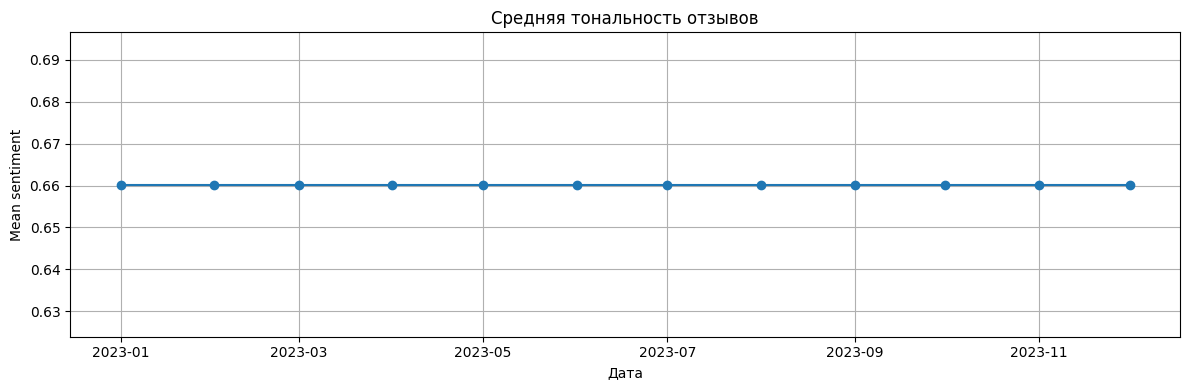

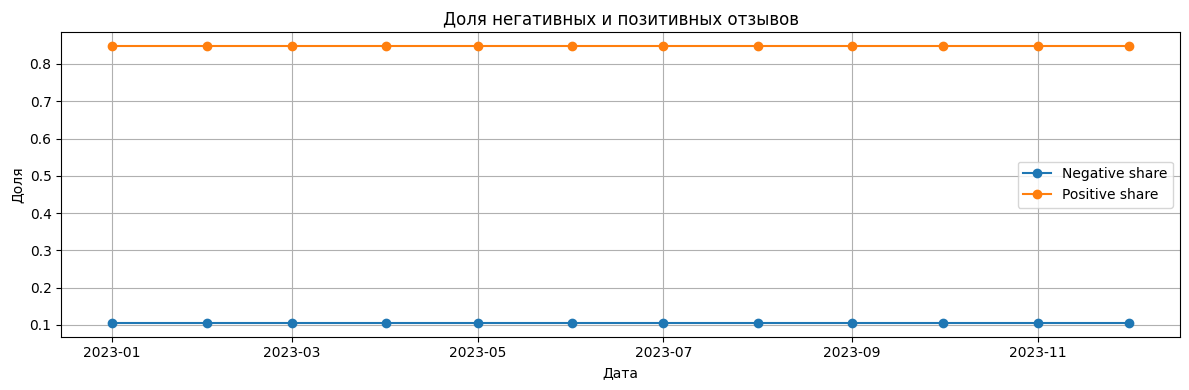

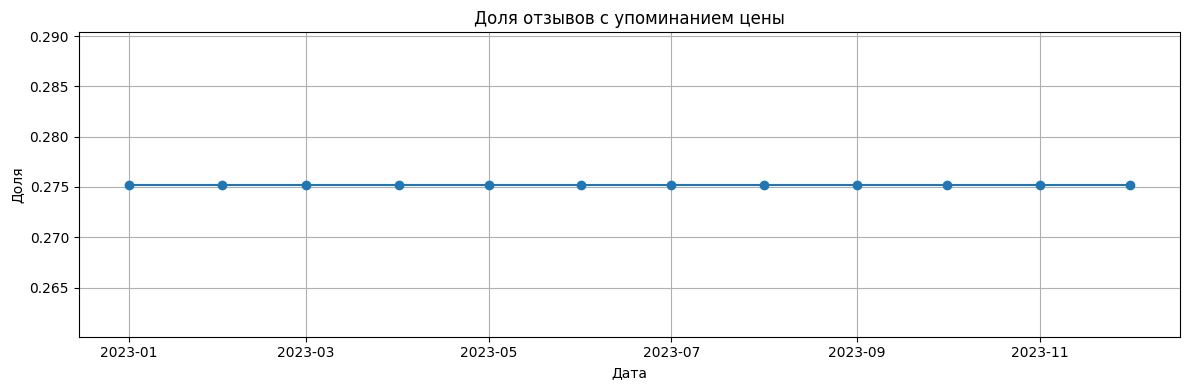

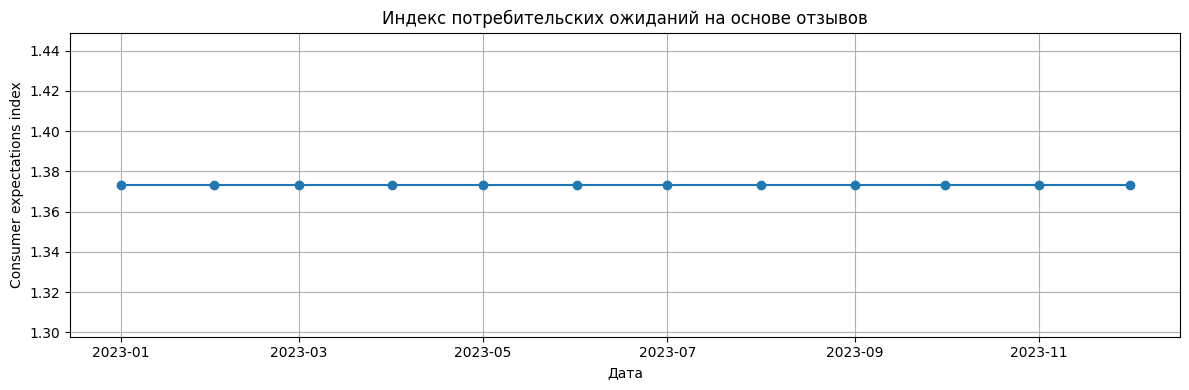

In [79]:
# Графики sentiment-показателей

plt.figure(figsize=(12, 4))
plt.plot(monthly_reviews["date"], monthly_reviews["mean_sentiment"], marker="o")
plt.title("Средняя тональность отзывов")
plt.xlabel("Дата")
plt.ylabel("Mean sentiment")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(monthly_reviews["date"], monthly_reviews["negative_share"], marker="o", label="Negative share")
plt.plot(monthly_reviews["date"], monthly_reviews["positive_share"], marker="o", label="Positive share")
plt.title("Доля негативных и позитивных отзывов")
plt.xlabel("Дата")
plt.ylabel("Доля")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(monthly_reviews["date"], monthly_reviews["price_mention_share"], marker="o")
plt.title("Доля отзывов с упоминанием цены")
plt.xlabel("Дата")
plt.ylabel("Доля")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(monthly_reviews["date"], monthly_reviews["consumer_expectations_index"], marker="o")
plt.title("Индекс потребительских ожиданий на основе отзывов")
plt.xlabel("Дата")
plt.ylabel("Consumer expectations index")
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
# Объединение sentiment-факторов с макроэкономическим датасетом

if "data_model_raw" not in globals():
    raise ValueError("Сначала нужно выполнить код из пункта 2, чтобы появился датафрейм data_model_raw.")

section3_df = data_model_raw.copy()
section3_df = section3_df.sort_values("date").reset_index(drop=True)

section3_df = section3_df.merge(
    monthly_reviews,
    on="date",
    how="left"
)

sentiment_cols = [
    "review_count",
    "mean_rating",
    "mean_sentiment",
    "negative_share",
    "positive_share",
    "neutral_share",
    "price_mention_share",
    "price_reviews_count",
    "mean_price_review_sentiment",
    "log_review_count",
    "consumer_expectations_index",
]

for col in sentiment_cols:
    if col in section3_df.columns:
        section3_df[col] = section3_df[col].fillna(0)

if "review_data_limited" in section3_df.columns:
    section3_df["review_data_limited"] = section3_df["review_data_limited"].fillna(0)
else:
    section3_df["review_data_limited"] = 0

display(section3_df.head())
display(section3_df.tail())

print(section3_df.isna().sum())

,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff,review_count,mean_rating,mean_sentiment,negative_share,positive_share,neutral_share,price_mention_share,price_reviews_count,mean_price_review_sentiment,log_review_count,consumer_expectations_index,review_data_limited
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff,review_count,mean_rating,mean_sentiment,negative_share,positive_share,neutral_share,price_mention_share,price_reviews_count,mean_price_review_sentiment,log_review_count,consumer_expectations_index,review_data_limited
82,2024-11-01,183.864807,1.43,21.0,100.7252,4.48,153.904047,2.694300,5.214201,4.657279,0.0,-12.022081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,2024-12-01,189.307156,1.32,21.0,102.2782,1.55,183.700777,2.959973,5.243371,1.541819,0.0,29.796730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,2025-01-01,191.657261,1.23,21.0,100.7428,NaN,149.831407,1.241424,5.255709,-1.501200,0.0,-33.869370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85,2025-02-01,193.883676,0.81,21.0,92.6708,-8.07,135.095197,1.161665,5.267258,-8.012483,0.0,-14.736210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86,2025-03-01,195.306109,0.65,21.0,86.0096,-6.66,160.408293,0.733653,5.274568,-7.188025,0.0,25.313096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


date                           0
food_cpi                       0
inflation_mom_pct              0
key_rate                       0
usd_rub                        0
usd_change                     8
gpr_index                      0
food_cpi_mom_pct               1
log_food_cpi                   0
usd_rub_pct_change             1
key_rate_diff                  1
gpr_index_diff                 1
review_count                   0
mean_rating                    0
mean_sentiment                 0
negative_share                 0
positive_share                 0
neutral_share                  0
price_mention_share            0
price_reviews_count            0
mean_price_review_sentiment    0
log_review_count               0
consumer_expectations_index    0
review_data_limited            0
dtype: int64


,food_cpi,food_cpi_mom_pct,mean_rating,mean_sentiment,negative_share,positive_share,price_mention_share,mean_price_review_sentiment,consumer_expectations_index,review_count,log_review_count
food_cpi,1.000,0.190,0.321,0.321,0.321,0.321,0.321,0.321,0.321,0.321,0.321
food_cpi_mom_pct,0.190,1.000,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.008
mean_rating,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
mean_sentiment,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
negative_share,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
positive_share,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
price_mention_share,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
mean_price_review_sentiment,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
consumer_expectations_index,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
review_count,0.321,0.008,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


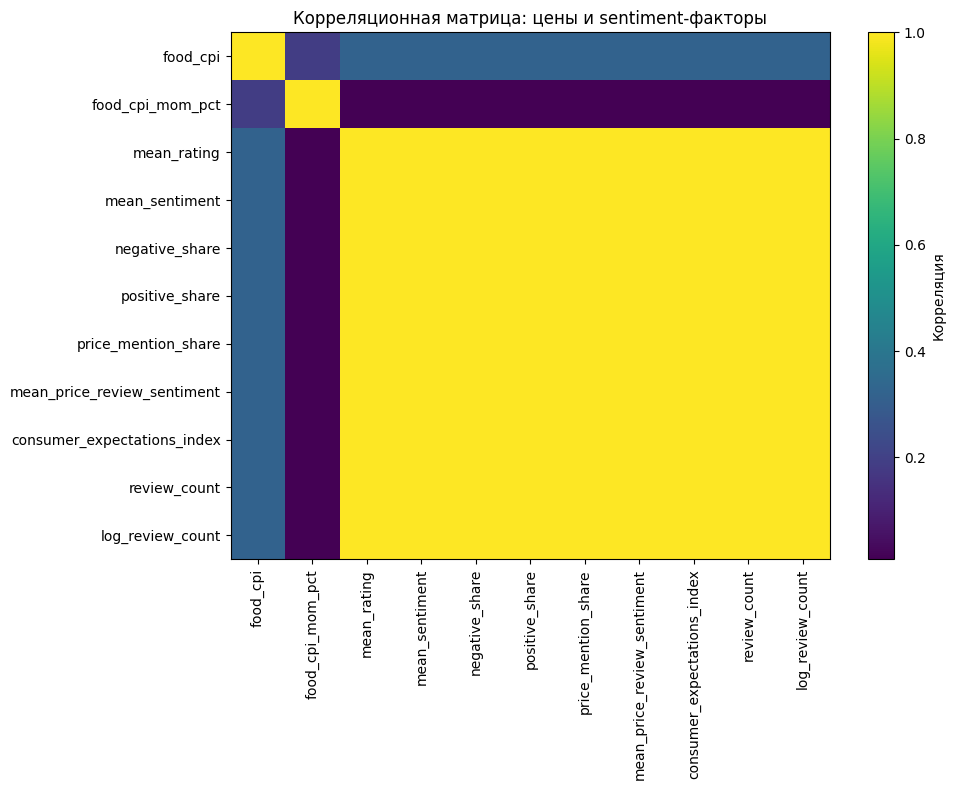

In [81]:
# Корреляция цен и sentiment-факторов

section3_df["food_cpi_mom_pct"] = section3_df["food_cpi"].pct_change() * 100

sentiment_corr_cols = [
    "food_cpi",
    "food_cpi_mom_pct",
    "mean_rating",
    "mean_sentiment",
    "negative_share",
    "positive_share",
    "price_mention_share",
    "mean_price_review_sentiment",
    "consumer_expectations_index",
    "review_count",
    "log_review_count",
]

sentiment_corr_cols = [col for col in sentiment_corr_cols if col in section3_df.columns]

sentiment_corr = section3_df[sentiment_corr_cols].corr()

display(sentiment_corr.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(sentiment_corr, aspect="auto")
plt.colorbar(label="Корреляция")
plt.xticks(range(len(sentiment_corr.columns)), sentiment_corr.columns, rotation=90)
plt.yticks(range(len(sentiment_corr.index)), sentiment_corr.index)
plt.title("Корреляционная матрица: цены и sentiment-факторы")
plt.tight_layout()
plt.show()

In [82]:
# Создание лагов sentiment-факторов

section3_model_df = section3_df.copy()
section3_model_df = section3_model_df.sort_values("date").reset_index(drop=True)

section3_model_df["log_food_cpi"] = np.log(section3_model_df["food_cpi"])
section3_model_df["trend"] = np.arange(len(section3_model_df))
section3_model_df["month"] = section3_model_df["date"].dt.month

for lag in [1, 2, 3, 6, 12]:
    section3_model_df[f"log_food_cpi_lag{lag}"] = section3_model_df["log_food_cpi"].shift(lag)

macro_cols = [
    "inflation_mom_pct",
    "key_rate",
    "usd_rub",
    "gpr_index",
]

for col in macro_cols:
    if col in section3_model_df.columns:
        for lag in [1, 2, 3]:
            section3_model_df[f"{col}_lag{lag}"] = section3_model_df[col].shift(lag)

sentiment_base_cols = [
    "mean_rating",
    "mean_sentiment",
    "negative_share",
    "positive_share",
    "price_mention_share",
    "mean_price_review_sentiment",
    "consumer_expectations_index",
    "log_review_count",
]

for col in sentiment_base_cols:
    if col in section3_model_df.columns:
        for lag in [1, 2, 3]:
            section3_model_df[f"{col}_lag{lag}"] = section3_model_df[col].shift(lag)

section3_model_df["event_covid"] = (
    (section3_model_df["date"] >= "2020-03-01") &
    (section3_model_df["date"] <= "2021-12-01")
).astype(int)

section3_model_df["event_2022_sanctions"] = (
    section3_model_df["date"] >= "2022-02-01"
).astype(int)

if "gpr_index" in section3_model_df.columns:
    gpr_q90 = section3_model_df["gpr_index"].quantile(0.90)
    section3_model_df["event_high_gpr"] = (
        section3_model_df["gpr_index"] >= gpr_q90
    ).astype(int)
else:
    section3_model_df["event_high_gpr"] = 0

section3_model_df = pd.get_dummies(
    section3_model_df,
    columns=["month"],
    prefix="month",
    drop_first=True
)

display(section3_model_df.head())

,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff,review_count,mean_rating,mean_sentiment,negative_share,positive_share,neutral_share,price_mention_share,price_reviews_count,mean_price_review_sentiment,log_review_count,consumer_expectations_index,review_data_limited,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,mean_rating_lag1,mean_rating_lag2,mean_rating_lag3,mean_sentiment_lag1,mean_sentiment_lag2,mean_sentiment_lag3,negative_share_lag1,negative_share_lag2,negative_share_lag3,positive_share_lag1,positive_share_lag2,positive_share_lag3,price_mention_share_lag1,price_mention_share_lag2,price_mention_share_lag3,mean_price_review_sentiment_lag1,mean_price_review_sentiment_lag2,mean_price_review_sentiment_lag3,consumer_expectations_index_lag1,consumer_expectations_index_lag2,consumer_expectations_index_lag3,log_review_count_lag1,log_review_count_lag2,log_review_count_lag3,event_covid,event_2022_sanctions,event_high_gpr,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,False,False,False,False,False,False,False,False,False,False,False
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,4.689174,NaN,NaN,NaN,NaN,0.31,NaN,NaN,7.75,NaN,NaN,56.7418,NaN,NaN,91.679291,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,0,0,True,False,False,False,False,False,False,False,False,False,False
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,4.693166,4.689174,NaN,NaN,NaN,0.21,0.31,NaN,7.50,7.75,NaN,56.8191,56.7418,NaN,71.955023,91.679291,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0,0,0,False,True,False,False,False,False,False,False,False,False,False
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,4.699347,4.693166,4.689174,NaN,NaN,0.29,0.21,0.31,7.25,7.50,7.75,57.0631,56.8191,56.7418,81.680349,71.955023,91.679291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,False,False,True,False,False,False,False,False,False,False,False
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4.704235,4.699347,4.693166,NaN,NaN,0.38,0.29,0.21,7.25,7.25,7.50,60.6202,57.0631,56.8191,94.818215,81.680349,71.955023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,False,False,False,True,False,False,False,False,False,False,False


In [83]:
# Подготовка наборов признаков

target_col = "log_food_cpi"

seasonal_features = [col for col in section3_model_df.columns if col.startswith("month_")]

base_features_s3 = [
    "trend",
    "log_food_cpi_lag1",
    "log_food_cpi_lag2",
    "log_food_cpi_lag3",
    "log_food_cpi_lag6",
    "log_food_cpi_lag12",
] + seasonal_features

macro_features_s3 = base_features_s3 + [
    "inflation_mom_pct_lag1",
    "inflation_mom_pct_lag2",
    "inflation_mom_pct_lag3",
    "key_rate_lag1",
    "key_rate_lag2",
    "key_rate_lag3",
    "usd_rub_lag1",
    "usd_rub_lag2",
    "usd_rub_lag3",
    "gpr_index_lag1",
    "gpr_index_lag2",
    "gpr_index_lag3",
    "event_covid",
    "event_2022_sanctions",
    "event_high_gpr",
]

sentiment_features_s3 = macro_features_s3 + [
    "mean_rating_lag1",
    "mean_rating_lag2",
    "mean_rating_lag3",
    "mean_sentiment_lag1",
    "mean_sentiment_lag2",
    "mean_sentiment_lag3",
    "negative_share_lag1",
    "negative_share_lag2",
    "negative_share_lag3",
    "positive_share_lag1",
    "positive_share_lag2",
    "positive_share_lag3",
    "price_mention_share_lag1",
    "price_mention_share_lag2",
    "price_mention_share_lag3",
    "mean_price_review_sentiment_lag1",
    "mean_price_review_sentiment_lag2",
    "mean_price_review_sentiment_lag3",
    "consumer_expectations_index_lag1",
    "consumer_expectations_index_lag2",
    "consumer_expectations_index_lag3",
    "log_review_count_lag1",
    "log_review_count_lag2",
    "log_review_count_lag3",
]

all_needed_cols = ["date", "food_cpi", target_col] + sentiment_features_s3

section3_model_data = section3_model_df[all_needed_cols].copy()

for col in sentiment_features_s3:
    section3_model_data[col] = pd.to_numeric(section3_model_data[col], errors="coerce")

section3_model_data = section3_model_data.dropna().reset_index(drop=True)

print("Данные для моделей пункта 3:", section3_model_data.shape)
display(section3_model_data.head())
display(section3_model_data.tail())

Данные для моделей пункта 3: (75, 59)


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,mean_rating_lag1,mean_rating_lag2,mean_rating_lag3,mean_sentiment_lag1,mean_sentiment_lag2,mean_sentiment_lag3,negative_share_lag1,negative_share_lag2,negative_share_lag3,positive_share_lag1,positive_share_lag2,positive_share_lag3,price_mention_share_lag1,price_mention_share_lag2,price_mention_share_lag3,mean_price_review_sentiment_lag1,mean_price_review_sentiment_lag2,mean_price_review_sentiment_lag3,consumer_expectations_index_lag1,consumer_expectations_index_lag2,consumer_expectations_index_lag3,log_review_count_lag1,log_review_count_lag2,log_review_count_lag3
0,2019-01-01,115.4584,4.748910,12,4.734711,4.714615,4.702884,4.703017,4.689174,False,False,False,False,False,False,False,False,False,False,False,0.84,0.50,0.35,7.75,7.50,7.50,67.4059,66.2722,65.8870,80.067765,93.762530,81.704646,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-02-01,116.5437,4.758266,13,4.748910,4.734711,4.714615,4.697903,4.693166,True,False,False,False,False,False,False,False,False,False,False,1.01,0.84,0.50,7.75,7.75,7.50,67.2146,67.4059,66.2722,81.690165,80.067765,93.762530,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-03-01,117.2430,4.764249,14,4.758266,4.748910,4.734711,4.696703,4.699347,False,True,False,False,False,False,False,False,False,False,False,0.44,1.01,0.84,7.75,7.75,7.75,65.8795,67.2146,67.4059,85.208330,81.690165,80.067765,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-04-01,117.8057,4.769037,15,4.764249,4.758266,4.748910,4.702884,4.704235,False,False,True,False,False,False,False,False,False,False,False,0.32,0.44,1.01,7.75,7.75,7.75,65.1104,65.8795,67.2146,71.700618,85.208330,81.690165,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-05-01,118.3594,4.773726,16,4.769037,4.764249,4.758266,4.714615,4.703034,False,False,False,True,False,False,False,False,False,False,False,0.29,0.32,0.44,7.75,7.75,7.75,64.6159,65.1104,65.8795,76.895628,71.700618,85.208330,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,mean_rating_lag1,mean_rating_lag2,mean_rating_lag3,mean_sentiment_lag1,mean_sentiment_lag2,mean_sentiment_lag3,negative_share_lag1,negative_share_lag2,negative_share_lag3,positive_share_lag1,positive_share_lag2,positive_share_lag3,price_mention_share_lag1,price_mention_share_lag2,price_mention_share_lag3,mean_price_review_sentiment_lag1,mean_price_review_sentiment_lag2,mean_price_review_sentiment_lag3,consumer_expectations_index_lag1,consumer_expectations_index_lag2,consumer_expectations_index_lag3,log_review_count_lag1,log_review_count_lag2,log_review_count_lag3
70,2024-11-01,183.864807,5.214201,82,5.187614,5.174401,5.171948,5.164552,5.117140,False,False,False,False,False,False,False,False,False,True,False,0.75,0.48,0.20,21.0,19.0,18.0,96.2429,91.3736,89.1666,165.926128,171.101934,177.422943,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71,2024-12-01,189.307156,5.243371,83,5.214201,5.187614,5.174401,5.170544,5.134046,False,False,False,False,False,False,False,False,False,False,True,1.43,0.75,0.48,21.0,21.0,19.0,100.7252,96.2429,91.3736,153.904047,165.926128,171.101934,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,2025-01-01,191.657261,5.255709,84,5.243371,5.214201,5.187614,5.173000,5.148159,False,False,False,False,False,False,False,False,False,False,False,1.32,1.43,0.75,21.0,21.0,21.0,102.2782,100.7252,96.2429,183.700777,153.904047,165.926128,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
73,2025-02-01,193.883676,5.267258,85,5.255709,5.243371,5.214201,5.171948,5.155676,True,False,False,False,False,False,False,False,False,False,False,1.23,1.32,1.43,21.0,21.0,21.0,100.7428,102.2782,100.7252,149.831407,183.700777,153.904047,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74,2025-03-01,195.306109,5.274568,86,5.267258,5.255709,5.243371,5.174401,5.156389,False,True,False,False,False,False,False,False,False,False,False,0.81,1.23,1.32,21.0,21.0,21.0,92.6708,100.7428,102.2782,135.095197,149.831407,183.700777,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
# Train-test split

TEST_MONTHS = 12

test_start_s3 = section3_model_data["date"].max() - pd.DateOffset(months=TEST_MONTHS - 1)

train_s3 = section3_model_data[section3_model_data["date"] < test_start_s3].copy()
test_s3 = section3_model_data[section3_model_data["date"] >= test_start_s3].copy()

print("Начало тестового периода:", test_start_s3.date())
print("Train:", train_s3["date"].min().date(), "-", train_s3["date"].max().date(), "|", train_s3.shape)
print("Test:", test_s3["date"].min().date(), "-", test_s3["date"].max().date(), "|", test_s3.shape)

display(test_s3[["date", "food_cpi"]])

Начало тестового периода: 2024-04-01
Train: 2019-01-01 - 2024-03-01 | (63, 59)
Test: 2024-04-01 - 2025-03-01 | (12, 59)


,date,food_cpi
63,2024-04-01,174.278852
64,2024-05-01,174.959145
65,2024-06-01,176.010508
66,2024-07-01,176.443422
67,2024-08-01,176.257888
68,2024-09-01,176.690802
69,2024-10-01,179.040907
70,2024-11-01,183.864807
71,2024-12-01,189.307156
72,2025-01-01,191.657261


In [85]:
# Метрики качества

def calc_metrics_s3(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2,
    }

In [86]:
# Ridge-модели

def fit_ridge_model_s3(train, test, features, model_name):
    X_train = train[features].astype(float)
    y_train = train[target_col].astype(float)

    X_test = test[features].astype(float)
    y_test_level = test["food_cpi"].astype(float)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_level = np.exp(pred_log)

    metrics = calc_metrics_s3(
        y_true=y_test_level,
        y_pred=pred_level,
        model_name=model_name
    )

    forecast = pd.DataFrame({
        "date": test["date"].values,
        "actual_food_cpi": y_test_level.values,
        f"forecast_{model_name}": pred_level,
    })

    return model, forecast, metrics


ridge_base_s3_model, ridge_base_s3_forecast, ridge_base_s3_metrics = fit_ridge_model_s3(
    train=train_s3,
    test=test_s3,
    features=base_features_s3,
    model_name="Ridge_base"
)

ridge_macro_s3_model, ridge_macro_s3_forecast, ridge_macro_s3_metrics = fit_ridge_model_s3(
    train=train_s3,
    test=test_s3,
    features=macro_features_s3,
    model_name="Ridge_macro"
)

ridge_sentiment_s3_model, ridge_sentiment_s3_forecast, ridge_sentiment_s3_metrics = fit_ridge_model_s3(
    train=train_s3,
    test=test_s3,
    features=sentiment_features_s3,
    model_name="Ridge_macro_sentiment"
)

ridge_metrics_s3 = pd.DataFrame([
    ridge_base_s3_metrics,
    ridge_macro_s3_metrics,
    ridge_sentiment_s3_metrics,
])

display(ridge_metrics_s3.sort_values("MAPE_%"))

,model,MAE,RMSE,MAPE_%,R2
1,Ridge_macro,1.007555,1.300908,0.556560,0.971522
0,Ridge_base,1.686596,2.138753,0.922388,0.923027
2,Ridge_macro_sentiment,3.549128,3.710910,1.957589,0.768272


In [87]:
# Random Forest

def fit_rf_model_s3(train, test, features, model_name):
    X_train = train[features].astype(float)
    y_train = train[target_col].astype(float)

    X_test = test[features].astype(float)
    y_test_level = test["food_cpi"].astype(float)

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred_level = np.exp(pred_log)

    metrics = calc_metrics_s3(
        y_true=y_test_level,
        y_pred=pred_level,
        model_name=model_name
    )

    forecast = pd.DataFrame({
        "date": test["date"].values,
        "actual_food_cpi": y_test_level.values,
        f"forecast_{model_name}": pred_level,
    })

    return model, forecast, metrics


rf_macro_s3_model, rf_macro_s3_forecast, rf_macro_s3_metrics = fit_rf_model_s3(
    train=train_s3,
    test=test_s3,
    features=macro_features_s3,
    model_name="RF_macro"
)

rf_sentiment_s3_model, rf_sentiment_s3_forecast, rf_sentiment_s3_metrics = fit_rf_model_s3(
    train=train_s3,
    test=test_s3,
    features=sentiment_features_s3,
    model_name="RF_macro_sentiment"
)

rf_metrics_s3 = pd.DataFrame([
    rf_macro_s3_metrics,
    rf_sentiment_s3_metrics,
])

display(rf_metrics_s3.sort_values("MAPE_%"))

,model,MAE,RMSE,MAPE_%,R2
0,RF_macro,12.954506,15.239533,6.936427,-2.908051
1,RF_macro_sentiment,12.970697,15.248426,6.945495,-2.912613


,model,MAE,RMSE,MAPE_%,R2
0,Ridge_macro,1.007555,1.300908,0.556560,0.971522
1,Ridge_base,1.686596,2.138753,0.922388,0.923027
2,Ridge_macro_sentiment,3.549128,3.710910,1.957589,0.768272
3,RF_macro,12.954506,15.239533,6.936427,-2.908051
4,RF_macro_sentiment,12.970697,15.248426,6.945495,-2.912613


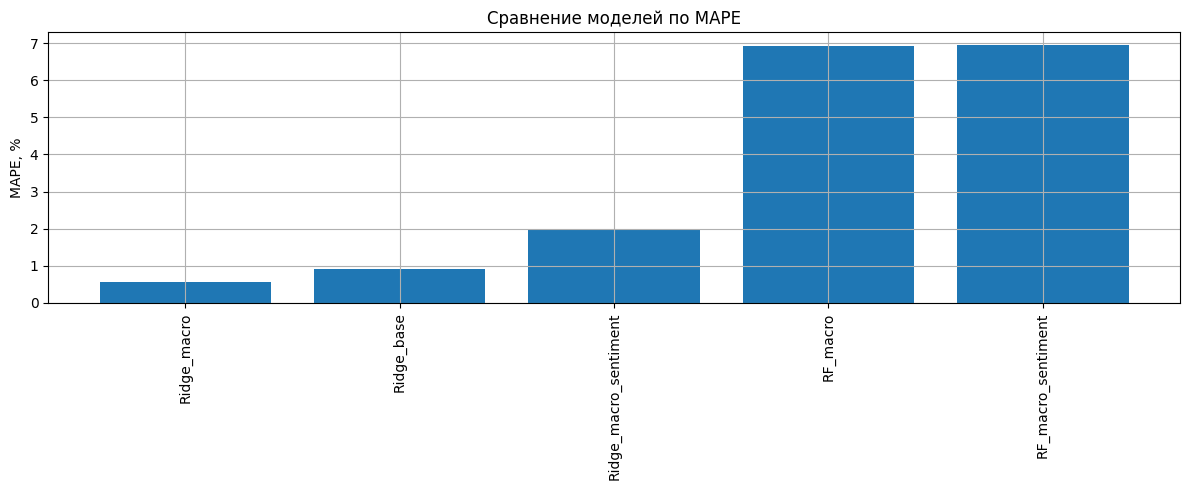

,model,MAE,RMSE,MAPE_%,R2
0,Ridge_macro,1.007555,1.300908,0.556560,0.971522
1,Ridge_base,1.686596,2.138753,0.922388,0.923027
2,Ridge_macro_sentiment,3.549128,3.710910,1.957589,0.768272
3,RF_macro,12.954506,15.239533,6.936427,-2.908051
4,RF_macro_sentiment,12.970697,15.248426,6.945495,-2.912613


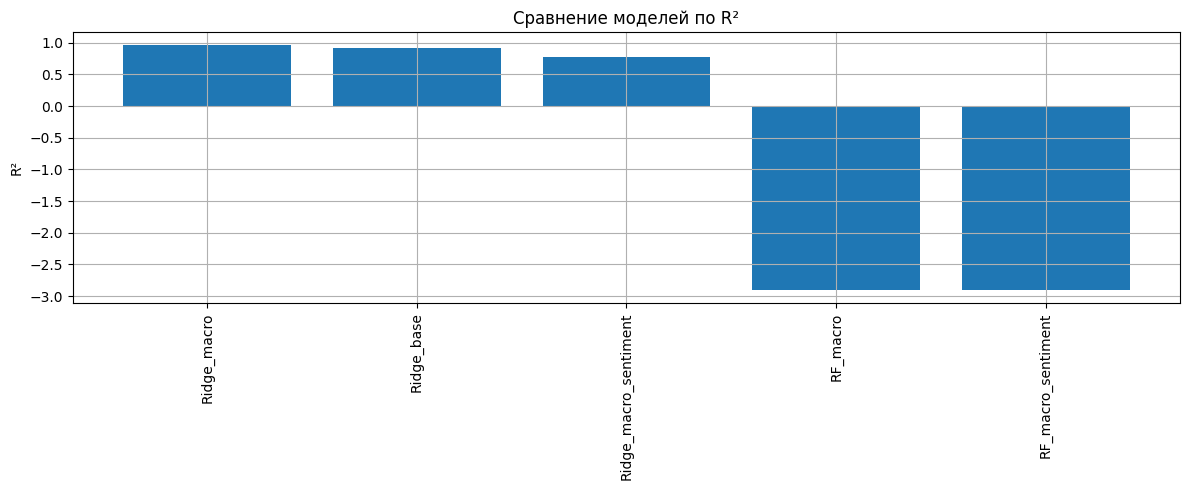

In [88]:
# Общее сравнение моделей

metrics_s3 = pd.DataFrame([
    ridge_base_s3_metrics,
    ridge_macro_s3_metrics,
    ridge_sentiment_s3_metrics,
    rf_macro_s3_metrics,
    rf_sentiment_s3_metrics,
])

metrics_s3 = metrics_s3.sort_values("MAPE_%").reset_index(drop=True)

display(metrics_s3)

plt.figure(figsize=(12, 5))
plt.bar(metrics_s3["model"], metrics_s3["MAPE_%"])
plt.title("Сравнение моделей по MAPE")
plt.ylabel("MAPE, %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

metrics_s3_r2 = metrics_s3.sort_values("R2", ascending=False).reset_index(drop=True)

display(metrics_s3_r2)

plt.figure(figsize=(12, 5))
plt.bar(metrics_s3_r2["model"], metrics_s3_r2["R2"])
plt.title("Сравнение моделей по R²")
plt.ylabel("R²")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [89]:
# Оценка вклада sentiment-факторов

def improvement_pct(base_error, improved_error):
    return (base_error - improved_error) / base_error * 100


sentiment_comparison_rows = []

comparison_pairs = [
    ("Ridge_macro", "Ridge_macro_sentiment"),
    ("RF_macro", "RF_macro_sentiment"),
]

for base_model, sentiment_model in comparison_pairs:
    base_row = metrics_s3[metrics_s3["model"] == base_model]
    sentiment_row = metrics_s3[metrics_s3["model"] == sentiment_model]

    if len(base_row) > 0 and len(sentiment_row) > 0:
        base_mape = base_row["MAPE_%"].values[0]
        sentiment_mape = sentiment_row["MAPE_%"].values[0]

        base_rmse = base_row["RMSE"].values[0]
        sentiment_rmse = sentiment_row["RMSE"].values[0]

        base_r2 = base_row["R2"].values[0]
        sentiment_r2 = sentiment_row["R2"].values[0]

        sentiment_comparison_rows.append({
            "base_model": base_model,
            "sentiment_model": sentiment_model,
            "base_MAPE_%": base_mape,
            "sentiment_MAPE_%": sentiment_mape,
            "MAPE_improvement_%": improvement_pct(base_mape, sentiment_mape),
            "base_RMSE": base_rmse,
            "sentiment_RMSE": sentiment_rmse,
            "RMSE_improvement_%": improvement_pct(base_rmse, sentiment_rmse),
            "base_R2": base_r2,
            "sentiment_R2": sentiment_r2,
            "R2_change": sentiment_r2 - base_r2,
        })

sentiment_improvement_table = pd.DataFrame(sentiment_comparison_rows)

display(sentiment_improvement_table)

,base_model,sentiment_model,base_MAPE_%,sentiment_MAPE_%,MAPE_improvement_%,base_RMSE,sentiment_RMSE,RMSE_improvement_%,base_R2,sentiment_R2,R2_change
0,Ridge_macro,Ridge_macro_sentiment,0.556560,1.957589,-251.730177,1.300908,3.710910,-185.255486,0.971522,0.768272,-0.203250
1,RF_macro,RF_macro_sentiment,6.936427,6.945495,-0.130723,15.239533,15.248426,-0.058355,-2.908051,-2.912613,-0.004562


,date,actual_food_cpi,forecast_Ridge_macro,forecast_Ridge_macro_sentiment,forecast_RF_macro,forecast_RF_macro_sentiment
0,2024-04-01,174.278852,175.498755,178.548952,169.779117,169.673127
1,2024-05-01,174.959145,175.753590,178.948518,169.709660,169.668508
2,2024-06-01,176.010508,175.796016,178.963474,169.680400,169.678420
3,2024-07-01,176.443422,176.956455,179.860511,169.684793,169.665155
4,2024-08-01,176.257888,178.791676,181.528280,169.226257,169.323419
5,2024-09-01,176.690802,177.677695,180.339389,169.019205,169.040128
6,2024-10-01,179.040907,180.419127,183.280084,169.518204,169.509563
7,2024-11-01,183.864807,183.396275,186.637605,169.804035,169.655306
8,2024-12-01,189.307156,186.542083,190.044776,169.487950,169.441730
9,2025-01-01,191.657261,190.882971,194.645899,169.222602,169.231673


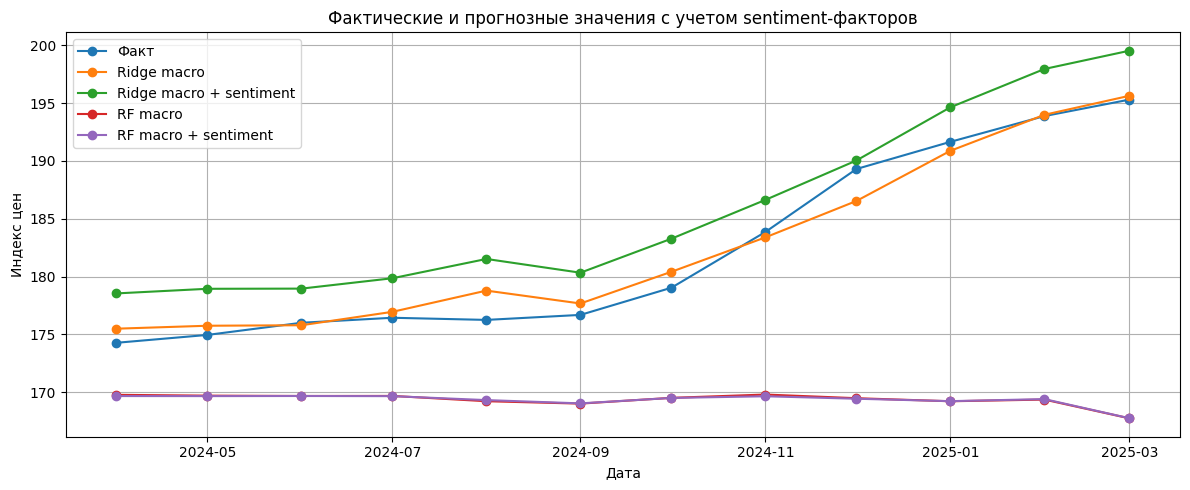

In [90]:
# График факта и прогнозов

forecast_s3 = test_s3[["date", "food_cpi"]].copy()
forecast_s3 = forecast_s3.rename(columns={"food_cpi": "actual_food_cpi"})

forecast_s3 = forecast_s3.merge(
    ridge_macro_s3_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_s3 = forecast_s3.merge(
    ridge_sentiment_s3_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_s3 = forecast_s3.merge(
    rf_macro_s3_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

forecast_s3 = forecast_s3.merge(
    rf_sentiment_s3_forecast,
    on=["date", "actual_food_cpi"],
    how="left"
)

display(forecast_s3)

plt.figure(figsize=(12, 5))
plt.plot(forecast_s3["date"], forecast_s3["actual_food_cpi"], marker="o", label="Факт")
plt.plot(forecast_s3["date"], forecast_s3["forecast_Ridge_macro"], marker="o", label="Ridge macro")
plt.plot(forecast_s3["date"], forecast_s3["forecast_Ridge_macro_sentiment"], marker="o", label="Ridge macro + sentiment")
plt.plot(forecast_s3["date"], forecast_s3["forecast_RF_macro"], marker="o", label="RF macro")
plt.plot(forecast_s3["date"], forecast_s3["forecast_RF_macro_sentiment"], marker="o", label="RF macro + sentiment")

plt.title("Фактические и прогнозные значения с учетом sentiment-факторов")
plt.xlabel("Дата")
plt.ylabel("Индекс цен")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
print("Есть даты отзывов:", has_review_dates)

if not has_review_dates:
    print()
    print("Методологическое ограничение:")
    print(
        "В файле отзывов не найден столбец с датой публикации. "
        "Поэтому sentiment-показатели не формируют полноценный месячный временной ряд. "
        "Результаты моделей с sentiment-факторами следует рассматривать как ограниченную проверку, "
        "а не как строгую оценку причинного влияния отзывов на динамику цен."
    )

print()
print("Лучшие модели по MAPE:")
display(metrics_s3.sort_values("MAPE_%"))

print()
print("Лучшие модели по R²:")
display(metrics_s3.sort_values("R2", ascending=False))

print()
print("Оценка вклада sentiment-факторов:")
display(sentiment_improvement_table)

for _, row in sentiment_improvement_table.iterrows():
    print("\n" + "-" * 80)
    print(f"Сравнение: {row['base_model']} -> {row['sentiment_model']}")

    if row["MAPE_improvement_%"] > 0:
        print(
            f"Добавление sentiment-факторов снизило MAPE с {row['base_MAPE_%']:.2f}% "
            f"до {row['sentiment_MAPE_%']:.2f}%. "
            f"Относительное улучшение составило {row['MAPE_improvement_%']:.2f}%."
        )
    else:
        print(
            f"Добавление sentiment-факторов не снизило MAPE: показатель изменился "
            f"с {row['base_MAPE_%']:.2f}% до {row['sentiment_MAPE_%']:.2f}%."
        )

    if row["R2_change"] > 0:
        print(
            f"R² увеличился с {row['base_R2']:.3f} до {row['sentiment_R2']:.3f}. "
            f"Это говорит о росте объясняющей способности модели на тестовом периоде."
        )
    else:
        print(
            f"R² не улучшился: показатель изменился с {row['base_R2']:.3f} "
            f"до {row['sentiment_R2']:.3f}."
        )

Есть даты отзывов: False

Методологическое ограничение:
В файле отзывов не найден столбец с датой публикации. Поэтому sentiment-показатели не формируют полноценный месячный временной ряд. Результаты моделей с sentiment-факторами следует рассматривать как ограниченную проверку, а не как строгую оценку причинного влияния отзывов на динамику цен.

Лучшие модели по MAPE:


,model,MAE,RMSE,MAPE_%,R2
0,Ridge_macro,1.007555,1.300908,0.556560,0.971522
1,Ridge_base,1.686596,2.138753,0.922388,0.923027
2,Ridge_macro_sentiment,3.549128,3.710910,1.957589,0.768272
3,RF_macro,12.954506,15.239533,6.936427,-2.908051
4,RF_macro_sentiment,12.970697,15.248426,6.945495,-2.912613



Лучшие модели по R²:


,model,MAE,RMSE,MAPE_%,R2
0,Ridge_macro,1.007555,1.300908,0.556560,0.971522
1,Ridge_base,1.686596,2.138753,0.922388,0.923027
2,Ridge_macro_sentiment,3.549128,3.710910,1.957589,0.768272
3,RF_macro,12.954506,15.239533,6.936427,-2.908051
4,RF_macro_sentiment,12.970697,15.248426,6.945495,-2.912613



Оценка вклада sentiment-факторов:


,base_model,sentiment_model,base_MAPE_%,sentiment_MAPE_%,MAPE_improvement_%,base_RMSE,sentiment_RMSE,RMSE_improvement_%,base_R2,sentiment_R2,R2_change
0,Ridge_macro,Ridge_macro_sentiment,0.556560,1.957589,-251.730177,1.300908,3.710910,-185.255486,0.971522,0.768272,-0.203250
1,RF_macro,RF_macro_sentiment,6.936427,6.945495,-0.130723,15.239533,15.248426,-0.058355,-2.908051,-2.912613,-0.004562



--------------------------------------------------------------------------------
Сравнение: Ridge_macro -> Ridge_macro_sentiment
Добавление sentiment-факторов не снизило MAPE: показатель изменился с 0.56% до 1.96%.
R² не улучшился: показатель изменился с 0.972 до 0.768.

--------------------------------------------------------------------------------
Сравнение: RF_macro -> RF_macro_sentiment
Добавление sentiment-факторов не снизило MAPE: показатель изменился с 6.94% до 6.95%.
R² не улучшился: показатель изменился с -2.908 до -2.913.


In [92]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [93]:
ml_df = data_model_raw.copy()
print("Используется data_model_raw: цены + макрофакторы")

ml_df = ml_df.sort_values("date").reset_index(drop=True)

display(ml_df.head())
display(ml_df.tail())

Используется data_model_raw: цены + макрофакторы


,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411


,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff
82,2024-11-01,183.864807,1.43,21.0,100.7252,4.48,153.904047,2.694300,5.214201,4.657279,0.0,-12.022081
83,2024-12-01,189.307156,1.32,21.0,102.2782,1.55,183.700777,2.959973,5.243371,1.541819,0.0,29.796730
84,2025-01-01,191.657261,1.23,21.0,100.7428,NaN,149.831407,1.241424,5.255709,-1.501200,0.0,-33.869370
85,2025-02-01,193.883676,0.81,21.0,92.6708,-8.07,135.095197,1.161665,5.267258,-8.012483,0.0,-14.736210
86,2025-03-01,195.306109,0.65,21.0,86.0096,-6.66,160.408293,0.733653,5.274568,-7.188025,0.0,25.313096


In [94]:
# Feature engineering

ml_df["log_food_cpi"] = np.log(ml_df["food_cpi"])
ml_df["trend"] = np.arange(len(ml_df))
ml_df["month"] = ml_df["date"].dt.month

for lag in [1, 2, 3, 6, 12]:
    ml_df[f"log_food_cpi_lag{lag}"] = ml_df["log_food_cpi"].shift(lag)

macro_cols = [
    "inflation_mom_pct",
    "key_rate",
    "usd_rub",
    "gpr_index",
]

for col in macro_cols:
    if col in ml_df.columns:
        for lag in [1, 2, 3]:
            ml_df[f"{col}_lag{lag}"] = ml_df[col].shift(lag)

sentiment_cols = [
    "mean_rating",
    "mean_sentiment",
    "negative_share",
    "positive_share",
    "price_mention_share",
    "consumer_expectations_index",
    "log_review_count",
]

for col in sentiment_cols:
    if col in ml_df.columns:
        for lag in [1, 2, 3]:
            ml_df[f"{col}_lag{lag}"] = ml_df[col].shift(lag)

ml_df["event_covid"] = (
    (ml_df["date"] >= "2020-03-01") &
    (ml_df["date"] <= "2021-12-01")
).astype(int)

ml_df["event_2022_sanctions"] = (
    ml_df["date"] >= "2022-02-01"
).astype(int)

if "gpr_index" in ml_df.columns:
    gpr_q90 = ml_df["gpr_index"].quantile(0.90)
    ml_df["event_high_gpr"] = (ml_df["gpr_index"] >= gpr_q90).astype(int)
else:
    ml_df["event_high_gpr"] = 0

ml_df = pd.get_dummies(
    ml_df,
    columns=["month"],
    prefix="month",
    drop_first=True
)

display(ml_df.head())

,date,food_cpi,inflation_mom_pct,key_rate,usd_rub,usd_change,gpr_index,food_cpi_mom_pct,log_food_cpi,usd_rub_pct_change,key_rate_diff,gpr_index_diff,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2018-01-01,108.7633,0.31,7.75,56.7418,NaN,91.679291,NaN,4.689174,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,False,False,False,False,False,False,False,False,False,False,False
1,2018-02-01,109.1984,0.21,7.50,56.8191,0.08,71.955023,0.400043,4.693166,0.136231,-0.25,-19.724268,1,4.689174,NaN,NaN,NaN,NaN,0.31,NaN,NaN,7.75,NaN,NaN,56.7418,NaN,NaN,91.679291,NaN,NaN,0,0,0,True,False,False,False,False,False,False,False,False,False,False
2,2018-03-01,109.8754,0.29,7.25,57.0631,0.24,81.680349,0.619972,4.699347,0.429433,-0.25,9.725326,2,4.693166,4.689174,NaN,NaN,NaN,0.21,0.31,NaN,7.50,7.75,NaN,56.8191,56.7418,NaN,71.955023,91.679291,NaN,0,0,0,False,True,False,False,False,False,False,False,False,False,False
3,2018-04-01,110.4138,0.38,7.25,60.6202,3.56,94.818215,0.490010,4.704235,6.233626,0.00,13.137866,3,4.699347,4.693166,4.689174,NaN,NaN,0.29,0.21,0.31,7.25,7.50,7.75,57.0631,56.8191,56.7418,81.680349,71.955023,91.679291,0,0,0,False,False,True,False,False,False,False,False,False,False,False
4,2018-05-01,110.2813,0.38,7.25,62.2096,1.59,80.864804,-0.120003,4.703034,2.621898,0.00,-13.953411,4,4.704235,4.699347,4.693166,NaN,NaN,0.38,0.29,0.21,7.25,7.25,7.50,60.6202,57.0631,56.8191,94.818215,81.680349,71.955023,0,0,0,False,False,False,True,False,False,False,False,False,False,False


In [95]:
# Подготовка признаков

target_col = "log_food_cpi"

base_features = [
    "trend",
    "log_food_cpi_lag1",
    "log_food_cpi_lag2",
    "log_food_cpi_lag3",
    "log_food_cpi_lag6",
    "log_food_cpi_lag12",
]

seasonal_features = [col for col in ml_df.columns if col.startswith("month_")]

macro_features = [
    "inflation_mom_pct_lag1",
    "inflation_mom_pct_lag2",
    "inflation_mom_pct_lag3",
    "key_rate_lag1",
    "key_rate_lag2",
    "key_rate_lag3",
    "usd_rub_lag1",
    "usd_rub_lag2",
    "usd_rub_lag3",
    "gpr_index_lag1",
    "gpr_index_lag2",
    "gpr_index_lag3",
    "event_covid",
    "event_2022_sanctions",
    "event_high_gpr",
]

sentiment_features = [
    col for col in ml_df.columns
    if any(x in col for x in [
        "mean_rating_lag",
        "mean_sentiment_lag",
        "negative_share_lag",
        "positive_share_lag",
        "price_mention_share_lag",
        "consumer_expectations_index_lag",
        "log_review_count_lag",
    ])
]

all_features = base_features + seasonal_features + macro_features + sentiment_features
available_features = [col for col in all_features if col in ml_df.columns]

model_data_ml = ml_df[["date", "food_cpi", target_col] + available_features].copy()

for col in available_features:
    model_data_ml[col] = pd.to_numeric(model_data_ml[col], errors="coerce")

model_data_ml = model_data_ml.dropna().reset_index(drop=True)

print("Размер данных для ML:", model_data_ml.shape)
print("Количество признаков:", len(available_features))

display(model_data_ml.head())
display(model_data_ml.tail())

Размер данных для ML: (75, 35)
Количество признаков: 32


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr
0,2019-01-01,115.4584,4.748910,12,4.734711,4.714615,4.702884,4.703017,4.689174,False,False,False,False,False,False,False,False,False,False,False,0.84,0.50,0.35,7.75,7.50,7.50,67.4059,66.2722,65.8870,80.067765,93.762530,81.704646,0,0,0
1,2019-02-01,116.5437,4.758266,13,4.748910,4.734711,4.714615,4.697903,4.693166,True,False,False,False,False,False,False,False,False,False,False,1.01,0.84,0.50,7.75,7.75,7.50,67.2146,67.4059,66.2722,81.690165,80.067765,93.762530,0,0,0
2,2019-03-01,117.2430,4.764249,14,4.758266,4.748910,4.734711,4.696703,4.699347,False,True,False,False,False,False,False,False,False,False,False,0.44,1.01,0.84,7.75,7.75,7.75,65.8795,67.2146,67.4059,85.208330,81.690165,80.067765,0,0,0
3,2019-04-01,117.8057,4.769037,15,4.764249,4.758266,4.748910,4.702884,4.704235,False,False,True,False,False,False,False,False,False,False,False,0.32,0.44,1.01,7.75,7.75,7.75,65.1104,65.8795,67.2146,71.700618,85.208330,81.690165,0,0,0
4,2019-05-01,118.3594,4.773726,16,4.769037,4.764249,4.758266,4.714615,4.703034,False,False,False,True,False,False,False,False,False,False,False,0.29,0.32,0.44,7.75,7.75,7.75,64.6159,65.1104,65.8795,76.895628,71.700618,85.208330,0,0,0


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr
70,2024-11-01,183.864807,5.214201,82,5.187614,5.174401,5.171948,5.164552,5.117140,False,False,False,False,False,False,False,False,False,True,False,0.75,0.48,0.20,21.0,19.0,18.0,96.2429,91.3736,89.1666,165.926128,171.101934,177.422943,0,1,0
71,2024-12-01,189.307156,5.243371,83,5.214201,5.187614,5.174401,5.170544,5.134046,False,False,False,False,False,False,False,False,False,False,True,1.43,0.75,0.48,21.0,21.0,19.0,100.7252,96.2429,91.3736,153.904047,165.926128,171.101934,0,1,0
72,2025-01-01,191.657261,5.255709,84,5.243371,5.214201,5.187614,5.173000,5.148159,False,False,False,False,False,False,False,False,False,False,False,1.32,1.43,0.75,21.0,21.0,21.0,102.2782,100.7252,96.2429,183.700777,153.904047,165.926128,0,1,0
73,2025-02-01,193.883676,5.267258,85,5.255709,5.243371,5.214201,5.171948,5.155676,True,False,False,False,False,False,False,False,False,False,False,1.23,1.32,1.43,21.0,21.0,21.0,100.7428,102.2782,100.7252,149.831407,183.700777,153.904047,0,1,0
74,2025-03-01,195.306109,5.274568,86,5.267258,5.255709,5.243371,5.174401,5.156389,False,True,False,False,False,False,False,False,False,False,False,0.81,1.23,1.32,21.0,21.0,21.0,92.6708,100.7428,102.2782,135.095197,149.831407,183.700777,0,1,0


In [96]:
# Train-test split

TEST_MONTHS = 12

test_start = model_data_ml["date"].max() - pd.DateOffset(months=TEST_MONTHS - 1)

train_ml = model_data_ml[model_data_ml["date"] < test_start].copy()
test_ml = model_data_ml[model_data_ml["date"] >= test_start].copy()

X_train = train_ml[available_features]
y_train = train_ml[target_col]

X_test = test_ml[available_features]
y_test_log = test_ml[target_col]
y_test = test_ml["food_cpi"]

print("Train:", train_ml["date"].min().date(), "-", train_ml["date"].max().date(), train_ml.shape)
print("Test:", test_ml["date"].min().date(), "-", test_ml["date"].max().date(), test_ml.shape)

Train: 2019-01-01 - 2024-03-01 (63, 35)
Test: 2024-04-01 - 2025-03-01 (12, 35)


In [97]:
def calc_ml_metrics(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }

In [98]:
# Классические модели машинного обучения

classical_models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=3,
        random_state=SEED
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=3,
        random_state=SEED
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=SEED
    ),

}


def fit_classical_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred = np.exp(pred_log)

    metrics = calc_ml_metrics(y_test, pred, model_name)

    forecast = pd.DataFrame({
        "date": test_ml["date"].values,
        "actual_food_cpi": y_test.values,
        f"forecast_{model_name}": pred,
    })

    return model, forecast, metrics

In [99]:
# Функции для LSTM и GRU

SEQUENCE_LENGTH = 6


def make_sequences(X, y, dates, prices, sequence_length):
    X_seq = []
    y_seq = []
    dates_seq = []
    prices_seq = []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y[i])
        dates_seq.append(dates.iloc[i])
        prices_seq.append(prices.iloc[i])

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(dates_seq),
        np.array(prices_seq)
    )


def build_recurrent_model(model_type, sequence_length, n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = Sequential()

    if model_type == "LSTM":
        model.add(LSTM(
            32,
            input_shape=(sequence_length, n_features)
        ))
    elif model_type == "GRU":
        model.add(GRU(
            32,
            input_shape=(sequence_length, n_features)
        ))
    else:
        raise ValueError("model_type должен быть LSTM или GRU")

    model.add(Dropout(0.2))
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


def fit_recurrent_model(
    full_df,
    features,
    target_col,
    test_start,
    model_type,
    sequence_length=6,
    epochs=300,
    batch_size=8,
    verbose=0
):
    full_df = full_df.sort_values("date").reset_index(drop=True).copy()

    train_part = full_df[full_df["date"] < test_start].copy()

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_x.fit(train_part[features])
    scaler_y.fit(train_part[[target_col]])

    X_scaled = scaler_x.transform(full_df[features])
    y_scaled = scaler_y.transform(full_df[[target_col]]).ravel()

    X_seq, y_seq, dates_seq, prices_seq = make_sequences(
        X_scaled,
        y_scaled,
        full_df["date"],
        full_df["food_cpi"],
        sequence_length
    )

    train_mask = dates_seq < test_start
    test_mask = dates_seq >= test_start

    X_train_seq = X_seq[train_mask]
    y_train_seq = y_seq[train_mask]

    X_test_seq = X_seq[test_mask]
    y_test_level = prices_seq[test_mask]
    dates_test = dates_seq[test_mask]

    if len(X_train_seq) < 10 or len(X_test_seq) == 0:
        empty_metrics = {
            "model": model_type,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE_%": np.nan,
            "R2": np.nan,
        }

        empty_forecast = pd.DataFrame(columns=[
            "date",
            "actual_food_cpi",
            f"forecast_{model_type}"
        ])

        return None, empty_forecast, empty_metrics, None

    model = build_recurrent_model(
        model_type=model_type,
        sequence_length=sequence_length,
        n_features=X_train_seq.shape[2]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        shuffle=False,
        callbacks=[early_stop],
        verbose=verbose
    )

    pred_scaled = model.predict(X_test_seq, verbose=0)
    pred_log = scaler_y.inverse_transform(pred_scaled).ravel()
    pred = np.exp(pred_log)

    metrics = calc_ml_metrics(
        y_true=y_test_level,
        y_pred=pred,
        model_name=model_type
    )

    forecast = pd.DataFrame({
        "date": dates_test,
        "actual_food_cpi": y_test_level,
        f"forecast_{model_type}": pred,
    })

    return model, forecast, metrics, history

In [100]:
# Обучение всех моделей

trained_models = {}
forecasts = []
metrics = []

for model_name, model in classical_models.items():
    fitted_model, forecast, metric = fit_classical_model(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    trained_models[model_name] = fitted_model
    forecasts.append(forecast)
    metrics.append(metric)


lstm_model, lstm_forecast, lstm_metrics, lstm_history = fit_recurrent_model(
    full_df=model_data_ml,
    features=available_features,
    target_col=target_col,
    test_start=test_start,
    model_type="LSTM",
    sequence_length=SEQUENCE_LENGTH
)

gru_model, gru_forecast, gru_metrics, gru_history = fit_recurrent_model(
    full_df=model_data_ml,
    features=available_features,
    target_col=target_col,
    test_start=test_start,
    model_type="GRU",
    sequence_length=SEQUENCE_LENGTH
)

trained_models["LSTM"] = lstm_model
trained_models["GRU"] = gru_model

forecasts.extend([lstm_forecast, gru_forecast])
metrics.extend([lstm_metrics, gru_metrics])

metrics_ml = pd.DataFrame(metrics).sort_values("MAPE_%").reset_index(drop=True)

display(metrics_ml)

,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,0.580698,0.808949,0.313722,0.988988
1,Ridge,1.007555,1.300908,0.556560,0.971522
2,LSTM,4.444943,5.269781,2.388295,0.532693
3,GRU,9.117512,9.908297,4.932079,-0.652018
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065
5,DecisionTree,11.202595,13.598714,5.980595,-2.111807
6,RandomForest,12.954506,15.239533,6.936427,-2.908051


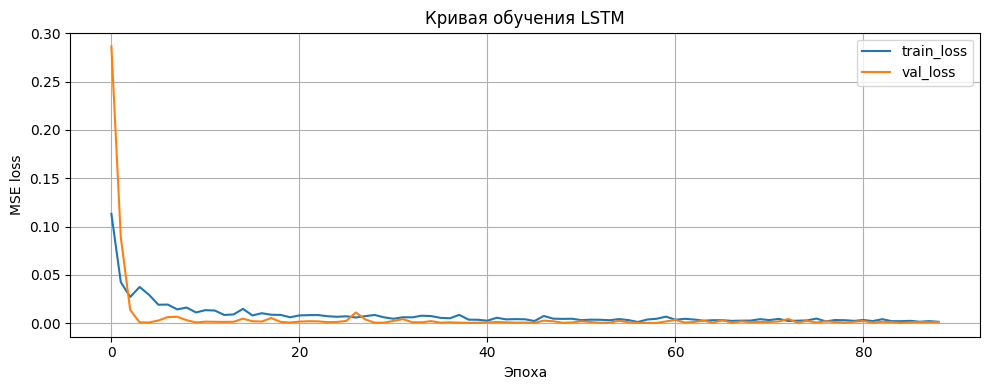

,loss,mae,val_loss,val_mae
84,0.002108,0.035185,0.000391,0.015216
85,0.002452,0.034574,0.000981,0.026450
86,0.001506,0.031313,0.001163,0.029349
87,0.002141,0.033747,0.000992,0.026689
88,0.001481,0.030606,0.001185,0.029926


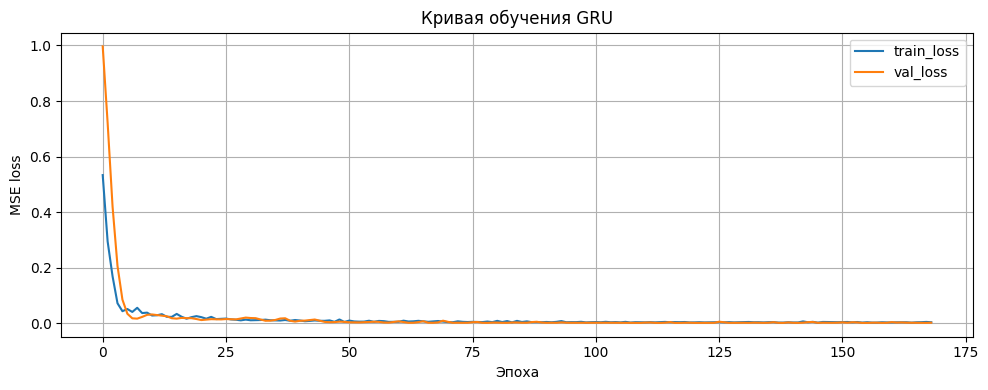

,loss,mae,val_loss,val_mae
164,0.001838,0.032540,0.001529,0.035842
165,0.003109,0.038275,0.001158,0.029567
166,0.003473,0.042696,0.001201,0.026399
167,0.004412,0.044497,0.001017,0.026407
168,0.003192,0.036100,0.001653,0.037131


In [101]:
# Кривые обучения LSTM и GRU

def plot_training_history(history, title):
    if history is None:
        print(f"История обучения для {title} отсутствует")
        return

    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(10, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Эпоха")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    display(hist.tail())


plot_training_history(lstm_history, "Кривая обучения LSTM")
plot_training_history(gru_history, "Кривая обучения GRU")

,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,0.580698,0.808949,0.313722,0.988988
1,Ridge,1.007555,1.300908,0.556560,0.971522
2,LSTM,4.444943,5.269781,2.388295,0.532693
3,GRU,9.117512,9.908297,4.932079,-0.652018
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065
5,DecisionTree,11.202595,13.598714,5.980595,-2.111807
6,RandomForest,12.954506,15.239533,6.936427,-2.908051


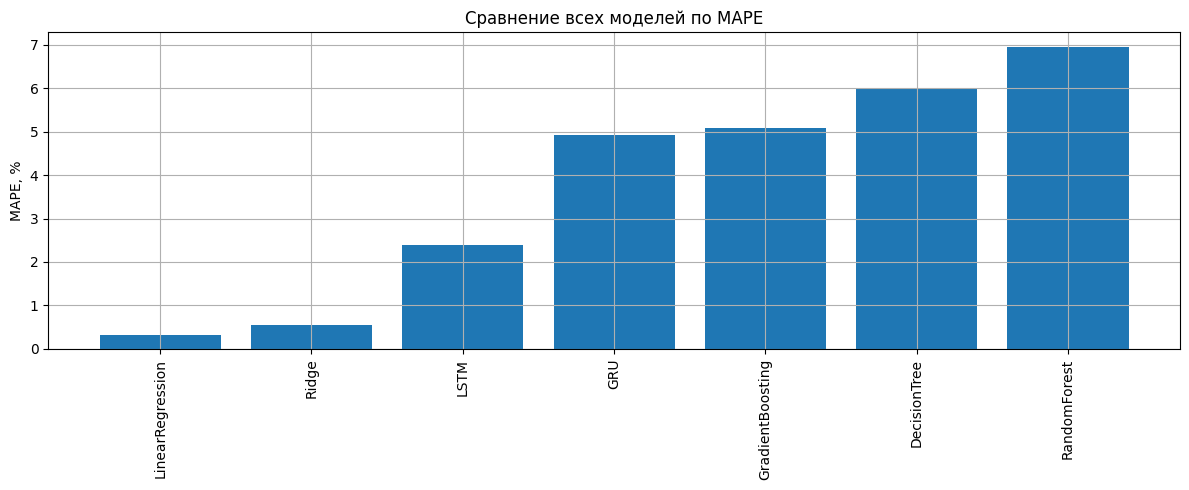

,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,0.580698,0.808949,0.313722,0.988988
1,Ridge,1.007555,1.300908,0.556560,0.971522
2,LSTM,4.444943,5.269781,2.388295,0.532693
3,GRU,9.117512,9.908297,4.932079,-0.652018
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065
5,DecisionTree,11.202595,13.598714,5.980595,-2.111807
6,RandomForest,12.954506,15.239533,6.936427,-2.908051


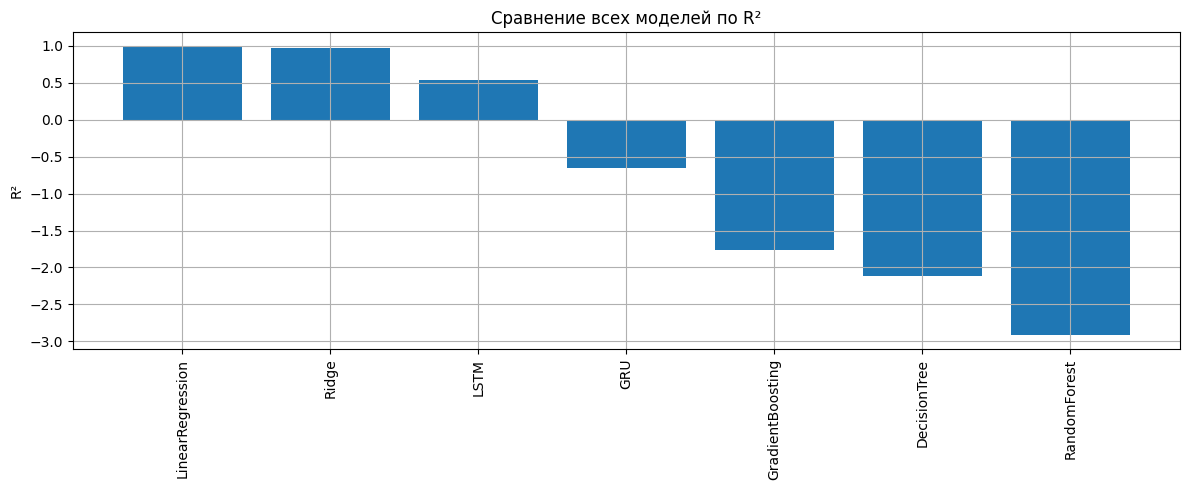

In [102]:
# Сравнение моделей по MAPE и R2

display(metrics_ml.sort_values("MAPE_%"))

plt.figure(figsize=(12, 5))
plt.bar(metrics_ml["model"], metrics_ml["MAPE_%"])
plt.title("Сравнение всех моделей по MAPE")
plt.ylabel("MAPE, %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


metrics_ml_r2 = metrics_ml.sort_values("R2", ascending=False).reset_index(drop=True)

display(metrics_ml_r2)

plt.figure(figsize=(12, 5))
plt.bar(metrics_ml_r2["model"], metrics_ml_r2["R2"])
plt.title("Сравнение всех моделей по R²")
plt.ylabel("R²")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

,date,actual_food_cpi,forecast_LinearRegression,forecast_Ridge,forecast_DecisionTree,forecast_RandomForest,forecast_GradientBoosting,forecast_LSTM,forecast_GRU
0,2024-04-01,174.278852,174.580542,175.498755,171.105783,169.779117,173.362951,179.485947,178.940308
1,2024-05-01,174.959145,174.863006,175.753590,171.105783,169.709660,172.734467,177.982193,172.056488
2,2024-06-01,176.010508,174.933331,175.796016,171.105783,169.680400,173.248238,177.886154,171.836197
3,2024-07-01,176.443422,176.052387,176.956455,171.105783,169.684793,173.234988,174.244675,167.300247
4,2024-08-01,176.257888,176.322045,178.791676,171.105783,169.226257,173.364267,175.664474,166.973175
5,2024-09-01,176.690802,177.412199,177.677695,171.105783,169.019205,173.232851,175.631958,169.495987
6,2024-10-01,179.040907,178.999641,180.419127,171.105783,169.518204,172.796761,175.845993,172.487411
7,2024-11-01,183.864807,183.553318,183.396275,171.105783,169.804035,173.131753,179.729584,173.031525
8,2024-12-01,189.307156,187.449387,186.542083,171.105783,169.487950,173.201029,179.941986,175.315598
9,2025-01-01,191.657261,191.576493,190.882971,171.105783,169.222602,173.324097,184.601456,177.455948


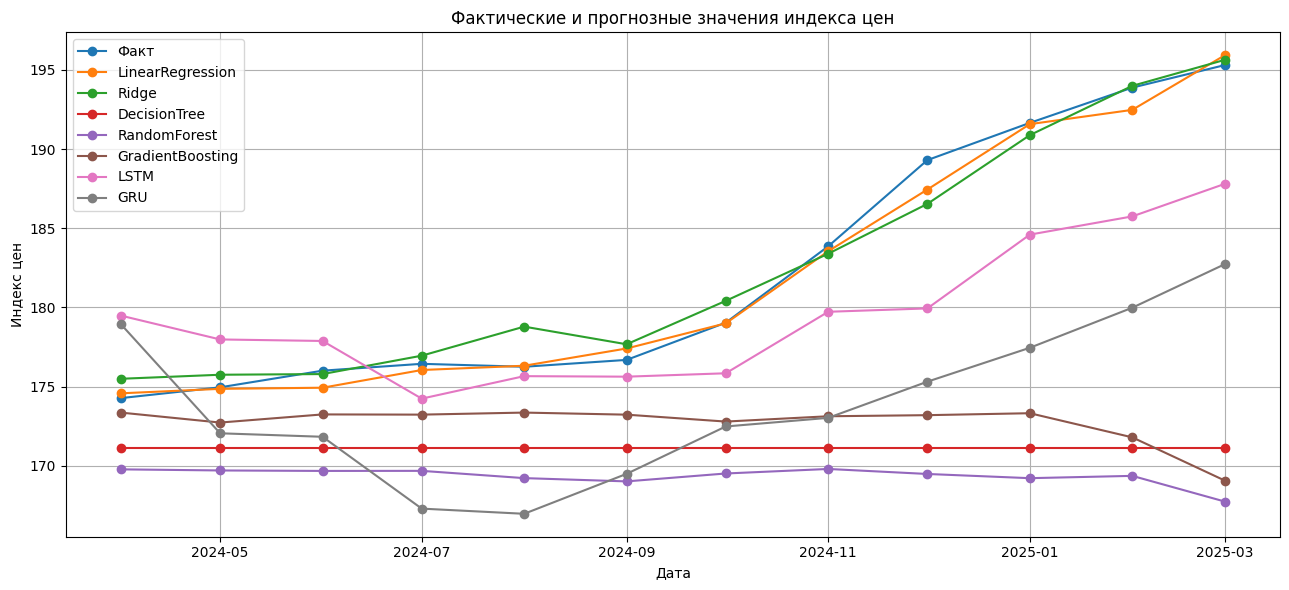

In [103]:
# График фактических и прогнозных значений

forecast_all = test_ml[["date", "food_cpi"]].copy()
forecast_all = forecast_all.rename(columns={"food_cpi": "actual_food_cpi"})

for forecast in forecasts:
    if forecast is not None and len(forecast) > 0:
        forecast_all = forecast_all.merge(
            forecast,
            on=["date", "actual_food_cpi"],
            how="left"
        )

display(forecast_all)

plt.figure(figsize=(13, 6))
plt.plot(
    forecast_all["date"],
    forecast_all["actual_food_cpi"],
    marker="o",
    label="Факт"
)

for col in forecast_all.columns:
    if col.startswith("forecast_"):
        plt.plot(
            forecast_all["date"],
            forecast_all[col],
            marker="o",
            label=col.replace("forecast_", "")
        )

plt.title("Фактические и прогнозные значения индекса цен")
plt.xlabel("Дата")
plt.ylabel("Индекс цен")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
# Эксперимент: влияние объема обучающих данных

train_sizes = [0.5, 0.7, 1.0]

volume_results = []

for size in train_sizes:
    n = int(len(train_ml) * size)

    train_part = train_ml.iloc[-n:].copy()
    test_part = test_ml.copy()

    X_train_part = train_part[available_features]
    y_train_part = train_part[target_col]

    X_test_part = test_part[available_features]
    y_test_part = test_part["food_cpi"]

    for model_name, model in classical_models.items():
        model.fit(X_train_part, y_train_part)

        pred_log = model.predict(X_test_part)
        pred = np.exp(pred_log)

        row = calc_ml_metrics(y_test_part, pred, model_name)
        row["train_size_share"] = size
        row["train_observations"] = n

        volume_results.append(row)

    recurrent_full_df = pd.concat(
        [train_part, test_part],
        ignore_index=True
    ).sort_values("date").reset_index(drop=True)

    for recurrent_model_type in ["LSTM", "GRU"]:
        _, _, recurrent_metrics, _ = fit_recurrent_model(
            full_df=recurrent_full_df,
            features=available_features,
            target_col=target_col,
            test_start=test_start,
            model_type=recurrent_model_type,
            sequence_length=SEQUENCE_LENGTH,
            epochs=200,
            batch_size=8,
            verbose=0
        )

        recurrent_metrics["train_size_share"] = size
        recurrent_metrics["train_observations"] = n

        volume_results.append(recurrent_metrics)

volume_results = pd.DataFrame(volume_results)

display(volume_results.sort_values(["train_size_share", "MAPE_%"]))

,model,MAE,RMSE,MAPE_%,R2,train_size_share,train_observations
1,Ridge,2.376383,3.077953,1.262343,0.840581,0.5,31
0,LinearRegression,3.158672,3.957153,1.744774,0.736499,0.5,31
4,GradientBoosting,9.382457,12.400585,4.971949,-1.587625,0.5,31
6,GRU,10.494979,12.746201,5.604627,-1.733873,0.5,31
5,LSTM,11.013213,12.630322,5.912194,-1.684391,0.5,31
2,DecisionTree,11.202595,13.598714,5.980595,-2.111807,0.5,31
3,RandomForest,12.483555,14.778383,6.680164,-2.675113,0.5,31
7,LinearRegression,1.025919,1.364847,0.553699,0.968654,0.7,44
8,Ridge,1.226558,1.436079,0.675570,0.965296,0.7,44
13,GRU,4.896846,5.360747,2.672390,0.516421,0.7,44


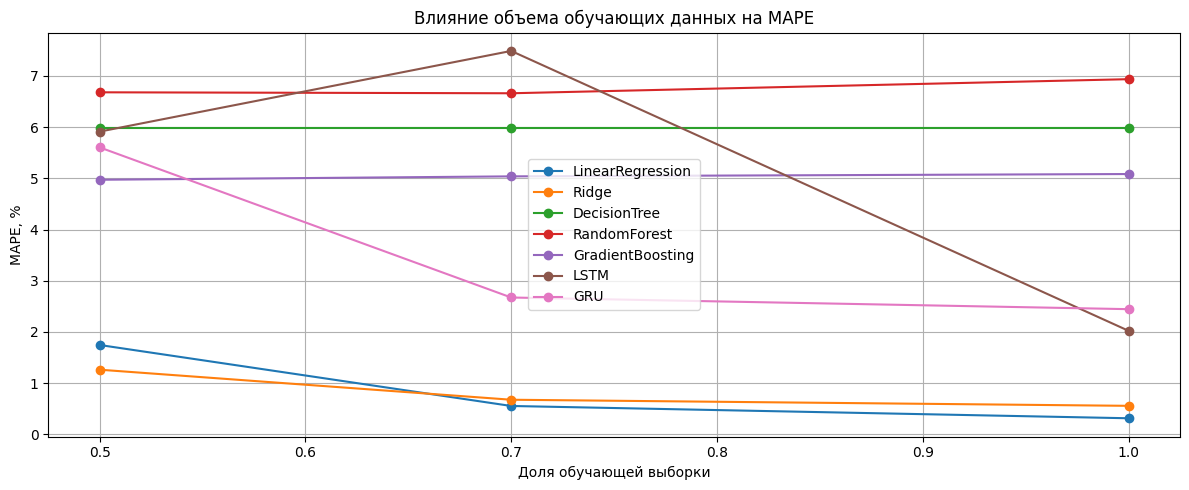

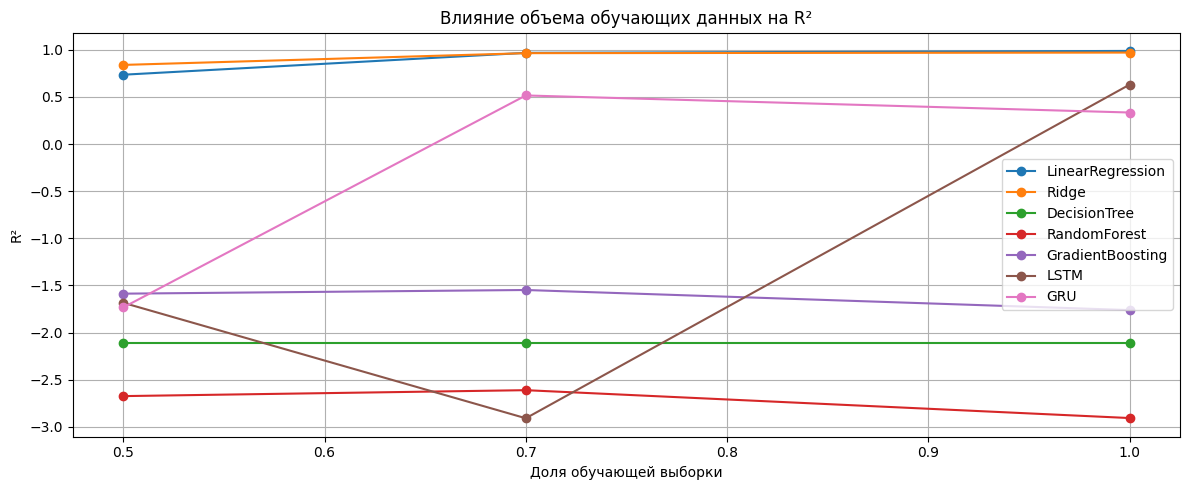

In [105]:
# График эксперимента с объемом данных

plt.figure(figsize=(12, 5))

for model_name in volume_results["model"].unique():
    temp = volume_results[volume_results["model"] == model_name]
    plt.plot(
        temp["train_size_share"],
        temp["MAPE_%"],
        marker="o",
        label=model_name
    )

plt.title("Влияние объема обучающих данных на MAPE")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("MAPE, %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

for model_name in volume_results["model"].unique():
    temp = volume_results[volume_results["model"] == model_name]
    plt.plot(
        temp["train_size_share"],
        temp["R2"],
        marker="o",
        label=model_name
    )

plt.title("Влияние объема обучающих данных на R²")
plt.xlabel("Доля обучающей выборки")
plt.ylabel("R²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [106]:
# Эксперимент: влияние качества данных

noise_levels = [0.0, 0.05, 0.10, 0.20]

quality_results = []

for noise in noise_levels:
    noisy_full_df = model_data_ml.copy()

    for col in available_features:
        std = train_ml[col].std()

        if pd.notna(std) and std > 0:
            train_mask = noisy_full_df["date"] < test_start
            test_mask = noisy_full_df["date"] >= test_start

            noisy_full_df.loc[train_mask, col] = (
                noisy_full_df.loc[train_mask, col] +
                np.random.normal(0, std * noise, size=train_mask.sum())
            )

            noisy_full_df.loc[test_mask, col] = (
                noisy_full_df.loc[test_mask, col] +
                np.random.normal(0, std * noise, size=test_mask.sum())
            )

    noisy_train = noisy_full_df[noisy_full_df["date"] < test_start].copy()
    noisy_test = noisy_full_df[noisy_full_df["date"] >= test_start].copy()

    X_train_noisy = noisy_train[available_features]
    y_train_noisy = noisy_train[target_col]

    X_test_noisy = noisy_test[available_features]
    y_test_noisy = noisy_test["food_cpi"]

    for model_name, model in classical_models.items():
        model.fit(X_train_noisy, y_train_noisy)

        pred_log = model.predict(X_test_noisy)
        pred = np.exp(pred_log)

        row = calc_ml_metrics(y_test_noisy, pred, model_name)
        row["noise_level"] = noise

        quality_results.append(row)

    for recurrent_model_type in ["LSTM", "GRU"]:
        _, _, recurrent_metrics, _ = fit_recurrent_model(
            full_df=noisy_full_df,
            features=available_features,
            target_col=target_col,
            test_start=test_start,
            model_type=recurrent_model_type,
            sequence_length=SEQUENCE_LENGTH,
            epochs=200,
            batch_size=8,
            verbose=0
        )

        recurrent_metrics["noise_level"] = noise

        quality_results.append(recurrent_metrics)

quality_results = pd.DataFrame(quality_results)

display(quality_results.sort_values(["noise_level", "MAPE_%"]))

,model,MAE,RMSE,MAPE_%,R2,noise_level
0,LinearRegression,0.580698,0.808949,0.313722,0.988988,0.00
1,Ridge,1.007555,1.300908,0.556560,0.971522,0.00
6,GRU,5.536567,7.006660,3.022699,0.173888,0.00
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065,0.00
5,LSTM,9.876381,12.021190,5.279627,-1.431710,0.00
2,DecisionTree,11.202595,13.598714,5.980595,-2.111807,0.00
3,RandomForest,12.954506,15.239533,6.936427,-2.908051,0.00
8,Ridge,1.237486,1.522080,0.680117,0.961016,0.05
7,LinearRegression,1.316720,1.714188,0.717510,0.950554,0.05
13,GRU,5.790069,6.659197,3.110052,0.253791,0.05


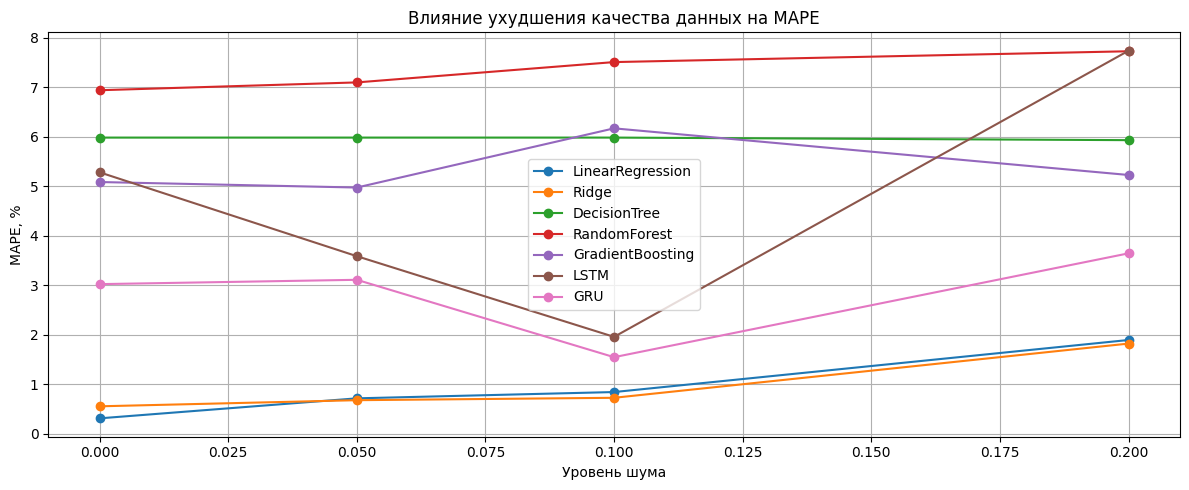

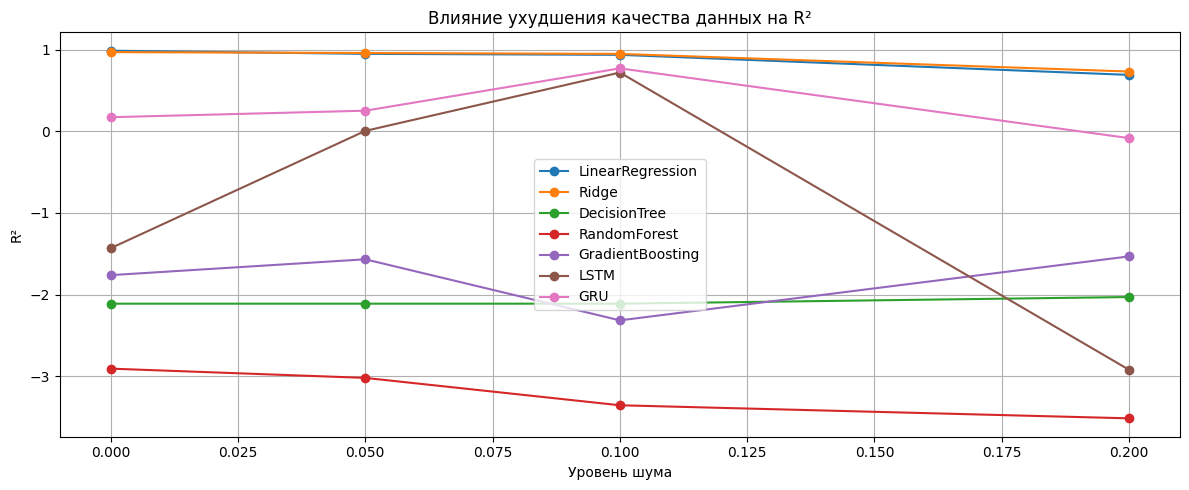

In [107]:
#  График эксперимента с качеством данных
plt.figure(figsize=(12, 5))

for model_name in quality_results["model"].unique():
    temp = quality_results[quality_results["model"] == model_name]
    plt.plot(
        temp["noise_level"],
        temp["MAPE_%"],
        marker="o",
        label=model_name
    )

plt.title("Влияние ухудшения качества данных на MAPE")
plt.xlabel("Уровень шума")
plt.ylabel("MAPE, %")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

for model_name in quality_results["model"].unique():
    temp = quality_results[quality_results["model"] == model_name]
    plt.plot(
        temp["noise_level"],
        temp["R2"],
        marker="o",
        label=model_name
    )

plt.title("Влияние ухудшения качества данных на R²")
plt.xlabel("Уровень шума")
plt.ylabel("R²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
#  Итоговые выводы по моделям

best_by_mape = metrics_ml.sort_values("MAPE_%").iloc[0]
best_by_r2 = metrics_ml.sort_values("R2", ascending=False).iloc[0]

print("Лучшая модель по MAPE:")
display(best_by_mape)

print("Лучшая модель по R²:")
display(best_by_r2)

print("Сравнение всех моделей:")
display(metrics_ml.sort_values("MAPE_%"))

print("Эксперимент с объемом данных:")
display(volume_results.sort_values(["train_size_share", "MAPE_%"]))

print("Эксперимент с качеством данных:")
display(quality_results.sort_values(["noise_level", "MAPE_%"]))

Лучшая модель по MAPE:


,0
model,LinearRegression
MAE,0.580698
RMSE,0.808949
MAPE_%,0.313722
R2,0.988988


Лучшая модель по R²:


,0
model,LinearRegression
MAE,0.580698
RMSE,0.808949
MAPE_%,0.313722
R2,0.988988


Сравнение всех моделей:


,model,MAE,RMSE,MAPE_%,R2
0,LinearRegression,0.580698,0.808949,0.313722,0.988988
1,Ridge,1.007555,1.300908,0.556560,0.971522
2,LSTM,4.444943,5.269781,2.388295,0.532693
3,GRU,9.117512,9.908297,4.932079,-0.652018
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065
5,DecisionTree,11.202595,13.598714,5.980595,-2.111807
6,RandomForest,12.954506,15.239533,6.936427,-2.908051


Эксперимент с объемом данных:


,model,MAE,RMSE,MAPE_%,R2,train_size_share,train_observations
1,Ridge,2.376383,3.077953,1.262343,0.840581,0.5,31
0,LinearRegression,3.158672,3.957153,1.744774,0.736499,0.5,31
4,GradientBoosting,9.382457,12.400585,4.971949,-1.587625,0.5,31
6,GRU,10.494979,12.746201,5.604627,-1.733873,0.5,31
5,LSTM,11.013213,12.630322,5.912194,-1.684391,0.5,31
2,DecisionTree,11.202595,13.598714,5.980595,-2.111807,0.5,31
3,RandomForest,12.483555,14.778383,6.680164,-2.675113,0.5,31
7,LinearRegression,1.025919,1.364847,0.553699,0.968654,0.7,44
8,Ridge,1.226558,1.436079,0.675570,0.965296,0.7,44
13,GRU,4.896846,5.360747,2.672390,0.516421,0.7,44


Эксперимент с качеством данных:


,model,MAE,RMSE,MAPE_%,R2,noise_level
0,LinearRegression,0.580698,0.808949,0.313722,0.988988,0.00
1,Ridge,1.007555,1.300908,0.556560,0.971522,0.00
6,GRU,5.536567,7.006660,3.022699,0.173888,0.00
4,GradientBoosting,9.599804,12.811752,5.083741,-1.762065,0.00
5,LSTM,9.876381,12.021190,5.279627,-1.431710,0.00
2,DecisionTree,11.202595,13.598714,5.980595,-2.111807,0.00
3,RandomForest,12.954506,15.239533,6.936427,-2.908051,0.00
8,Ridge,1.237486,1.522080,0.680117,0.961016,0.05
7,LinearRegression,1.316720,1.714188,0.717510,0.950554,0.05
13,GRU,5.790069,6.659197,3.110052,0.253791,0.05


In [109]:
pricing_df = model_data_ml.copy()
print("Используется model_data_ml из раздела 4")


pricing_df["month"] = pricing_df["date"].dt.month
pricing_df["year"] = pricing_df["date"].dt.year

display(pricing_df.head())
display(pricing_df.tail())

Используется model_data_ml из раздела 4


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,month,year
0,2019-01-01,115.4584,4.748910,12,4.734711,4.714615,4.702884,4.703017,4.689174,False,False,False,False,False,False,False,False,False,False,False,0.84,0.50,0.35,7.75,7.50,7.50,67.4059,66.2722,65.8870,80.067765,93.762530,81.704646,0,0,0,1,2019
1,2019-02-01,116.5437,4.758266,13,4.748910,4.734711,4.714615,4.697903,4.693166,True,False,False,False,False,False,False,False,False,False,False,1.01,0.84,0.50,7.75,7.75,7.50,67.2146,67.4059,66.2722,81.690165,80.067765,93.762530,0,0,0,2,2019
2,2019-03-01,117.2430,4.764249,14,4.758266,4.748910,4.734711,4.696703,4.699347,False,True,False,False,False,False,False,False,False,False,False,0.44,1.01,0.84,7.75,7.75,7.75,65.8795,67.2146,67.4059,85.208330,81.690165,80.067765,0,0,0,3,2019
3,2019-04-01,117.8057,4.769037,15,4.764249,4.758266,4.748910,4.702884,4.704235,False,False,True,False,False,False,False,False,False,False,False,0.32,0.44,1.01,7.75,7.75,7.75,65.1104,65.8795,67.2146,71.700618,85.208330,81.690165,0,0,0,4,2019
4,2019-05-01,118.3594,4.773726,16,4.769037,4.764249,4.758266,4.714615,4.703034,False,False,False,True,False,False,False,False,False,False,False,0.29,0.32,0.44,7.75,7.75,7.75,64.6159,65.1104,65.8795,76.895628,71.700618,85.208330,0,0,0,5,2019


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,month,year
70,2024-11-01,183.864807,5.214201,82,5.187614,5.174401,5.171948,5.164552,5.117140,False,False,False,False,False,False,False,False,False,True,False,0.75,0.48,0.20,21.0,19.0,18.0,96.2429,91.3736,89.1666,165.926128,171.101934,177.422943,0,1,0,11,2024
71,2024-12-01,189.307156,5.243371,83,5.214201,5.187614,5.174401,5.170544,5.134046,False,False,False,False,False,False,False,False,False,False,True,1.43,0.75,0.48,21.0,21.0,19.0,100.7252,96.2429,91.3736,153.904047,165.926128,171.101934,0,1,0,12,2024
72,2025-01-01,191.657261,5.255709,84,5.243371,5.214201,5.187614,5.173000,5.148159,False,False,False,False,False,False,False,False,False,False,False,1.32,1.43,0.75,21.0,21.0,21.0,102.2782,100.7252,96.2429,183.700777,153.904047,165.926128,0,1,0,1,2025
73,2025-02-01,193.883676,5.267258,85,5.255709,5.243371,5.214201,5.171948,5.155676,True,False,False,False,False,False,False,False,False,False,False,1.23,1.32,1.43,21.0,21.0,21.0,100.7428,102.2782,100.7252,149.831407,183.700777,153.904047,0,1,0,2,2025
74,2025-03-01,195.306109,5.274568,86,5.267258,5.255709,5.243371,5.174401,5.156389,False,True,False,False,False,False,False,False,False,False,False,0.81,1.23,1.32,21.0,21.0,21.0,92.6708,100.7428,102.2782,135.095197,149.831407,183.700777,0,1,0,3,2025


In [110]:
# Симуляция стратегий ценообразования

strategy_df = pricing_df.copy()

strategy_df["base_price_index"] = strategy_df["food_cpi"]

# 1. Стабильное ценообразование
strategy_df["price_stable"] = strategy_df["base_price_index"]

# 2. Динамическое ценообразование:
# цена сильнее реагирует на инфляцию, курс и геополитический риск
strategy_df["price_dynamic"] = strategy_df["base_price_index"].copy()

if "inflation_mom_pct" in strategy_df.columns:
    strategy_df["price_dynamic"] *= 1 + strategy_df["inflation_mom_pct"].fillna(0) / 100 * 0.3

if "usd_rub" in strategy_df.columns:
    usd_growth = strategy_df["usd_rub"].pct_change().fillna(0)
    strategy_df["price_dynamic"] *= 1 + usd_growth * 0.4

if "gpr_index" in strategy_df.columns:
    gpr_norm = (
        strategy_df["gpr_index"] - strategy_df["gpr_index"].mean()
    ) / strategy_df["gpr_index"].std()
    strategy_df["price_dynamic"] *= 1 + gpr_norm.fillna(0) * 0.01

# 3. Умеренные скидки и акции
strategy_df["promo_discount"] = 0

strategy_df.loc[
    strategy_df["month"].isin([2, 3, 11, 12]),
    "promo_discount"
] = 0.05

strategy_df["price_promo"] = strategy_df["base_price_index"] * (1 - strategy_df["promo_discount"])

# 4. Агрессивные промо
strategy_df["aggressive_discount"] = 0

strategy_df.loc[
    strategy_df["month"].isin([3, 11, 12]),
    "aggressive_discount"
] = 0.12

strategy_df.loc[
    strategy_df["month"].isin([1, 7]),
    "aggressive_discount"
] = 0.07

strategy_df["price_aggressive_promo"] = strategy_df["base_price_index"] * (
    1 - strategy_df["aggressive_discount"]
)

# 5. Смешанная стратегия
strategy_df["price_mixed"] = strategy_df["price_dynamic"] * (
    1 - strategy_df["promo_discount"]
)

strategy_df[[
    "date",
    "base_price_index",
    "price_stable",
    "price_dynamic",
    "price_promo",
    "price_aggressive_promo",
    "price_mixed"
]].head()

,date,base_price_index,price_stable,price_dynamic,price_promo,price_aggressive_promo,price_mixed
0,2019-01-01,115.4584,115.4584,115.4584,115.458400,107.376312,115.458400
1,2019-02-01,116.5437,116.5437,116.5437,110.716515,116.543700,110.716515
2,2019-03-01,117.2430,117.2430,117.2430,111.380850,103.173840,111.380850
3,2019-04-01,117.8057,117.8057,117.8057,117.805700,117.805700,117.805700
4,2019-05-01,118.3594,118.3594,118.3594,118.359400,118.359400,118.359400


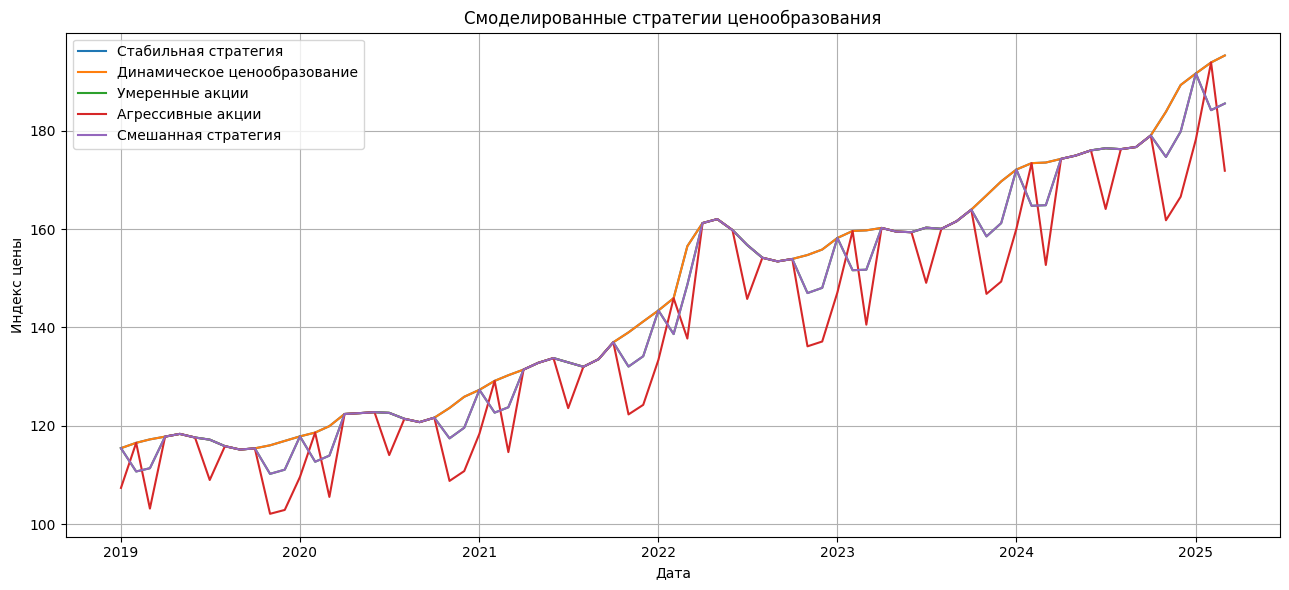

In [111]:
# График стратегий ценообразования

plt.figure(figsize=(13, 6))

plt.plot(strategy_df["date"], strategy_df["price_stable"], label="Стабильная стратегия")
plt.plot(strategy_df["date"], strategy_df["price_dynamic"], label="Динамическое ценообразование")
plt.plot(strategy_df["date"], strategy_df["price_promo"], label="Умеренные акции")
plt.plot(strategy_df["date"], strategy_df["price_aggressive_promo"], label="Агрессивные акции")
plt.plot(strategy_df["date"], strategy_df["price_mixed"], label="Смешанная стратегия")

plt.title("Смоделированные стратегии ценообразования")
plt.xlabel("Дата")
plt.ylabel("Индекс цены")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [112]:
# Симуляция спроса

def simulate_demand(price_series, elasticity=-1.2, base_demand=1000, noise_std=30):
    normalized_price = price_series / price_series.iloc[0]

    demand = base_demand * (normalized_price ** elasticity)

    noise = np.random.normal(0, noise_std, size=len(price_series))

    demand = demand + noise

    demand = np.maximum(demand, 1)

    return demand


strategy_df["demand_stable"] = simulate_demand(strategy_df["price_stable"])
strategy_df["demand_dynamic"] = simulate_demand(strategy_df["price_dynamic"])
strategy_df["demand_promo"] = simulate_demand(strategy_df["price_promo"])
strategy_df["demand_aggressive_promo"] = simulate_demand(strategy_df["price_aggressive_promo"])
strategy_df["demand_mixed"] = simulate_demand(strategy_df["price_mixed"])

# Дополнительный эффект акций: временный рост спроса
strategy_df["demand_promo"] *= 1 + strategy_df["promo_discount"] * 2.5
strategy_df["demand_aggressive_promo"] *= 1 + strategy_df["aggressive_discount"] * 3.0
strategy_df["demand_mixed"] *= 1 + strategy_df["promo_discount"] * 2.0

display(strategy_df[[
    "date",
    "price_stable",
    "demand_stable",
    "price_dynamic",
    "demand_dynamic",
    "price_promo",
    "demand_promo",
    "price_aggressive_promo",
    "demand_aggressive_promo",
    "price_mixed",
    "demand_mixed"
]].head())

,date,price_stable,demand_stable,price_dynamic,demand_dynamic,price_promo,demand_promo,price_aggressive_promo,demand_aggressive_promo,price_mixed,demand_mixed
0,2019-01-01,115.4584,934.074970,115.4584,1044.539256,115.458400,985.461143,107.376312,1154.311274,115.458400,1028.039641
1,2019-02-01,116.5437,1026.896985,116.5437,958.044960,110.716515,1187.904444,116.543700,855.724996,110.716515,1168.981331
2,2019-03-01,117.2430,987.468960,117.2430,1029.445502,111.380850,1138.298241,103.173840,1402.231907,111.380850,1111.627399
3,2019-04-01,117.8057,964.748944,117.8057,984.655010,117.805700,986.235170,117.805700,910.402771,117.805700,974.892946
4,2019-05-01,118.3594,996.375205,118.3594,970.448566,118.359400,956.929916,118.359400,870.112605,118.359400,999.775107


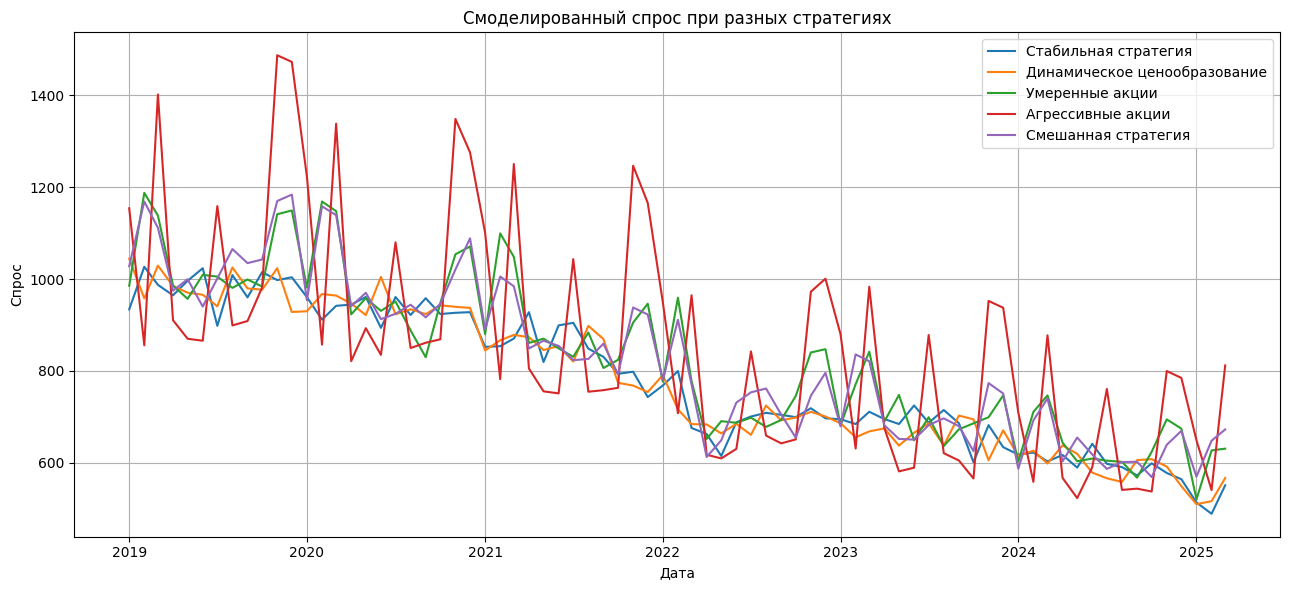

In [113]:
# График смоделированного спроса

plt.figure(figsize=(13, 6))

plt.plot(strategy_df["date"], strategy_df["demand_stable"], label="Стабильная стратегия")
plt.plot(strategy_df["date"], strategy_df["demand_dynamic"], label="Динамическое ценообразование")
plt.plot(strategy_df["date"], strategy_df["demand_promo"], label="Умеренные акции")
plt.plot(strategy_df["date"], strategy_df["demand_aggressive_promo"], label="Агрессивные акции")
plt.plot(strategy_df["date"], strategy_df["demand_mixed"], label="Смешанная стратегия")

plt.title("Смоделированный спрос при разных стратегиях")
plt.xlabel("Дата")
plt.ylabel("Спрос")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [114]:
# Подготовка признаков

strategy_df["trend"] = np.arange(len(strategy_df))

strategy_df["is_promo"] = (strategy_df["promo_discount"] > 0).astype(int)
strategy_df["is_aggressive_promo"] = (strategy_df["aggressive_discount"] > 0).astype(int)

strategy_df["discount_size"] = strategy_df[[
    "promo_discount",
    "aggressive_discount"
]].max(axis=1)

strategy_df["dynamic_pricing_intensity"] = (
    strategy_df["price_dynamic"] / strategy_df["price_stable"] - 1
)

strategy_df["mixed_strategy_intensity"] = (
    strategy_df["price_mixed"] / strategy_df["price_stable"] - 1
)

for lag in [1, 2, 3, 6]:
    strategy_df[f"log_food_cpi_lag{lag}"] = strategy_df["log_food_cpi"].shift(lag)
    strategy_df[f"discount_size_lag{lag}"] = strategy_df["discount_size"].shift(lag)
    strategy_df[f"is_promo_lag{lag}"] = strategy_df["is_promo"].shift(lag)
    strategy_df[f"dynamic_pricing_intensity_lag{lag}"] = strategy_df["dynamic_pricing_intensity"].shift(lag)

strategy_df = pd.get_dummies(
    strategy_df,
    columns=["month"],
    prefix="month",
    drop_first=True
)

display(strategy_df.head())

,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,log_food_cpi_lag12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,inflation_mom_pct_lag1,inflation_mom_pct_lag2,inflation_mom_pct_lag3,key_rate_lag1,key_rate_lag2,key_rate_lag3,usd_rub_lag1,usd_rub_lag2,usd_rub_lag3,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,event_covid,event_2022_sanctions,event_high_gpr,year,base_price_index,price_stable,price_dynamic,promo_discount,price_promo,aggressive_discount,price_aggressive_promo,price_mixed,demand_stable,demand_dynamic,demand_promo,demand_aggressive_promo,demand_mixed,is_promo,is_aggressive_promo,discount_size,dynamic_pricing_intensity,mixed_strategy_intensity,discount_size_lag1,is_promo_lag1,dynamic_pricing_intensity_lag1,discount_size_lag2,is_promo_lag2,dynamic_pricing_intensity_lag2,discount_size_lag3,is_promo_lag3,dynamic_pricing_intensity_lag3,discount_size_lag6,is_promo_lag6,dynamic_pricing_intensity_lag6,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2019-01-01,115.4584,4.748910,0,NaN,NaN,NaN,NaN,4.689174,False,False,False,False,False,False,False,False,False,False,False,0.84,0.50,0.35,7.75,7.50,7.50,67.4059,66.2722,65.8870,80.067765,93.762530,81.704646,0,0,0,2019,115.4584,115.4584,115.4584,0.00,115.458400,0.07,107.376312,115.458400,934.074970,1044.539256,985.461143,1154.311274,1028.039641,0,1,0.07,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False
1,2019-02-01,116.5437,4.758266,1,4.748910,NaN,NaN,NaN,4.693166,True,False,False,False,False,False,False,False,False,False,False,1.01,0.84,0.50,7.75,7.75,7.50,67.2146,67.4059,66.2722,81.690165,80.067765,93.762530,0,0,0,2019,116.5437,116.5437,116.5437,0.05,110.716515,0.00,116.543700,110.716515,1026.896985,958.044960,1187.904444,855.724996,1168.981331,1,0,0.05,0.0,-0.05,0.07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False,False,False,False,False,False,False,False
2,2019-03-01,117.2430,4.764249,2,4.758266,4.748910,NaN,NaN,4.699347,False,True,False,False,False,False,False,False,False,False,False,0.44,1.01,0.84,7.75,7.75,7.75,65.8795,67.2146,67.4059,85.208330,81.690165,80.067765,0,0,0,2019,117.2430,117.2430,117.2430,0.05,111.380850,0.12,103.173840,111.380850,987.468960,1029.445502,1138.298241,1402.231907,1111.627399,1,1,0.12,0.0,-0.05,0.05,1.0,0.0,0.07,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False,False,False,False
3,2019-04-01,117.8057,4.769037,3,4.764249,4.758266,4.748910,NaN,4.704235,False,False,True,False,False,False,False,False,False,False,False,0.32,0.44,1.01,7.75,7.75,7.75,65.1104,65.8795,67.2146,71.700618,85.208330,81.690165,0,0,0,2019,117.8057,117.8057,117.8057,0.00,117.805700,0.00,117.805700,117.805700,964.748944,984.655010,986.235170,910.402771,974.892946,0,0,0.00,0.0,0.00,0.12,1.0,0.0,0.05,1.0,0.0,0.07,0.0,0.0,NaN,NaN,NaN,False,False,True,False,False,False,False,False,False,False,False
4,2019-05-01,118.3594,4.773726,4,4.769037,4.764249,4.758266,NaN,4.703034,False,False,False,True,False,False,False,False,False,False,False,0.29,0.32,0.44,7.75,7.75,7.75,64.6159,65.1104,65.8795,76.895628,71.700618,85.208330,0,0,0,2019,118.3594,118.3594,118.3594,0.00,118.359400,0.00,118.359400,118.359400,996.375205,970.448566,956.929916,870.112605,999.775107,0,0,0.00,0.0,0.00,0.00,0.0,0.0,0.12,1.0,0.0,0.05,1.0,0.0,NaN,NaN,NaN,False,False,False,True,False,False,False,False,False,False,False


In [115]:
#  Наборы признаков

target_col = "log_food_cpi"

# Удаляем дублирующиеся столбцы, если они появились после повторного запуска ячеек
strategy_df = strategy_df.loc[:, ~strategy_df.columns.duplicated()].copy()

base_features_s5 = [
    "trend",
    "log_food_cpi_lag1",
    "log_food_cpi_lag2",
    "log_food_cpi_lag3",
    "log_food_cpi_lag6",
]

seasonal_features_s5 = [
    col for col in strategy_df.columns
    if str(col).startswith("month_")
]

strategy_extra_features_s5 = [
    "is_promo",
    "is_aggressive_promo",
    "discount_size",
    "dynamic_pricing_intensity",
    "mixed_strategy_intensity",
    "discount_size_lag1",
    "discount_size_lag2",
    "discount_size_lag3",
    "is_promo_lag1",
    "is_promo_lag2",
    "is_promo_lag3",
    "dynamic_pricing_intensity_lag1",
    "dynamic_pricing_intensity_lag2",
    "dynamic_pricing_intensity_lag3",
]

# Оставляем только реально существующие признаки
base_features_s5 = [
    col for col in base_features_s5 + seasonal_features_s5
    if col in strategy_df.columns
]

strategy_features_s5 = [
    col for col in base_features_s5 + strategy_extra_features_s5
    if col in strategy_df.columns
]

# Удаляем повторы внутри списков признаков
base_features_s5 = list(dict.fromkeys(base_features_s5))
strategy_features_s5 = list(dict.fromkeys(strategy_features_s5))

selected_cols_s5 = ["date", "food_cpi", target_col] + strategy_features_s5
selected_cols_s5 = list(dict.fromkeys(selected_cols_s5))

model_data_s5 = strategy_df[selected_cols_s5].copy()

for col in strategy_features_s5:
    model_data_s5[col] = pd.to_numeric(model_data_s5[col], errors="coerce")

model_data_s5[target_col] = pd.to_numeric(model_data_s5[target_col], errors="coerce")
model_data_s5["food_cpi"] = pd.to_numeric(model_data_s5["food_cpi"], errors="coerce")

model_data_s5 = model_data_s5.dropna().reset_index(drop=True)

print("Размер данных:", model_data_s5.shape)
print("Количество базовых признаков:", len(base_features_s5))
print("Количество признаков со стратегиями:", len(strategy_features_s5))

display(model_data_s5.head())

Размер данных: (69, 33)
Количество базовых признаков: 16
Количество признаков со стратегиями: 30


,date,food_cpi,log_food_cpi,trend,log_food_cpi_lag1,log_food_cpi_lag2,log_food_cpi_lag3,log_food_cpi_lag6,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,is_promo,is_aggressive_promo,discount_size,dynamic_pricing_intensity,mixed_strategy_intensity,discount_size_lag1,discount_size_lag2,discount_size_lag3,is_promo_lag1,is_promo_lag2,is_promo_lag3,dynamic_pricing_intensity_lag1,dynamic_pricing_intensity_lag2,dynamic_pricing_intensity_lag3
0,2019-07-01,117.1904,4.763800,6,4.767507,4.773726,4.769037,4.748910,False,False,False,False,False,True,False,False,False,False,False,0,1,0.07,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-08-01,115.8661,4.752435,7,4.763800,4.767507,4.773726,4.758266,False,False,False,False,False,False,True,False,False,False,False,0,0,0.00,0.0,0.00,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-09-01,115.1709,4.746417,8,4.752435,4.763800,4.767507,4.764249,False,False,False,False,False,False,False,True,False,False,False,0,0,0.00,0.0,0.00,0.00,0.07,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-10-01,115.4243,4.748615,9,4.746417,4.752435,4.763800,4.769037,False,False,False,False,False,False,False,False,True,False,False,0,0,0.00,0.0,0.00,0.00,0.00,0.07,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-11-01,116.0360,4.753900,10,4.748615,4.746417,4.752435,4.773726,False,False,False,False,False,False,False,False,False,True,False,1,1,0.12,0.0,-0.05,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0


In [116]:
# Train-test split

TEST_MONTHS = 12

test_start_s5 = model_data_s5["date"].max() - pd.DateOffset(months=TEST_MONTHS - 1)

train_s5 = model_data_s5[model_data_s5["date"] < test_start_s5].copy()
test_s5 = model_data_s5[model_data_s5["date"] >= test_start_s5].copy()

print("Train:", train_s5["date"].min().date(), "-", train_s5["date"].max().date())
print("Test:", test_s5["date"].min().date(), "-", test_s5["date"].max().date())

X_train_base = train_s5[base_features_s5]
X_test_base = test_s5[base_features_s5]

X_train_strategy = train_s5[strategy_features_s5]
X_test_strategy = test_s5[strategy_features_s5]

y_train_s5 = train_s5[target_col]
y_test_s5 = test_s5["food_cpi"]

Train: 2019-07-01 - 2024-03-01
Test: 2024-04-01 - 2025-03-01


In [117]:
#  Функции обучения и оценки

def calc_metrics_s5(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }


def fit_price_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)
    pred = np.exp(pred_log)

    metrics = calc_metrics_s5(y_test, pred, model_name)

    forecast = pd.DataFrame({
        "date": test_s5["date"].values,
        "actual_food_cpi": y_test.values,
        f"forecast_{model_name}": pred,
    })

    return model, forecast, metrics

In [118]:
#  Обучение моделей
models_s5 = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=3,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ),
}

metrics_s5 = []
forecasts_s5 = []

for name, model in models_s5.items():
    _, forecast_base, metric_base = fit_price_model(
        model=model,
        X_train=X_train_base,
        y_train=y_train_s5,
        X_test=X_test_base,
        y_test=y_test_s5,
        model_name=f"{name}_without_strategy"
    )

    metrics_s5.append(metric_base)
    forecasts_s5.append(forecast_base)

    _, forecast_strategy, metric_strategy = fit_price_model(
        model=model,
        X_train=X_train_strategy,
        y_train=y_train_s5,
        X_test=X_test_strategy,
        y_test=y_test_s5,
        model_name=f"{name}_with_strategy"
    )

    metrics_s5.append(metric_strategy)
    forecasts_s5.append(forecast_strategy)

metrics_s5 = pd.DataFrame(metrics_s5).sort_values("MAPE_%").reset_index(drop=True)

display(metrics_s5)

,model,MAE,RMSE,MAPE_%,R2
0,Ridge_with_strategy,1.462392,1.947621,0.799943,0.936170
1,Ridge_without_strategy,1.468272,1.949485,0.802735,0.936048
2,GradientBoosting_without_strategy,9.048968,11.836458,4.799063,-1.357547
3,GradientBoosting_with_strategy,9.647974,12.196778,5.132104,-1.503267
4,RandomForest_without_strategy,12.271289,14.491771,6.567822,-2.533945
5,RandomForest_with_strategy,12.363159,14.555825,6.618895,-2.565255


In [119]:
#Оценка вклада стратегий в точность прогноза

def improvement_pct(base_error, improved_error):
    return (base_error - improved_error) / base_error * 100


strategy_comparison = []

for model_name in ["Ridge", "RandomForest", "GradientBoosting"]:
    base_row = metrics_s5[metrics_s5["model"] == f"{model_name}_without_strategy"]
    strategy_row = metrics_s5[metrics_s5["model"] == f"{model_name}_with_strategy"]

    if len(base_row) > 0 and len(strategy_row) > 0:
        base_mape = base_row["MAPE_%"].values[0]
        strategy_mape = strategy_row["MAPE_%"].values[0]

        base_rmse = base_row["RMSE"].values[0]
        strategy_rmse = strategy_row["RMSE"].values[0]

        base_r2 = base_row["R2"].values[0]
        strategy_r2 = strategy_row["R2"].values[0]

        strategy_comparison.append({
            "model": model_name,
            "MAPE_without_strategy": base_mape,
            "MAPE_with_strategy": strategy_mape,
            "MAPE_improvement_%": improvement_pct(base_mape, strategy_mape),
            "RMSE_without_strategy": base_rmse,
            "RMSE_with_strategy": strategy_rmse,
            "RMSE_improvement_%": improvement_pct(base_rmse, strategy_rmse),
            "R2_without_strategy": base_r2,
            "R2_with_strategy": strategy_r2,
            "R2_change": strategy_r2 - base_r2,
        })

strategy_comparison = pd.DataFrame(strategy_comparison)

display(strategy_comparison)

,model,MAPE_without_strategy,MAPE_with_strategy,MAPE_improvement_%,RMSE_without_strategy,RMSE_with_strategy,RMSE_improvement_%,R2_without_strategy,R2_with_strategy,R2_change
0,Ridge,0.802735,0.799943,0.347780,1.949485,1.947621,0.095590,0.936048,0.936170,0.000122
1,RandomForest,6.567822,6.618895,-0.777615,14.491771,14.555825,-0.442002,-2.533945,-2.565255,-0.031309
2,GradientBoosting,4.799063,5.132104,-6.939705,11.836458,12.196778,-3.044147,-1.357547,-1.503267,-0.145719


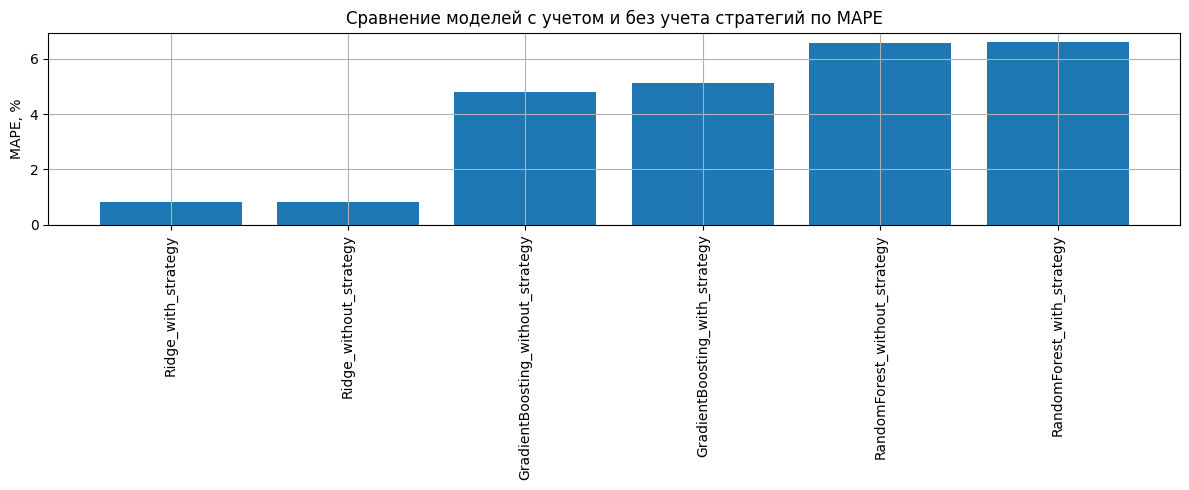

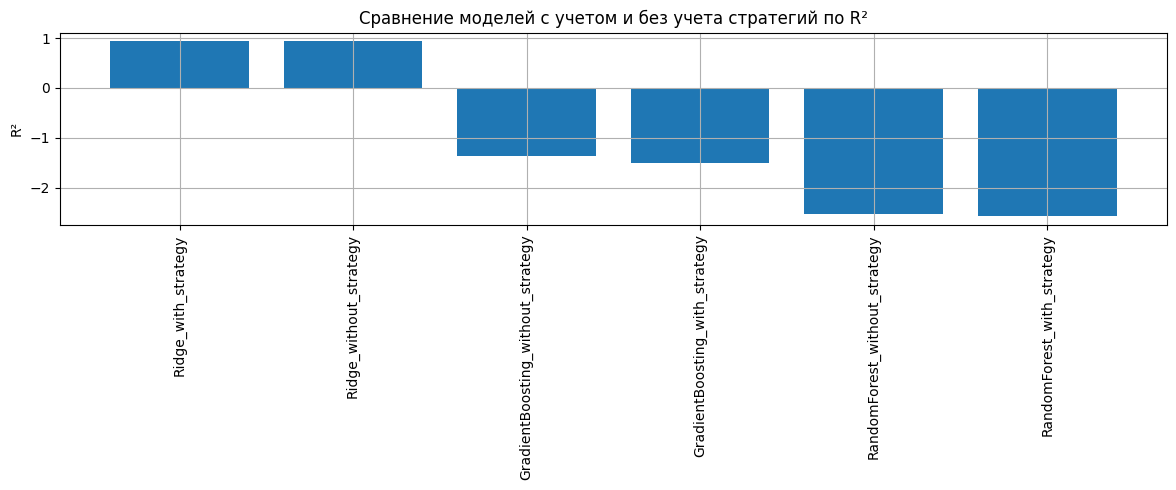

In [120]:
#  Графики MAPE и R2

plt.figure(figsize=(12, 5))
plt.bar(metrics_s5["model"], metrics_s5["MAPE_%"])
plt.title("Сравнение моделей с учетом и без учета стратегий по MAPE")
plt.ylabel("MAPE, %")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


metrics_s5_r2 = metrics_s5.sort_values("R2", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(metrics_s5_r2["model"], metrics_s5_r2["R2"])
plt.title("Сравнение моделей с учетом и без учета стратегий по R²")
plt.ylabel("R²")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

,date,actual_food_cpi,forecast_Ridge_without_strategy,forecast_Ridge_with_strategy,forecast_RandomForest_without_strategy,forecast_RandomForest_with_strategy,forecast_GradientBoosting_without_strategy,forecast_GradientBoosting_with_strategy
0,2024-04-01,174.278852,178.379302,178.383945,170.037089,169.988827,173.561559,173.192109
1,2024-05-01,174.959145,176.913308,176.899226,170.037089,169.892997,173.358109,173.013264
2,2024-06-01,176.010508,175.940702,175.898164,170.037089,169.892251,173.124916,172.451507
3,2024-07-01,176.443422,175.893834,175.834438,170.037089,169.921011,173.272521,172.140726
4,2024-08-01,176.257888,175.329423,175.265322,170.037089,169.927707,172.535562,171.829912
5,2024-09-01,176.690802,176.754648,176.696240,170.037089,169.938885,173.347601,172.736192
6,2024-10-01,179.040907,179.236789,179.186854,170.037089,169.896903,173.044551,172.048159
7,2024-11-01,183.864807,181.776339,181.745661,170.037089,169.949550,173.347601,172.180801
8,2024-12-01,189.307156,185.661123,185.644232,170.037089,169.999495,173.347601,172.467657
9,2025-01-01,191.657261,190.047816,190.231931,170.037089,169.967040,173.347601,173.006258


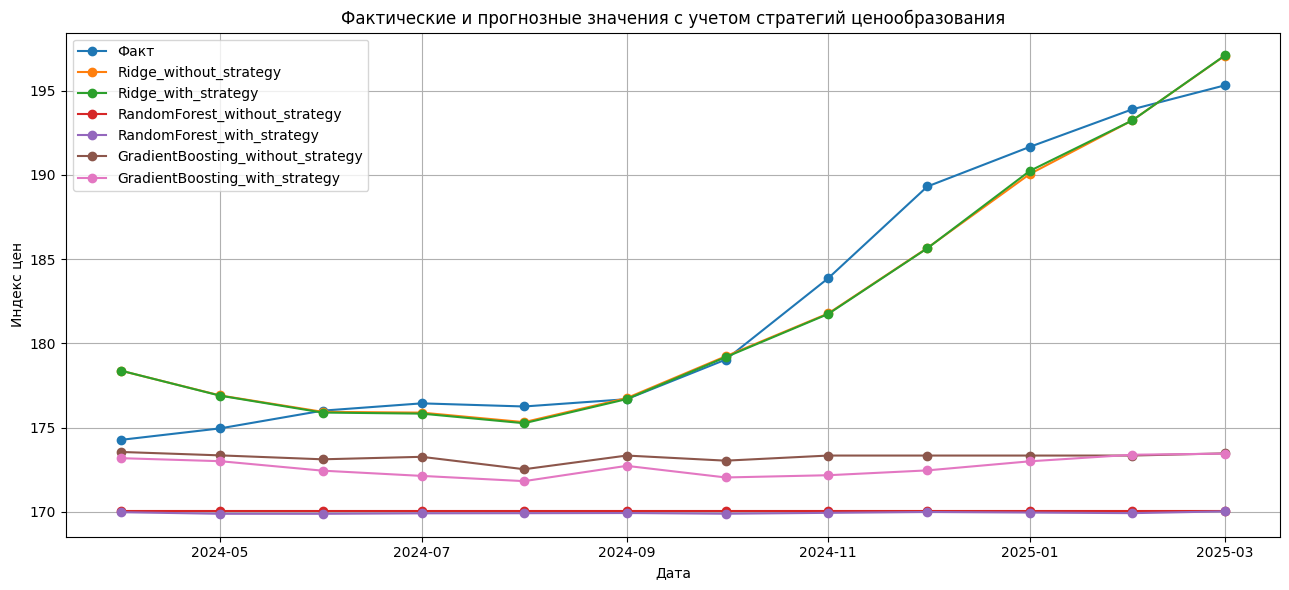

In [121]:
# Факт и прогнозы

forecast_s5 = test_s5[["date", "food_cpi"]].copy()
forecast_s5 = forecast_s5.rename(columns={"food_cpi": "actual_food_cpi"})

for forecast in forecasts_s5:
    forecast_s5 = forecast_s5.merge(
        forecast,
        on=["date", "actual_food_cpi"],
        how="left"
    )

display(forecast_s5)

plt.figure(figsize=(13, 6))

plt.plot(
    forecast_s5["date"],
    forecast_s5["actual_food_cpi"],
    marker="o",
    label="Факт"
)

for col in forecast_s5.columns:
    if col.startswith("forecast_"):
        plt.plot(
            forecast_s5["date"],
            forecast_s5[col],
            marker="o",
            label=col.replace("forecast_", "")
        )

plt.title("Фактические и прогнозные значения с учетом стратегий ценообразования")
plt.xlabel("Дата")
plt.ylabel("Индекс цен")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [122]:
#  Оценка сложности прогнозирования разных стратегий

strategy_complexity = []

strategy_pairs = {
    "stable": ("price_stable", "demand_stable"),
    "dynamic": ("price_dynamic", "demand_dynamic"),
    "promo": ("price_promo", "demand_promo"),
    "aggressive_promo": ("price_aggressive_promo", "demand_aggressive_promo"),
    "mixed": ("price_mixed", "demand_mixed"),
}

for strategy_name, (price_col, demand_col) in strategy_pairs.items():
    price_volatility = strategy_df[price_col].pct_change().std()
    demand_volatility = strategy_df[demand_col].pct_change().std()

    price_range = strategy_df[price_col].max() - strategy_df[price_col].min()
    demand_range = strategy_df[demand_col].max() - strategy_df[demand_col].min()

    strategy_complexity.append({
        "strategy": strategy_name,
        "price_volatility": price_volatility,
        "demand_volatility": demand_volatility,
        "price_range": price_range,
        "demand_range": demand_range,
        "forecast_complexity_score": (
            price_volatility * 0.4 +
            demand_volatility * 0.4 +
            price_range / strategy_df[price_col].mean() * 0.1 +
            demand_range / strategy_df[demand_col].mean() * 0.1
        )
    })

strategy_complexity = pd.DataFrame(strategy_complexity)
strategy_complexity = strategy_complexity.sort_values(
    "forecast_complexity_score",
    ascending=False
).reset_index(drop=True)

display(strategy_complexity)

,strategy,price_volatility,demand_volatility,price_range,demand_range,forecast_complexity_score
0,aggressive_promo,0.076514,0.300520,91.771996,964.546521,0.328852
1,promo,0.032807,0.112504,81.423061,667.747124,0.195325
2,mixed,0.032807,0.107936,81.423061,615.287448,0.187300
3,stable,0.012552,0.059846,80.135209,538.072297,0.152668
4,dynamic,0.012552,0.054300,80.135209,534.896540,0.150305


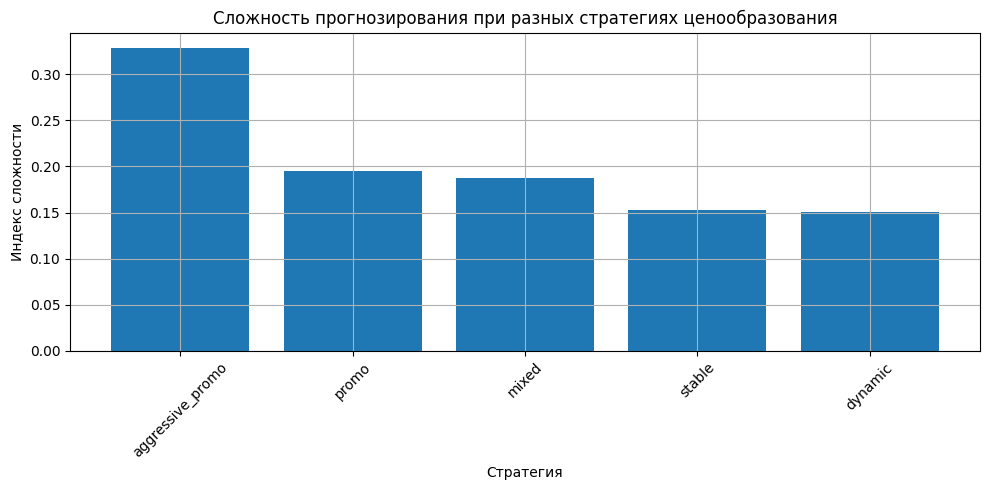

In [123]:
# График сложности стратегий

plt.figure(figsize=(10, 5))
plt.bar(
    strategy_complexity["strategy"],
    strategy_complexity["forecast_complexity_score"]
)

plt.title("Сложность прогнозирования при разных стратегиях ценообразования")
plt.xlabel("Стратегия")
plt.ylabel("Индекс сложности")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
# Компенсация сложности стратегий

compensation_result = strategy_comparison.copy()

compensation_result["interpretation"] = np.where(
    compensation_result["MAPE_improvement_%"] > 0,
    "Учет стратегии снижает ошибку прогноза",
    "Учет стратегии не снижает ошибку прогноза"
)

display(compensation_result)

,model,MAPE_without_strategy,MAPE_with_strategy,MAPE_improvement_%,RMSE_without_strategy,RMSE_with_strategy,RMSE_improvement_%,R2_without_strategy,R2_with_strategy,R2_change,interpretation
0,Ridge,0.802735,0.799943,0.347780,1.949485,1.947621,0.095590,0.936048,0.936170,0.000122,Учет стратегии снижает ошибку прогноза
1,RandomForest,6.567822,6.618895,-0.777615,14.491771,14.555825,-0.442002,-2.533945,-2.565255,-0.031309,Учет стратегии не снижает ошибку прогноза
2,GradientBoosting,4.799063,5.132104,-6.939705,11.836458,12.196778,-3.044147,-1.357547,-1.503267,-0.145719,Учет стратегии не снижает ошибку прогноза
